# Filtro de Particulas para DNS / DNSS con tau_t dinamico

**Proyecto KJM -- Extension metodologica: estimacion conjunta de beta_t y tau_t**

---

## Motivacion

En el Kalman Filter (notebook `DNS_DNSS_KalmanFilter_Adaptativo`), tau se trata como un
**hiperparametro fijo en el tiempo**: se estima via Grid Search adaptativo (rolling/expanding
window sobre SSE) y luego se usa como insumo *conocido* dentro de un sistema lineal-gaussiano
para estimar (mu,F,Q,R) por MLE. Mientras tau sea fijo, el sistema es condicionalmente
lineal en beta_t y el Kalman Filter es el estimador optimo.

El motivador de este notebook es distinto: queremos **modelar conjuntamente beta_t y
tau_t a lo largo del tiempo**, dejando que tau_t evolucione como parte del estado oculto
en lugar de fijarlo externamente. Esto es deliberadamente una formulacion **no lineal**, porque
tau_t entra en la matriz de cargas Lambda(tau_t) de forma no lineal (via exp(-m/tau_t)),
y un Extended Kalman Filter (linealizar Lambda(tau) via jacobianos en cada paso) es
incomodo y potencialmente inestable cuando tau_t se acerca a valores que casi colapsan la
pendiente o la curvatura. El **Filtro de Particulas (Particle Filter, PF)** evita esa
linealizacion por completo: solo necesita *evaluar* Lambda(tau) en cada particula, nunca
diferenciarla.

### Que problema resuelve esto (y que problema NO resuelve)

| Hallazgo de fases anteriores | Lo aborda el PF? |
|---|---|
| Colas pesadas en QQ-plots (Jarque-Bera) | **Si** -- la ecuacion de medicion admite innovaciones Student-t sin perder la optimalidad del filtro (ver seccion de innovaciones) |
| Heterocedasticidad estructural (COVID, gobierno Petro) | **Parcialmente** -- un tau_t dinamico no reemplaza la necesidad de una R piecewise-constant, pero es complementario |
| Label-switching tau1/tau2 en DNSS | **Si, de forma mas directa** -- la restriccion direccional se aplica particula-por-particula en cada periodo, no solo al final |
| tau no identificado / colinealidad en H a corto plazo | No -- sigue siendo un problema de la matriz de cargas, independiente del filtro |
| Disciplina de evaluacion OOS (un paso adelante, no suavizado) | El PF produce naturalmente beta_(t\|t-1) (predictivo) y beta_(t\|t) (filtrado); se preserva la misma disciplina |

### Estructura del notebook

Esta es la **misma estructura conceptual** que `DNS_DNSS_KalmanFilter_Adaptativo`: carga de
datos -> formulacion matematica -> nucleo del algoritmo -> estimacion de hiperparametros ->
ejecucion -> diagnosticos -> visualizacion -> funcion principal de uso. La diferencia es que aqui
el filtro reemplaza al Kalman Filter exacto por una aproximacion Monte Carlo secuencial, y se
agrega una etapa de calibracion de la dinamica de tau_t que no existia antes (porque antes
tau no tenia dinamica -- era una grilla estatica).

**Diseno clave:** el diccionario de salida del PF usa el **mismo esquema de claves** que
`fit_model_kf()` (`residuals`, `dates`, `maturities`, `model`, `fitted`, `tau1_t`, ...). Esto
permite reutilizar sin modificacion las funciones de diagnostico de residuos
(`analisis_residuos`, `plot_heatmap_residuos`, `plot_curvas_ajustadas`) ya validadas en el
notebook del Kalman Filter.

**Referencias:**
Gordon, Salmond & Smith (1993) -- bootstrap PF original. Kim, Shephard & Chib (1998) -- PF para
volatilidad estocastica. Pitt & Shephard (1999) -- auxiliary particle filter. Doucet, de
Freitas & Gordon (2001) -- tutorial de SMC. Andrieu, Doucet & Holenstein (2010) -- Particle
MCMC (extension futura para aprendizaje conjunto de hiperparametros). Diebold & Li (2006).
Diebold & Rudebusch (2013).

## 1. Imports y configuracion global

Se reutilizan las mismas librerias que el notebook del Kalman Filter (NumPy, pandas,
Matplotlib, SciPy, Numba). El nucleo del Particle Filter en si **no usa Numba**: con
N=2000-5000 particulas y aritmetica vectorizada de NumPy (broadcasting sobre el eje de
particulas, sin loops explicitos sobre i), el costo por paso de tiempo es de microsegundos
-- suficientemente rapido para series diarias de una decada sin necesitar compilacion JIT. Esto
es una decision deliberada de mantener el codigo transparente y facil de depurar; Numba queda
como optimizacion opcional si se escala a N mucho mayor.

Numba si se reutiliza para el nucleo del Kalman Filter (`_kf_core`), porque ese codigo se trae
sin modificacion del notebook anterior para construir el *warm-start*.

In [22]:
import numpy as np
import pandas as pd
import os, sys, time, warnings
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    from numba import njit as _njit
    _NUMBA = True
except ImportError:
    _NUMBA = False
    def _njit(**kw):
        return lambda f: f

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.22, 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.framealpha': 0.85, 'legend.fontsize': 9,
})
COLORES_FACTOR = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
COLORES_TAU    = ['#9467bd', '#8c564b']
COLOR_PF       = '#17becf'
COLOR_KF       = '#7f7f7f'

print("Numba disponible:", _NUMBA)

Numba disponible: True


## 2. Carga de datos

Mismo patron que el notebook del Kalman Filter: se intenta cargar
`curvas_panel_historico_limpio.csv` desde la ruta del proyecto; si no esta disponible (como en
este entorno de ejecucion), se cae a un **dataset sintetico**.

A diferencia del fallback sintetico del notebook del KF (que usaba una onda senoidal
deterministica para tau_t, solo para tener *algo* con que probar el filtro), el fallback
sintetico de **este** notebook genera los datos desde el **mismo proceso generador que asume
el PF**: beta_t sigue un AR(1) diagonal con media mu, y log(tau_t) sigue un AR(1)
independiente. Esto es intencional -- nos permite hacer una validacion honesta mas adelante:
comparar la tau_t *recuperada* por el filtro contra la tau_t *verdadera* que genero
los datos, algo que solo es posible cuando se conoce el proceso generador.

Si en tu maquina existe el CSV real, este bloque lo detecta automaticamente y usa los datos
reales de TES en su lugar -- el resto del notebook funciona igual en ambos casos.

In [23]:
import numpy as np
import pandas as pd
import os, warnings, time
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── CELDA 1: Carga de datos (mismo patron que notebook KF) ──────────────────
RUTA_DATOS = r"C:\Users\ADMON\Documents\Universidad\Proyecto KMJ\codigo\TES_colombia\curvas_panel_historico_limpio.csv"

if os.path.exists(RUTA_DATOS):
    raw = pd.read_csv(RUTA_DATOS)
    yield_cols = ["r_2yr","r_3yr","r_5yr","r_7yr","r_10yr","r_15yr"]
    maturities = np.array([2,3,5,7,10,15], dtype=float)
    df = raw[["fecha"]+yield_cols].copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.dropna(subset=yield_cols).sort_values("fecha").reset_index(drop=True)
    yields_data = df[yield_cols].values
    dates_dt = pd.DatetimeIndex(df["fecha"].values)
    fuente = "TES Colombia"
else:
    rng0 = np.random.default_rng(7)
    T_sim = 2600   # ~ 10.3 anos habiles
    maturities = np.array([2.,3.,5.,7.,10.,15.])
    Nm = len(maturities)

    mu_beta_true  = np.array([7.0, -2.5, 2.0])
    F_beta_true   = np.array([0.997, 0.985, 0.97])
    sig_eta_true  = np.array([0.012, 0.020, 0.028])
    mu_ltau_true  = np.log(1.8)
    phi_ltau_true = 0.995
    sig_ltau_true = 0.02
    R_true        = np.full(Nm, 0.015**2)

    beta_true = np.zeros((T_sim,3)); ltau_true = np.zeros(T_sim)
    beta_true[0] = mu_beta_true; ltau_true[0] = mu_ltau_true
    for t in range(1, T_sim):
        beta_true[t]  = mu_beta_true + F_beta_true*(beta_true[t-1]-mu_beta_true) + rng0.standard_normal(3)*sig_eta_true
        ltau_true[t]  = mu_ltau_true + phi_ltau_true*(ltau_true[t-1]-mu_ltau_true) + rng0.standard_normal()*sig_ltau_true

    def _ns_H_simple(m, tau):
        mt = m/tau; e = np.exp(-mt); c = (1-e)/mt
        return np.column_stack([np.ones_like(m), c, c-e])

    yields_data = np.zeros((T_sim, Nm))
    for t in range(T_sim):
        Ht = _ns_H_simple(maturities, np.exp(ltau_true[t]))
        yields_data[t] = Ht @ beta_true[t] + rng0.standard_normal(Nm)*np.sqrt(R_true)

    dates_dt   = pd.bdate_range("2015-01-02", periods=T_sim)
    yield_cols = [f"Y{int(m)}Y" for m in maturities]
    df         = pd.DataFrame(yields_data, index=dates_dt, columns=yield_cols)
    fuente     = "Sintetico: proceso generador log-AR(1) en tau1 + AR(1) en beta (para validar el PF)"
    # guardar verdad para validacion posterior
    _SINTETICO_TRUE = dict(beta_true=beta_true, tau1_true=np.exp(ltau_true), R_true=R_true,
                            mu_beta=mu_beta_true, F_beta=F_beta_true, sig_eta=sig_eta_true,
                            mu_ltau=mu_ltau_true, phi_ltau=phi_ltau_true, sig_ltau=sig_ltau_true)

T, N = yields_data.shape
print(f"Fuente : {fuente}")
print(f"T={T}  N={N}  plazos={maturities}")
print(f"Rango  : {dates_dt[0].date()} -> {dates_dt[-1].date()}")
print(f"Rendimientos media={yields_data.mean():.3f}  std={yields_data.std():.3f}")


Fuente : TES Colombia
T=2735  N=6  plazos=[ 2.  3.  5.  7. 10. 15.]
Rango  : 2015-01-02 -> 2026-03-20
Rendimientos media=8.109  std=2.670


## 3. Cargas de Nelson-Siegel y Nelson-Siegel-Svensson

Identicas a las del notebook del Kalman Filter -- la forma funcional de Lambda(tau) no
cambia; lo que cambia es que ahora tau es un argumento que varia particula por particula y
periodo por periodo, en lugar de un escalar fijo precomputado una sola vez por fecha.

Lambda_DNS(tau1) = [ 1,  (1-e^(-m/tau1))/(m/tau1),  (1-e^(-m/tau1))/(m/tau1) - e^(-m/tau1) ]

Lambda_DNSS(tau1,tau2) agrega una cuarta columna: (1-e^(-m/tau2))/(m/tau2) - e^(-m/tau2)
(la segunda curvatura, de onda mas corta)

In [24]:
def ns_loadings(maturities, tau1):
    m = np.asarray(maturities, dtype=float)
    mt = m/tau1; e = np.exp(-mt); c = (1.0-e)/mt
    return np.column_stack([np.ones_like(m), c, c-e])

def nss_loadings(maturities, tau1, tau2):
    m = np.asarray(maturities, dtype=float)
    mt1=m/tau1; mt2=m/tau2; e1=np.exp(-mt1); e2=np.exp(-mt2)
    c1=(1.0-e1)/mt1
    return np.column_stack([np.ones_like(m), c1, c1-e1, (1.0-e2)/mt2-e2])

def get_loadings(maturities, tau1, tau2=None, model='DNS'):
    return ns_loadings(maturities, tau1) if model=='DNS' else nss_loadings(maturities, tau1, tau2)

## 4. Subsistema del Kalman Filter (reutilizado para warm-start)

El PF necesita parametros de partida para la dinamica de beta_t: (mu, F, Q) y la varianza de
medicion R. En vez de re-estimarlos desde cero con un metodo distinto (lo cual confundiria la
pregunta de investigacion -- estariamos comparando dos modelos Y dos metodos de estimacion a la
vez), se reutiliza integramente el pipeline ya validado del notebook del Kalman Filter:

1. Grid Search adaptativo (rolling window) para obtener una serie tau1_t (y tau2_t en DNSS)
2. MLE (L-BFGS-B, multi-arranque) para (mu, F diagonal, Q diagonal, R) condicional en esa serie
3. El propio Kalman Filter para obtener beta_filtrado y el log-lik de referencia

Este resultado sirve para DOS cosas: (a) punto de partida (mu,F,Q,R) para el PF, y (b) la
comparacion KF-vs-PF de la seccion final. El codigo de esta seccion es identico al del
notebook `DNS_DNSS_KalmanFilter_Adaptativo` -- no se reinventa.

In [25]:
@_njit(cache=True)
def _kf_core(yields, H_arr, F, Q, R_diag, mu, beta0, P0):
    T_obs, N_obs = yields.shape
    k_dim = F.shape[0]; Ik = np.eye(k_dim); LOG2PI = np.log(2.0*np.pi)
    beta_pred_all=np.zeros((T_obs,k_dim)); beta_filt_all=np.zeros((T_obs,k_dim))
    P_pred_all=np.zeros((T_obs,k_dim,k_dim)); P_filt_all=np.zeros((T_obs,k_dim,k_dim))
    innov_all=np.zeros((T_obs,N_obs)); loglik=0.0
    beta=beta0.copy(); P=P0.copy()
    for t in range(T_obs):
        beta_p = mu + F@(beta-mu); P_p = F@P@F.T+Q; P_p=0.5*(P_p+P_p.T)
        beta_pred_all[t]=beta_p; P_pred_all[t]=P_p
        Ht = H_arr[t]; v = yields[t]-Ht@beta_p; HP = Ht@P_p; S = HP@Ht.T
        for n in range(N_obs): S[n,n]+=R_diag[n]
        S=0.5*(S+S.T)
        L_chol=np.linalg.cholesky(S+1e-10*np.eye(N_obs))
        log_det=0.0
        for n in range(N_obs): log_det+=np.log(L_chol[n,n])
        log_det*=2.0
        z=np.linalg.solve(L_chol,v); quad=np.dot(z,z)
        loglik += -0.5*(N_obs*LOG2PI+log_det+quad); innov_all[t]=v
        Z=np.linalg.solve(L_chol,HP); Kt=np.linalg.solve(L_chol.T,Z); K=Kt.T
        beta=beta_p+K@v
        Rmat=np.zeros((N_obs,N_obs))
        for n in range(N_obs): Rmat[n,n]=R_diag[n]
        IKH=Ik-K@Ht; P=IKH@P_p@IKH.T+K@Rmat@K.T; P=0.5*(P+P.T)
        beta_filt_all[t]=beta; P_filt_all[t]=P
    return beta_pred_all,beta_filt_all,P_pred_all,P_filt_all,innov_all,loglik


def build_H_array(maturities, tau1_t, tau2_t, model):
    T_obs=len(tau1_t); k=3 if model=='DNS' else 4; N=len(maturities)
    H_arr=np.zeros((T_obs,N,k))
    for t in range(T_obs):
        H_arr[t]= ns_loadings(maturities, tau1_t[t]) if model=='DNS' else nss_loadings(maturities, tau1_t[t], tau2_t[t])
    return H_arr

def compute_P0_stationary(F, Q):
    f_vec=np.diag(F); q_vec=np.diag(Q)
    return np.diag(q_vec/np.maximum(1-f_vec**2,1e-6))

### Grid Search adaptativo de tau_t (rolling window sobre SSE)

Reutilizado tal cual: para cada periodo t, selecciona el tau (o par tau1,tau2) de una grilla
que minimiza la suma de cuadrados residual sobre una ventana movil de `window_size` dias. En
DNSS se aplica la restriccion `tau1 > tau2 + sep_min` para evitar pares invalidos del grid --
el mismo problema de identificacion que en el PF se resuelve de forma dinamica (seccion 7).

In [26]:
# ── CELDA 4: Rolling Grid Search de tau_t (reutilizado) ─────────────────────
def _residual_maker(H):
    N,k = H.shape; HtH=H.T@H
    if np.linalg.cond(HtH) > 1e12: return None
    try: return np.eye(N) - H@np.linalg.solve(HtH, H.T)
    except np.linalg.LinAlgError: return None

def _build_YYt_cumsum(yields):
    T,N = yields.shape; YYt=np.zeros((T+1,N,N))
    for t in range(T):
        yt=yields[t]; YYt[t+1]=YYt[t]+np.outer(yt,yt)
    return YYt

def rolling_tau_dns(yields, maturities, tau1_grid, window_size=None):
    T,N=yields.shape; G1=len(tau1_grid); k=3
    M_list=[]
    for tau1 in tau1_grid:
        H=ns_loadings(maturities,tau1); Mv=_residual_maker(H)
        M_list.append(Mv if Mv is not None else np.eye(N))
    M_arr=np.stack(M_list,axis=0); YYt_cum=_build_YYt_cumsum(yields); default=G1//2
    tau1_t=np.zeros(T); sse_t=np.zeros(T)
    for t in range(T):
        if window_size is None: Sigma=YYt_cum[t+1]; n_win=t+1
        else:
            t0=max(0,t-window_size+1); Sigma=YYt_cum[t+1]-YYt_cum[t0]; n_win=t-t0+1
        if n_win < k+2: tau1_t[t]=tau1_grid[default]; continue
        sse_vec=np.einsum('gij,ji->g', M_arr, Sigma)
        best_g=np.argmin(sse_vec); tau1_t[t]=tau1_grid[best_g]; sse_t[t]=sse_vec[best_g]
    return tau1_t, sse_t

def rolling_tau_dnss(yields, maturities, tau1_grid, tau2_grid, window_size=None, sep_min=0.30):
    T,N=yields.shape; G1,G2=len(tau1_grid),len(tau2_grid); k=4
    M_arr=np.zeros((G1,G2,N,N)); valid=np.zeros((G1,G2),dtype=bool)
    for i,tau1 in enumerate(tau1_grid):
        for j,tau2 in enumerate(tau2_grid):
            if tau1 <= tau2+sep_min: continue
            H=nss_loadings(maturities,tau1,tau2); Mv=_residual_maker(H)
            if Mv is not None: M_arr[i,j]=Mv; valid[i,j]=True
    YYt_cum=_build_YYt_cumsum(yields)
    valid_pairs=np.argwhere(valid)
    if len(valid_pairs)==0: raise ValueError("No hay pares validos")
    mid=len(valid_pairs)//2; di,dj=valid_pairs[mid]
    tau1_t=np.zeros(T); tau2_t=np.zeros(T); sse_t=np.zeros(T)
    for t in range(T):
        if window_size is None: Sigma=YYt_cum[t+1]; n_win=t+1
        else:
            t0=max(0,t-window_size+1); Sigma=YYt_cum[t+1]-YYt_cum[t0]; n_win=t-t0+1
        if n_win < k+2: tau1_t[t]=tau1_grid[di]; tau2_t[t]=tau2_grid[dj]; continue
        sse_grid=np.einsum('ghjk,kj->gh', M_arr, Sigma); sse_grid[~valid]=np.inf
        flat=np.argmin(sse_grid.ravel()); bi,bj=np.unravel_index(flat,(G1,G2))
        tau1_t[t]=tau1_grid[bi]; tau2_t[t]=tau2_grid[bj]; sse_t[t]=sse_grid[bi,bj]
    return tau1_t, tau2_t, sse_t

### MLE de (mu, F, Q, R) condicional en tau_t

F se restringe a diagonal (Caldeira, Laurini & Portugal 2010; Cakmakli 2013) y R es libre por
plazo. Multi-arranque para mitigar minimos locales.

In [27]:
# ── CELDA 5: MLE (mu,F,Q,R) dado H_t — version compacta F diagonal, R libre ──
def pack_params(mu,F,Q_diag,R_diag,k):
    p=list(mu); f_vec=np.clip(np.diag(F),-0.994,0.994); p+=list(np.arctanh(f_vec/0.995))
    p+=list(np.log(np.maximum(Q_diag,1e-10))); p+=list(np.log(np.maximum(R_diag,1e-10)))
    return np.array(p)

def unpack_params(params,k,N):
    idx=0; mu=params[idx:idx+k]; idx+=k
    x=params[idx:idx+k]; idx+=k; F=np.diag(0.995*np.tanh(x))
    Q_diag=np.exp(params[idx:idx+k]); idx+=k
    R_diag=np.exp(params[idx:idx+N])
    return mu,F,np.diag(Q_diag),Q_diag,R_diag

def neg_loglik(params,yields,H_arr,k,N):
    mu,F,Q,Q_diag,R_diag = unpack_params(params,k,N)
    P0=compute_P0_stationary(F,Q); beta0=mu.copy()
    try:
        _,_,_,_,_,loglik=_kf_core(yields,H_arr,F,Q,R_diag,mu,beta0,P0)
    except Exception:
        return 1e15
    return -loglik if np.isfinite(loglik) else 1e15

def _random_init_params(k,N,seed):
    np.random.seed(seed); mu=np.random.randn(k)*2.0
    x_f=np.arctanh(np.random.uniform(0.85,0.995/0.995*0.98,k)/0.995)
    log_q=np.random.uniform(-4,-2,k); log_r=np.random.uniform(-6,-3,N)
    return np.concatenate([mu,x_f,log_q,log_r])

def mle_estimate(yields,H_arr,k,N,n_starts=4,verbose=True):
    best_loglik=-np.inf; best_params=None
    for seed in range(n_starts):
        try:
            p0=_random_init_params(k,N,seed)
            res=minimize(neg_loglik,p0,args=(yields,H_arr,k,N),method='L-BFGS-B',
                         options={'maxiter':600,'ftol':1e-11,'gtol':1e-7})
            ll=-res.fun
            if ll>best_loglik: best_loglik=ll; best_params=res.x
            if verbose: print(f"    start {seed+1}: log-lik={ll:,.2f}")
        except Exception as ex:
            if verbose: print(f"    start {seed+1}: fallo ({ex})")
    mu,F,Q,Q_diag,R_diag = unpack_params(best_params,k,N)
    return mu,F,Q,R_diag,best_loglik

### `fit_model_kf()` -- pipeline completo de warm-start

Orquesta los tres pasos anteriores y empaqueta el resultado en un diccionario con un esquema de
claves fijo (`model`, `tau1_t`, `beta_filtered`, `residuals`, `fitted`, `rmse_total`, ...). Este
esquema es el contrato que tambien respetara la salida del PF, para poder reutilizar las
funciones de diagnostico sin tocarlas.

In [28]:
# ── CELDA 6: fit_model — pipeline KF completo, para warm-start y comparacion ─
def fit_model_kf(yields, maturities, dates, model='DNS',
                  tau1_grid=None, tau2_grid=None, window_size=252,
                  n_starts=1, verbose=True):
    T,N = yields.shape; k = 3 if model=='DNS' else 4
    if tau1_grid is None: tau1_grid=np.linspace(0.5,7,35)
    if tau2_grid is None and model=='DNSS': tau2_grid=np.linspace(0.15,1.15,35)

    t0=time.time()
    if model=='DNS':
        tau1_t, sse_t = rolling_tau_dns(yields,maturities,tau1_grid,window_size)
        tau2_t = np.full(T,np.nan)
    else:
        tau1_t, tau2_t, sse_t = rolling_tau_dnss(yields,maturities,tau1_grid,tau2_grid,window_size)

    if verbose:
        print(f"  [KF warm-start] tau1: med={np.median(tau1_t):.3f} [{tau1_t.min():.2f},{tau1_t.max():.2f}]  ({time.time()-t0:.1f}s)")

    H_arr = build_H_array(maturities, tau1_t, tau2_t if model=='DNSS' else None, model)
    mu,F,Q,R_diag,loglik_mle = mle_estimate(yields,H_arr,k,N,n_starts,verbose)

    P0=compute_P0_stationary(F,Q); beta0=mu.copy()
    beta_pred,beta_filt,P_pred,P_filt,innov,loglik = _kf_core(yields,H_arr,F,Q,R_diag,mu,beta0,P0)

    fitted = np.einsum('tni,ti->tn', H_arr, beta_filt)
    resid  = yields - fitted
    rmse_total=np.sqrt(np.mean(resid**2)); mae_total=np.mean(np.abs(resid))
    rmse_mat=np.sqrt(np.mean(resid**2,axis=0)); mae_mat=np.mean(np.abs(resid),axis=0)

    if verbose:
        print(f"  [KF warm-start] RMSE={rmse_total*100:.4f}pb  log-lik={loglik:,.2f}  ({time.time()-t0:.1f}s total)")

    return dict(model=model, tau1_t=tau1_t, tau2_t=tau2_t, H_arr=H_arr,
                mu=mu, F=F, Q=Q, R_diag=R_diag,
                beta_filtered=beta_filt, beta_smoothed=beta_filt, P_filtered=P_filt, P_smoothed=P_filt,
                beta_predicted=beta_pred, innovations=innov,
                fitted=fitted, residuals=resid, loglik=loglik,
                rmse_total=rmse_total, mae_total=mae_total, rmse_mat=rmse_mat, mae_mat=mae_mat,
                maturities=maturities, dates=dates, yields=yields)

## 5. Formulacion del estado aumentado

### El sistema deja de ser lineal-gaussiano

Cuando tau_t pasa a ser parte del estado, el sistema completo queda:

**Ecuacion de medicion (NO lineal en el estado):**

    y_t = Lambda(tau_t) . beta_t  +  eps_t,      eps_t ~ N(0, R)

**Ecuacion de transicion (lineal por bloques, en escala log para tau):**

    beta_t      = mu_beta  + F_beta  . (beta_{t-1}  - mu_beta)   + eta_t
    log(tau_t)  = mu_ltau  + phi_ltau . (log(tau_{t-1}) - mu_ltau) + xi_t

La no linealidad esta enteramente en `Lambda(tau_t)`, porque depende de `tau_t` via
`exp(-m/tau_t)` -- una funcion suave pero no lineal. La transicion en si es lineal-gaussiana
por bloques (beta y log-tau evolucionan cada uno como AR(1) independientes), lo cual es
deliberado: mantiene el numero de hiperparametros nuevos al minimo indispensable (solo 3 por
cada tau: mu_ltau, phi_ltau, q_ltau) y es consistente con la decision ya tomada para beta_t de
usar F diagonal con mu separado (Caldeira-Laurini-Portugal 2010; Cakmakli 2013).

### Vector de estado aumentado

| Modelo | Estado x_t | Dimension |
|---|---|---|
| DNS  | (Nivel, Pendiente, Curvatura, log-tau1) | 4 |
| DNSS | (Nivel, Pendiente, Curvatura1, Curvatura2, log-tau1, log-tau2) | 6 |

tau se modela en **escala logaritmica** para garantizar tau_t > 0 sin necesitar truncar la
distribucion de transicion -- el mismo truco que evita tener que imponer restricciones de caja
incomodas en cada paso.

### Por que Particle Filter y no Extended Kalman Filter

| | Extended Kalman Filter | Particle Filter (Bootstrap) |
|---|---|---|
| Como maneja la no linealidad | Linealiza Lambda(tau) via jacobiano en cada paso | Evalua Lambda(tau) directamente en cada particula, sin derivar nada |
| Estabilidad cerca de tau pequeno/grande | Fragil -- el jacobiano de exp(-m/tau) puede ser mal condicionado | Robusto -- solo evaluacion de funcion, no derivacion |
| Forma de la posterior | Fuerza Gaussianidad (aproximacion de 1er orden) | Aproxima la posterior real, incluso si es multimodal o asimetrica |
| Costo computacional | Bajo (cerrado) | Mayor, escala con N_particulas, pero vectorizable |
| Reproducibilidad | Determinista | Estocastico -- requiere fijar semilla y reportar sensibilidad a N |

### Restriccion direccional para DNSS (label-switching dinamico)

En el Grid Search del KF, el problema de que tau1 y tau2 intercambien roles (label-switching)
se resuelve descartando pares invalidos del grid (`tau1 <= tau2 + sep_min`). Aqui no hay grid:
cada particula propone libremente sus propios tau1, tau2 en cada periodo, asi que la
restriccion debe aplicarse **particula por particula, en cada paso de tiempo**. La estrategia
(ver `enforce_tau_order` mas abajo) es ordenar por magnitud -- el valor mayor se vuelve tau1,
el menor se vuelve tau2 -- y si la separacion minima no se cumple, se empuja hacia abajo el
menor. Esto resuelve el label-switching **por construccion**, sin necesidad de descartar nada.

**Referencias:** Gordon, Salmond & Smith (1993); Kim, Shephard & Chib (1998); Pitt & Shephard
(1999); Doucet, de Freitas & Gordon (2001).

## 6. Calibracion de la dinamica AR(1) de tau

No se reestima tau_t desde cero con un metodo de Monte Carlo (eso seria un problema de
Particle MCMC / SMC^2, mucho mas pesado computacionalmente). En su lugar, se usa la serie
tau1_t (y tau2_t) que ya produjo el Grid Search del KF como si fuera *data observada de tau*, y
se le ajusta un AR(1) simple por OLS en escala log. Esto da un punto de partida razonable,
defendible y barato para (mu_ltau, phi_ltau, q_ltau).

**Advertencia metodologica:** la serie tau1_t del Grid Search es en si misma una version
filtrada/discretizada (ventana movil + grid discreto) del proceso continuo subyacente. Su
varianza empirica de innovaciones **subestima** la verdadera varianza de innovacion de tau --
es years un limite inferior, no un valor exacto. Por eso `fit_pf_model()` expone
`q_ltau_scale` como hiperparametro: permite inflar esa varianza calibrada si se sospecha que
tau_t deberia moverse mas de lo que sugiere la serie suavizada del grid search (ver seccion de
sensibilidad).

In [29]:
def calibrate_tau_ar1(tau_t, floor_phi=0.50, cap_phi=0.999):
    '''
    Calibra (mu_ltau, phi_ltau, q_ltau) via OLS sobre log(tau_t) obtenido
    del Grid Search adaptativo del KF. Sirve como punto de partida razonable
    para la densidad de transicion de tau en el filtro de particulas.
    '''
    ltau = np.log(tau_t)
    y = ltau[1:]; x = ltau[:-1]
    xm, ym = x.mean(), y.mean()
    phi = np.sum((x-xm)*(y-ym)) / np.sum((x-xm)**2)
    phi = float(np.clip(phi, floor_phi, cap_phi))
    intercept = ym - phi*xm
    mu_ltau = intercept/(1-phi)
    resid = y - (intercept + phi*x)
    q_ltau = float(resid.var(ddof=1))
    return mu_ltau, phi, q_ltau

## 7. Nucleo matematico del Particle Filter

Cada funcion opera sobre un **lote completo de N particulas a la vez** (broadcasting de NumPy
sobre el eje 0), sin loops explicitos sobre particulas -- de ahi que no se necesite Numba.

- `predicted_yields`: evalua Lambda(tau) . beta para cada particula -> y_hat (N, N_madurez)
- `propagate_beta` / `propagate_tau`: un paso del AR(1) de cada bloque del estado
- `enforce_tau_order`: la restriccion direccional tau1 > tau2 + sep_min (solo DNSS)
- `gaussian_loglik` / `student_t_loglik`: densidad de y_t dado cada particula -- esta es la
  unica pieza que cambia si se quiere relajar la gaussianidad de las innovaciones (colas
  pesadas). El cambio es estructuralmente trivial: el PF no necesita saber nada distinto sobre
  el modelo de espacio de estados, solo evaluar otra densidad.
- `_normalize_log_weights`: normalizacion via log-sum-exp (estabilidad numerica, analogo a por
  que el KF usa la forma Joseph / factorizacion de Cholesky)
- `_ess`: Effective Sample Size, ESS = 1 / sum(w_i^2)
- `systematic_resample`: remuestreo sistematico (menor varianza que el multinomial puro para el
  mismo N)

In [30]:
def predicted_yields(maturities, beta, ltau, model):
    '''y_hat(N_particulas, N_madurez) para un lote de particulas.'''
    tau1 = np.exp(ltau[:, 0])
    m = maturities[None, :]
    mt1 = m/tau1[:, None]; e1=np.exp(-mt1); c1=(1.0-e1)/mt1
    y_hat = beta[:, 0:1]*1.0 + beta[:, 1:2]*c1 + beta[:, 2:3]*(c1-e1)
    if model == 'DNSS':
        tau2 = np.exp(ltau[:, 1])
        mt2 = m/tau2[:, None]; e2=np.exp(-mt2); c2=(1.0-e2)/mt2
        y_hat = y_hat + beta[:, 3:4]*(c2-e2)
    return y_hat

def propagate_beta(beta_prev, mu_beta, F_diag, sqrtQ_diag, rng):
    noise = rng.standard_normal(beta_prev.shape) * sqrtQ_diag[None,:]
    return mu_beta[None,:] + (beta_prev - mu_beta[None,:])*F_diag[None,:] + noise

def propagate_tau(ltau_prev, mu_ltau, phi_ltau, sqrtq_ltau, rng):
    noise = rng.standard_normal(ltau_prev.shape) * sqrtq_ltau[None,:]
    return mu_ltau[None,:] + (ltau_prev - mu_ltau[None,:])*phi_ltau[None,:] + noise

def enforce_tau_order(ltau, sep_min, tau_floor=0.05):
    '''
    Restriccion direccional para DNSS: tau1 (hump largo) > tau2 (hump corto) + sep_min.
    Se aplica particula-por-particula en CADA periodo (a diferencia del Grid
    Search del KF, donde la restriccion solo descarta pares invalidos del grid).
    Se ordena por magnitud (evita el label-switching por construccion) y se
    empuja hacia abajo el menor si la separacion no se cumple.
    '''
    tau = np.exp(ltau)
    tau_hi = np.maximum(tau[:,0], tau[:,1])
    tau_lo = np.minimum(tau[:,0], tau[:,1])
    deficit = np.maximum(sep_min - (tau_hi - tau_lo), 0.0)
    tau_lo_new = np.maximum(tau_lo - deficit, tau_floor)
    return np.log(np.column_stack([tau_hi, tau_lo_new]))

def gaussian_loglik(y_t, y_hat, R_diag):
    resid = y_t[None,:] - y_hat
    return -0.5*np.sum(resid**2/R_diag[None,:] + np.log(2*np.pi*R_diag[None,:]), axis=1)

def student_t_loglik(y_t, y_hat, R_diag, nu):
    from scipy.special import gammaln
    resid = y_t[None,:] - y_hat
    scale2 = R_diag*(nu-2.0)/nu               # escala calibrada para que Var coincida con R
    z2 = resid**2/scale2[None,:]
    c = gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(nu*np.pi*scale2)
    return np.sum(c[None,:] - ((nu+1)/2)*np.log(1+z2/nu), axis=1)

def _normalize_log_weights(logw):
    mx = np.max(logw); w = np.exp(logw-mx); s = w.sum()
    return w/s, mx+np.log(s)

def _ess(w):
    return 1.0/np.sum(w**2)

def systematic_resample(w, rng):
    Np = len(w)
    positions = (rng.random() + np.arange(Np))/Np
    cumsum = np.cumsum(w); cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)

## 8. Barra de progreso (sin dependencias externas)

El Kalman Filter es cerrado y rapidisimo (un paso de Cholesky por periodo); el PF escala con
`N_particulas`, y con N grandes (5000+) sobre una serie diaria de mas de una decada puede tardar
de segundos a un par de minutos. En vez de agregar `tqdm` como dependencia nueva, se implementa
una barra de una sola linea (se sobreescribe con el caracter `\r`, que tanto la terminal como
Jupyter respetan) mostrando: % avanzado, ESS/N actual, numero de remuestreos hasta el momento,
velocidad (iteraciones/segundo) y tiempo estimado restante (ETA).

In [31]:
def _format_eta(seconds):
    '''Formatea segundos -> '1m23s' o '45s'.'''
    seconds = max(0, seconds)
    if seconds >= 60:
        return f"{int(seconds//60)}m{int(seconds%60):02d}s"
    return f"{seconds:.1f}s"


def _pf_progress_bar(t, T, t0_wall, ess_ratio, n_resampled, bar_width=28):
    '''
    Barra de progreso de una sola linea (se sobreescribe con \\r), sin
    dependencias externas (no requiere tqdm). Muestra: % avanzado, ESS/N
    actual, periodos remuestreados hasta ahora, velocidad (it/s) y ETA.
    Pensada para PF, que -- a diferencia del KF, cerrado y rapido -- puede
    tardar segundos a minutos segun N_particulas x T x N_madurez, y conviene
    monitorear en vivo.
    '''
    frac = (t+1)/T
    elapsed = time.time() - t0_wall
    rate = (t+1)/elapsed if elapsed > 0 else 0.0
    eta = (T-(t+1))/rate if rate > 0 else float('nan')
    filled = int(bar_width*frac)
    bar = '#'*filled + '-'*(bar_width-filled)
    msg = (f"\r  [{bar}] {frac*100:5.1f}%  t={t+1}/{T}  "
           f"ESS/N={ess_ratio:4.2f}  remuestreos={n_resampled}  "
           f"{rate:,.0f} it/s  transcurrido={_format_eta(elapsed)}  ETA={_format_eta(eta)}   ")
    sys.stdout.write(msg)
    sys.stdout.flush()

In [32]:
# ── AIC / BIC para el resultado del Particle Filter ──────────────────────────
def calcular_aic_bic_pf(res_pf, model, k_mode='nuevo'):
    '''
    Calcula AIC y BIC sobre el log-lik estimado por SMC del PF.

    Advertencia importante: a diferencia del KF (log-lik exacto, k bien
    definido), aqui el log-lik tiene varianza de Monte Carlo finita en N, y
    el numero de parametros "libres" depende de que se considere parametro
    del PF en si vs heredado del warm-start del KF. Por eso se exponen dos
    formas de contar k:

    k_mode='nuevo'   -> solo los hiperparametros de la dinamica de tau que el
                        PF efectivamente introduce y calibra (via OLS +
                        q_ltau_scale): mu_ltau, phi_ltau, q_ltau por cada tau.
                        DNS: k=3.  DNSS: k=6.
                        Esto responde: "cuanto le cuesta al modelo, en
                        complejidad NUEVA, dejar que tau sea dinamico?"

    k_mode='total'   -> todos los parametros del sistema, como si el PF los
                        hubiera estimado de cero (igual convencion que usa
                        fit_model_kf para su propio AIC/BIC, si lo calculas
                        ahi tambien). DNS: k=3(mu_beta)+3(F_diag)+3(Q_diag)
                        +6(R_diag)+3(tau) = 18.  DNSS: 4+4+4+6+6=24.
                        Esto responde: "cuanto le cuesta al sistema COMPLETO,
                        ignorando que parte vino heredada del KF?"

    Ninguna de las dos es "la correcta" -- son respuestas a preguntas
    distintas. Para comparar AIC/BIC contra el KF de forma mas honesta,
    usar k_mode='total' (mismo criterio de conteo que el KF). Para evaluar
    que tan cara es la EXTENSION del PF sobre el KF ya dado, usar
    k_mode='nuevo'.
    '''
    n_beta = 3 if model == 'DNS' else 4
    n_tau  = 1 if model == 'DNS' else 2
    N_mat  = len(res_pf['maturities'])
    T      = len(res_pf['residuals'])

    k_nuevo = 3 * n_tau                                    # mu_ltau, phi_ltau, q_ltau por cada tau
    k_total = n_beta + n_beta + n_beta + N_mat + 3*n_tau   # mu_beta + F_diag + Q_diag + R_diag + (tau)

    k = k_nuevo if k_mode == 'nuevo' else k_total
    loglik = res_pf['loglik']

    aic = 2*k - 2*loglik
    bic = k*np.log(T) - 2*loglik

    return dict(k=k, k_mode=k_mode, T=T, loglik=loglik, aic=aic, bic=bic)


def reporte_aic_bic(res_kf, res_pf, model):
    '''Tabla comparativa AIC/BIC -- KF (k convencional) vs PF (ambos conteos de k).'''
    N_mat = len(res_kf['maturities'])
    n_beta = 3 if model == 'DNS' else 4
    n_tau  = 1 if model == 'DNS' else 2

    k_kf = n_beta + n_beta + n_beta + N_mat          # mu + F_diag + Q_diag + R_diag (tau fijo, no cuenta)
    T = len(res_kf['residuals'])
    aic_kf = 2*k_kf - 2*res_kf['loglik']
    bic_kf = k_kf*np.log(T) - 2*res_kf['loglik']

    pf_nuevo = calcular_aic_bic_pf(res_pf, model, k_mode='nuevo')
    pf_total = calcular_aic_bic_pf(res_pf, model, k_mode='total')

    print(f"\n{'='*70}")
    print(f"  AIC / BIC -- {model}   (T={T} observaciones)")
    print(f"{'='*70}")
    print(f"  {'Modelo':<28} {'k':>4}  {'log-lik':>12}  {'AIC':>12}  {'BIC':>12}")
    print(f"  {'-'*68}")
    print(f"  {'KF (tau fijo via grid)':<28} {k_kf:>4}  {res_kf['loglik']:>12,.1f}  {aic_kf:>12,.1f}  {bic_kf:>12,.1f}")
    print(f"  {'PF (k = solo tau, nuevo)':<28} {pf_nuevo['k']:>4}  {pf_nuevo['loglik']:>12,.1f}  {pf_nuevo['aic']:>12,.1f}  {pf_nuevo['bic']:>12,.1f}")
    print(f"  {'PF (k = sistema completo)':<28} {pf_total['k']:>4}  {pf_total['loglik']:>12,.1f}  {pf_total['aic']:>12,.1f}  {pf_total['bic']:>12,.1f}")
    print(f"\n  Nota: el log-lik del PF tiene varianza de Monte Carlo finita en N --")
    print(f"  estos AIC/BIC heredan esa varianza. Para una conclusion robusta, recalcular")
    print(f"  con 3-5 semillas distintas y reportar el rango, no solo el punto estimado.")
    print(f"  La fila 'k = sistema completo' es la comparable en terminos de convencion")
    print(f"  de conteo contra el KF; la fila 'k = solo tau' aisla el costo de la extension.")

    return dict(kf=dict(k=k_kf, aic=aic_kf, bic=bic_kf), pf_nuevo=pf_nuevo, pf_total=pf_total)

## 9. `run_particle_filter()` -- el algoritmo SIR completo

Implementa **Sequential Importance Resampling (SIR)** con remuestreo adaptativo por ESS (no se
remuestrea en cada paso de forma automatica -- solo cuando la degeneracion de pesos lo
justifica, que es la practica estandar en la literatura de SMC):

Para cada periodo t:

1. **Prediccion:** propagar cada particula x_{t-1}^(i) -> x_t^(i) usando la transicion AR(1)
2. **Verosimilitud incremental:** evaluar p(y_t | x_t^(i)) para cada particula
3. **Actualizacion de pesos:** w_t^(i) es proporcional a w_{t-1}^(i) . p(y_t | x_t^(i))
   (importance weight estandar de SIR, ya que la propuesta es la propia transicion)
4. **Log-verosimilitud marginal:** se acumula log(suma_i w_{t-1}^(i) . p(y_t|x_t^(i))) -- esto
   da una estimacion Monte Carlo del log-lik marginal, analoga (pero NO identica, ver seccion
   de comparacion) al log-lik exacto que entrega el Kalman Filter
5. **Chequeo de ESS y remuestreo condicional:** si ESS cae bajo el umbral, remuestrear
   (sistematico) y resetear pesos a uniforme; si no, mantener particulas y pesos

**Disciplina OOS preservada:** se guardan por separado `x_pred_mean` (media ponderada ANTES de
ver y_t, es decir beta_{t|t-1}) y `x_filt_mean` (media ponderada DESPUES de ver y_t, beta_{t|t}).
Esto es exactamente la misma distincion que ya se aplica en el Kalman Filter para evitar
filtrado de informacion futura en las metricas RMSE/MAE fuera de muestra.

**Empaquetado:** el dict de salida usa el mismo esquema de claves que `fit_model_kf()`, mas
diagnosticos propios del PF: `ess_t`, `resampled_t`, `x_filt_mean`, `x_filt_std`.

In [33]:
def run_particle_filter(yields, maturities, model, n_particles, params, config,
                         show_progress=True, progress_every=None):
    '''
    Bootstrap Particle Filter (SIR con remuestreo adaptativo por ESS) sobre el
    estado aumentado x_t = (beta_t, log-tau_t).

    show_progress : bool
        Si True, imprime una barra de progreso de una sola linea (con ETA y
        velocidad en it/s) durante el loop principal. Util porque, a
        diferencia del Kalman Filter (cerrado, O(T) muy rapido), el PF
        escala con N_particulas y puede tardar bastante mas con N grandes.
    progress_every : int o None
        Cada cuantos periodos actualizar la barra (None -> automatico,
        ~200 actualizaciones en total, para no perder tiempo en I/O).

    params (dict)
    -------------
    mu_beta, F_beta_diag, Q_beta_diag : dinamica de los factores (warm-start del KF)
    mu_ltau, phi_ltau, q_ltau         : dinamica AR(1) de log(tau) -- arrays de
                                         shape (1,) en DNS, (2,) en DNSS
    R_diag                             : varianza de medicion por plazo

    config (dict)
    -------------
    seed             : semilla (CRITICO -- a diferencia del KF, el PF tiene
                       varianza de Monte Carlo finita en N)
    ess_threshold    : fraccion de N bajo la cual se dispara el remuestreo (0-1)
    sep_min          : separacion minima tau1>tau2+sep_min (solo DNSS)
    innovation_dist  : 'gaussian' | 'student_t'
    student_t_df     : grados de libertad si innovation_dist=='student_t'

    Retorna un dict con el MISMO esquema de claves que fit_model_kf() (model,
    tau1_t, tau2_t, beta_filtered, residuals, fitted, rmse_total, ...) para
    poder reutilizar analisis_residuos/plot_heatmap_residuos/plot_curvas_ajustadas
    sin modificacion, mas diagnosticos propios del PF (ess_t, resampled_t,
    loglik estimado via SMC).
    '''
    T, Nm = yields.shape
    n_beta = 3 if model=='DNS' else 4
    n_tau  = 1 if model=='DNS' else 2
    rng = np.random.default_rng(config.get('seed', 0))

    mu_beta=params['mu_beta']; F_diag=params['F_beta_diag']; sqrtQ=np.sqrt(params['Q_beta_diag'])
    mu_ltau=np.atleast_1d(params['mu_ltau']); phi_ltau=np.atleast_1d(params['phi_ltau'])
    sqrtq_ltau=np.sqrt(np.atleast_1d(params['q_ltau']))
    R_diag=params['R_diag']
    sep_min=config.get('sep_min', 0.30)
    ess_thr=config.get('ess_threshold', 0.5)*n_particles  # IMOPORTANTE, MODIFICAR PARA EL REMUESTREO ADAPTATIVO
    dist=config.get('innovation_dist', 'gaussian')
    nu=config.get('student_t_df', 5.0)

    P0_beta  = params['Q_beta_diag']/np.maximum(1-F_diag**2, 1e-6)
    beta = mu_beta[None,:] + rng.standard_normal((n_particles,n_beta))*np.sqrt(P0_beta)[None,:]
    var0_ltau = np.atleast_1d(params['q_ltau'])/np.maximum(1-phi_ltau**2, 1e-6)
    ltau = mu_ltau[None,:] + rng.standard_normal((n_particles,n_tau))*np.sqrt(var0_ltau)[None,:]
    if model=='DNSS':
        ltau = enforce_tau_order(ltau, sep_min)
    w = np.full(n_particles, 1.0/n_particles)

    kdim = n_beta+n_tau
    x_filt_mean=np.zeros((T,kdim)); x_filt_std=np.zeros((T,kdim)); x_pred_mean=np.zeros((T,kdim))
    fitted_pred=np.zeros((T,Nm)); fitted_filt=np.zeros((T,Nm))
    ess_t=np.zeros(T); resampled_t=np.zeros(T,dtype=bool)
    loglik=0.0

    if progress_every is None:
        progress_every = max(1, T//200)
    t0_wall = time.time()
    n_resampled_so_far = 0

    for t in range(T):
        beta_pred = propagate_beta(beta, mu_beta, F_diag, sqrtQ, rng)
        ltau_pred = propagate_tau(ltau, mu_ltau, phi_ltau, sqrtq_ltau, rng)
        if model=='DNSS':
            ltau_pred = enforce_tau_order(ltau_pred, sep_min)

        y_hat_pred = predicted_yields(maturities, beta_pred, ltau_pred, model)
        x_t = np.hstack([beta_pred, ltau_pred])
        fitted_pred[t] = w @ y_hat_pred
        x_pred_mean[t] = w @ x_t

        ll_i = (gaussian_loglik(yields[t], y_hat_pred, R_diag) if dist=='gaussian'
                else student_t_loglik(yields[t], y_hat_pred, R_diag, nu))
        logw_unnorm = np.log(w+1e-300) + ll_i
        w_new, log_sum = _normalize_log_weights(logw_unnorm)
        loglik += log_sum

        fitted_filt[t] = w_new @ y_hat_pred
        x_filt_mean[t] = w_new @ x_t
        var_filt = w_new @ (x_t**2) - x_filt_mean[t]**2
        x_filt_std[t] = np.sqrt(np.maximum(var_filt, 0))

        ess_val = _ess(w_new); ess_t[t]=ess_val
        if ess_val < ess_thr:
            idx = systematic_resample(w_new, rng)
            beta, ltau = beta_pred[idx], ltau_pred[idx]
            w = np.full(n_particles, 1.0/n_particles)
            resampled_t[t] = True
            n_resampled_so_far += 1
        else:
            beta, ltau = beta_pred, ltau_pred
            w = w_new
            resampled_t[t] = False

        if show_progress and ((t+1) % progress_every == 0 or t == T-1):
            _pf_progress_bar(t, T, t0_wall, ess_val/n_particles, n_resampled_so_far)

    if show_progress:
        sys.stdout.write('\n'); sys.stdout.flush()

    # ── Empaquetado en esquema compatible con fit_model_kf() ─────────────────
    tau1_t = np.exp(x_filt_mean[:, n_beta])
    tau2_t = np.exp(x_filt_mean[:, n_beta+1]) if model=='DNSS' else np.full(T, np.nan)
    beta_filtered = x_filt_mean[:, :n_beta]

    # P_smoothed "artificial" diagonal a partir de la std ponderada de particulas
    # (no hay smoother -- ver nota metodologica). Permite reusar plot_factores().
    P_artificial = np.zeros((T, kdim, kdim))
    for i in range(kdim):
        P_artificial[:, i, i] = x_filt_std[:, i]**2

    H_arr_pf = build_H_array(maturities, tau1_t, tau2_t if model=='DNSS' else None, model)
    resid = yields - fitted_filt
    rmse_total=np.sqrt(np.mean(resid**2)); mae_total=np.mean(np.abs(resid))
    rmse_mat=np.sqrt(np.mean(resid**2,axis=0)); mae_mat=np.mean(np.abs(resid),axis=0)

    k_nuevo_tau = 3 * n_tau
    aic_pf = 2*k_nuevo_tau - 2*loglik
    bic_pf = k_nuevo_tau*np.log(T) - 2*loglik

    return dict(
        model=model, n_particles=n_particles, tau1_t=tau1_t, tau2_t=tau2_t,
        H_arr=H_arr_pf, R_diag=R_diag,
        beta_filtered=beta_filtered, beta_smoothed=beta_filtered,
        P_filtered=P_artificial, P_smoothed=P_artificial,
        x_filt_mean=x_filt_mean, x_filt_std=x_filt_std, x_pred_mean=x_pred_mean,
        fitted=fitted_filt, fitted_pred=fitted_pred, residuals=resid,
        loglik=loglik, rmse_total=rmse_total, mae_total=mae_total,
        rmse_mat=rmse_mat, mae_mat=mae_mat,
        ess_t=ess_t, resampled_t=resampled_t,
        maturities=maturities, dates=None, yields=yields,
        innovation_dist=dist, student_t_df=nu, sep_min=sep_min,
        aic=aic_pf, bic=bic_pf, k_nuevo=k_nuevo_tau,
    )

## 10. Funciones de diagnostico reutilizadas

`analisis_residuos`, `plot_heatmap_residuos` y `plot_curvas_ajustadas` se traen **sin
modificacion** del notebook del Kalman Filter. Funcionan sobre cualquier diccionario que tenga
las claves `model`, `dates`, `residuals`, `maturities`, `fitted`, `yields`, `H_arr`,
`beta_smoothed` -- precisamente el contrato que tanto `fit_model_kf()` como
`run_particle_filter()` respetan. Esto es la materializacion concreta del principio de separar
visualizacion de logica de ajuste: el codigo de analisis no necesita saber si el resultado vino
de un Kalman Filter o de un Particle Filter.

In [34]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.22, 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.framealpha': 0.85, 'legend.fontsize': 9,
})
COLORES_FACTOR = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
COLORES_TAU    = ['#9467bd', '#8c564b']
COLOR_PF       = '#17becf'
COLOR_KF       = '#7f7f7f'

# ── Reutilizadas tal cual del notebook KF (operan sobre cualquier dict con
#    las claves: model, dates, residuals, maturities, fitted, yields, H_arr,
#    beta_smoothed/filtered, tau1_t/tau2_t) ──────────────────────────────────

def analisis_residuos(res):
    model=res['model']; dates=res['dates']; resid=res['residuals']; mats=res['maturities']
    T,N = resid.shape; pb = resid*100
    rmse_m = np.sqrt(np.mean(resid**2,axis=0))*100
    mae_m  = np.mean(np.abs(resid),axis=0)*100
    bias_m = resid.mean(axis=0)*100

    fig, axes = plt.subplots(1,3,figsize=(15,4.5))
    x=np.arange(N); w=0.35
    axes[0].bar(x-w/2,rmse_m,w,label='RMSE',color='#1f77b4',alpha=0.82)
    axes[0].bar(x+w/2,mae_m,w,label='MAE',color='#d62728',alpha=0.82)
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[0].set_xlabel('Plazo'); axes[0].set_ylabel('pb'); axes[0].set_title(f'RMSE y MAE por plazo - {model}'); axes[0].legend()

    col_bias=['#2ca02c' if b>=0 else '#d62728' for b in bias_m]
    axes[1].bar(x,bias_m,color=col_bias,alpha=0.8); axes[1].axhline(0,color='k',lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[1].set_xlabel('Plazo'); axes[1].set_ylabel('pb'); axes[1].set_title('Sesgo medio por plazo')

    corr_r = np.corrcoef(resid.T)
    im = axes[2].imshow(corr_r,cmap='RdBu_r',vmin=-1,vmax=1)
    axes[2].set_xticks(range(N)); axes[2].set_yticks(range(N))
    axes[2].set_xticklabels([f'{m:.0f}Y' for m in mats],rotation=45,fontsize=8)
    axes[2].set_yticklabels([f'{m:.0f}Y' for m in mats],fontsize=8)
    axes[2].set_title('Correlacion entre residuos'); plt.colorbar(im,ax=axes[2],fraction=0.04)
    for ii in range(N):
        for jj in range(N):
            axes[2].text(jj,ii,f'{corr_r[ii,jj]:.2f}',ha='center',va='center',fontsize=6)
    plt.suptitle(f'Residuos - {model}',fontsize=13); plt.tight_layout(); plt.show()

    n_show=min(4,N); idx_m=np.linspace(0,N-1,n_show,dtype=int)
    fig, axes = plt.subplots(2,n_show,figsize=(4.5*n_show,8))
    for col_i,i in enumerate(idx_m):
        r=pb[:,i]; ax=axes[0,col_i]
        ax.hist(r,bins=35,density=True,color=COLORES_FACTOR[col_i%4],alpha=0.70,edgecolor='white',lw=0.4)
        x_r=np.linspace(r.min(),r.max(),200)
        ax.plot(x_r,stats.norm.pdf(x_r,r.mean(),r.std()),'k-',lw=1.5,label='Normal')
        ax.set_title(f'{mats[i]:.0f}Y  std={r.std():.2f}pb'); ax.set_xlabel('Residuo (pb)'); ax.legend(fontsize=8)
        ax=axes[1,col_i]
        q_theo=stats.norm.ppf(np.linspace(0.005,0.995,T)); q_emp=np.sort(r)
        ax.scatter(q_theo,q_emp,s=4,alpha=0.5,color=COLORES_FACTOR[col_i%4])
        lim=(min(q_theo.min(),q_emp.min()),max(q_theo.max(),q_emp.max()))
        ax.plot(lim,lim,'k--',lw=1.0); ax.set_xlabel('Cuantiles teoricos N(0,1)')
        ax.set_ylabel('Cuantiles empiricos'); ax.set_title(f'QQ Plot - {mats[i]:.0f}Y')
    plt.suptitle(f'Distribucion y QQ de residuos - {model}',fontsize=13); plt.tight_layout(); plt.show()

    print(f"\n-- Tests de residuos - {model} --")
    print(f"  {'Plazo':>5}  {'RMSE':>8}  {'Sesgo':>8}  {'JB p-val':>9}  Normal?")
    for i,m in enumerate(mats):
        r=pb[:,i]; jb=stats.jarque_bera(r)
        normal='Si  ' if jb.pvalue>0.05 else 'No  '
        print(f"  {m:>4.0f}Y  {np.sqrt(np.mean(r**2)):>8.3f}  {r.mean():>+8.3f}  {jb.pvalue:>9.4f}  {normal}")


def plot_heatmap_residuos(res):
    model=res['model']; dates=res['dates']; resid=res['residuals']*100; mats=res['maturities']; T=len(dates)
    fig, ax = plt.subplots(figsize=(14,5))
    vmax=np.percentile(np.abs(resid),97)
    norm=TwoSlopeNorm(vmin=-vmax,vcenter=0,vmax=vmax)
    cmap=LinearSegmentedColormap.from_list('bwr_soft',['#2166ac','#f7f7f7','#d6604d'],N=256)
    im=ax.imshow(resid.T,aspect='auto',cmap=cmap,norm=norm,interpolation='nearest')
    n_t=min(10,T//40+1); t_ticks=np.linspace(0,T-1,n_t,dtype=int)
    ax.set_xticks(t_ticks); ax.set_xticklabels([str(dates[i])[:7] for i in t_ticks],rotation=45,ha='right')
    ax.set_yticks(range(len(mats))); ax.set_yticklabels([f'{m:.0f}Y' for m in mats])
    ax.set_xlabel('Fecha'); ax.set_ylabel('Plazo')
    ax.set_title(f'Residuos de medicion (pb) - {model}\n[rojo=subestima, azul=sobreestima]')
    plt.colorbar(im,ax=ax,fraction=0.025,pad=0.02,label='Residuo (pb)')
    plt.tight_layout(); plt.show()


def plot_curvas_ajustadas(res, n_fechas=6):
    model=res['model']; dates=res['dates']; yields=res['yields']; fitted=res['fitted']
    mats=res['maturities']; tau1_t=res['tau1_t']; tau2_t=res['tau2_t']; T=len(dates)
    idx_sel=np.unique(np.linspace(0,T-1,n_fechas,dtype=int)); m_fine=np.linspace(mats.min(),mats.max(),200)
    cols=min(3,n_fechas); rows=(n_fechas+cols-1)//cols
    fig, axes = plt.subplots(rows,cols,figsize=(5.5*cols,4.0*rows))
    axes=np.array(axes).flatten()
    for ax, idx in zip(axes[:n_fechas], idx_sel):
        tau1=tau1_t[idx]; tau2 = tau2_t[idx] if model=='DNSS' and not np.isnan(tau2_t[idx]) else None
        beta_t = res['beta_smoothed'][idx]
        H_fine = ns_loadings(m_fine,tau1) if model=='DNS' else nss_loadings(m_fine,tau1,tau2)
        curve = H_fine @ beta_t
        fit_disc = res['H_arr'][idx] @ beta_t
        ax.scatter(mats,yields[idx],color='k',s=40,zorder=5,label='Obs.')
        ax.plot(m_fine,curve,color='#1f77b4',lw=2.0,label='Ajuste')
        ax.scatter(mats,fit_disc,color='#1f77b4',s=18,marker='x',zorder=4)
        for mi,fi,oi in zip(mats,fit_disc,yields[idx]):
            ax.plot([mi,mi],[fi,oi],color='red',lw=1.0,alpha=0.65)
        tau_str = f'tau1={tau1:.2f}' if model=='DNS' else f'tau1={tau1:.2f}, tau2={tau2:.2f}'
        ax.set_title(f'{str(dates[idx])[:10]}\n{tau_str}',fontsize=9)
        ax.set_xlabel('Madurez (anos)'); ax.set_ylabel('Rendimiento'); ax.legend(fontsize=8)
    for ax in axes[n_fechas:]: ax.set_visible(False)
    fig.suptitle(f'Curva observada vs ajustada - {model}',fontsize=13); plt.tight_layout(); plt.show()

print("Funciones de analisis (reutilizadas) cargadas")


Funciones de analisis (reutilizadas) cargadas


## 11. Visualizaciones especificas del Particle Filter

- **`plot_factores_pf`**: factores latentes filtrados (media ponderada de particulas +/- 1.96
  desviaciones ponderadas), comparados contra el KF. *Nota importante:* a diferencia de
  `plot_factores()` del notebook del KF, aqui no existe un paso de suavizado tipo RTS -- el PF
  solo produce el filtrado beta_(t|t). Implementar un *particle smoother* (ej. backward
  simulation, Godsill-Doucet-West 2004) es una extension natural, pendiente para una iteracion
  futura.
- **`plot_tau_evolution_pf`**: evolucion de tau_t con banda de incertidumbre de particulas,
  comparada contra la serie del Grid Search del KF (y, en el caso sintetico, contra la
  verdad).
- **`diagnosticos_pf`**: ESS a lo largo del tiempo y frecuencia de remuestreo -- el
  diagnostico de degeneracion de particulas, analogo en espiritu a los traceplots/ESS de
  Gelman-Rubin que ya se usan para diagnosticar el Gibbs sampler bayesiano.

In [35]:

def plot_factores_pf(res_pf, res_kf=None, titulo_extra=''):
    '''
    Factores latentes filtrados por el PF (media ponderada de particulas +-1.96
    desviaciones ponderadas), comparados opcionalmente contra el KF (linea gris).

    Nota: a diferencia de plot_factores() del notebook KF, aqui NO hay un paso
    de suavizado (RTS) -- el PF solo produce el filtrado beta_{t|t}. Implementar
    un particle smoother (ej. backward simulation, Godsill-Doucet-West 2004) es
    una extension natural pero no se incluye en esta primera iteracion.
    '''
    model=res_pf['model']; dates=res_pf['dates']; xm=res_pf['x_filt_mean']; xs=res_pf['x_filt_std']
    n_beta = 3 if model=='DNS' else 4
    nombres = ([r'$\beta_0$ Nivel', r'$\beta_1$ Pendiente', r'$\beta_2$ Curvatura']
               + ([r'$\beta_3$ 2a Curvatura'] if n_beta==4 else []))
    fig, axes = plt.subplots(n_beta,1,figsize=(14,3.0*n_beta),sharex=True)
    if n_beta==1: axes=[axes]
    for i,(ax,nom,col) in enumerate(zip(axes,nombres,COLORES_FACTOR)):
        m_, s_ = xm[:,i], xs[:,i]
        ax.fill_between(dates, m_-1.96*s_, m_+1.96*s_, alpha=0.18, color=col,
                         label='IC 95% (particulas)')
        ax.plot(dates, m_, color=col, lw=1.4, label='PF (filtrado)')
        if res_kf is not None:
            ax.plot(dates, res_kf['beta_filtered'][:,i], color=COLOR_KF, lw=1.0, ls='--',
                    alpha=0.8, label='KF (filtrado, tau fijo via grid)')
        ax.axhline(0,color='k',lw=0.6,ls=':')
        ax.set_ylabel(nom,fontsize=10); ax.legend(loc='upper right',ncol=3,fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[-1].set_xlabel('Fecha')
    fig.suptitle(f'Factores latentes -- Particle Filter {model} {titulo_extra}', fontsize=13)
    plt.tight_layout(); plt.show()


def plot_tau_evolution_pf(res_pf, res_kf=None, tau_true=None):
    '''Evolucion de tau_t estimado por el PF (banda de particulas) vs KF (grid search) vs verdad (si se conoce, solo en demo sintetica).'''
    model=res_pf['model']; dates=res_pf['dates']
    n_tau = 1 if model=='DNS' else 2
    n_beta = 3 if model=='DNS' else 4
    xm, xs = res_pf['x_filt_mean'], res_pf['x_filt_std']

    fig, axes = plt.subplots(n_tau,1,figsize=(15,4.5*n_tau), squeeze=False)
    for row in range(n_tau):
        ax = axes[row,0]
        ltau_m, ltau_s = xm[:,n_beta+row], xs[:,n_beta+row]
        tau_m = np.exp(ltau_m)
        tau_lo, tau_hi = np.exp(ltau_m-1.96*ltau_s), np.exp(ltau_m+1.96*ltau_s)
        col = COLORES_TAU[row]
        ax.fill_between(dates, tau_lo, tau_hi, alpha=0.15, color=col, label='IC 95% (particulas)')
        ax.plot(dates, tau_m, color=col, lw=1.4, label=f'PF tau{row+1}_t')
        if res_kf is not None:
            tau_kf = res_kf['tau1_t'] if row==0 else res_kf['tau2_t']
            ax.plot(dates, tau_kf, color=COLOR_KF, lw=1.0, ls='--', alpha=0.8,
                    label=f'KF tau{row+1}_t (grid search)')
        if tau_true is not None:
            tt = tau_true if row==0 else None
            if tt is not None:
                ax.plot(dates, tt, color='k', lw=0.8, alpha=0.5, label='Verdad (sintetico)')
        ax.set_ylabel(f'tau{row+1}'); ax.legend(fontsize=8, loc='upper right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.set_title(f'Evolucion de tau{row+1}_t -- {model}')
    axes[-1,0].set_xlabel('Fecha')
    plt.tight_layout(); plt.show()


def diagnosticos_pf(res_pf):
    '''ESS a lo largo del tiempo y frecuencia de remuestreo -- diagnostico de degeneracion de particulas.'''
    model=res_pf['model']; dates=res_pf['dates']; N=res_pf['n_particles']
    ess_t=res_pf['ess_t']; resampled=res_pf['resampled_t']

    fig, axes = plt.subplots(2,1,figsize=(14,7),sharex=True,
                              gridspec_kw=dict(height_ratios=[2,1]))
    axes[0].plot(dates, ess_t/N, color=COLOR_PF, lw=0.8)
    axes[0].axhline(0.5, color='gray', lw=0.8, ls='--', label='umbral remuestreo (ESS/N=0.5)')
    axes[0].fill_between(dates, 0, ess_t/N, alpha=0.10, color=COLOR_PF)
    axes[0].set_ylabel('ESS / N'); axes[0].set_ylim(0,1.02); axes[0].legend(fontsize=9)
    axes[0].set_title(f'Effective Sample Size -- {model}  (N={N} particulas)')

    axes[1].scatter(np.array(dates)[resampled], np.ones(resampled.sum()),
                     s=4, color='#d62728', marker='|')
    axes[1].set_yticks([]); axes[1].set_xlabel('Fecha')
    axes[1].set_title(f'Periodos con remuestreo ({resampled.mean()*100:.1f}% del total)')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout(); plt.show()

    print(f"\n-- Diagnostico PF -- {model} --")
    print(f"  ESS/N: media={ess_t.mean()/N:.3f}  min={ess_t.min()/N:.3f}  p10={np.percentile(ess_t,10)/N:.3f}")
    print(f"  Remuestreo: {resampled.mean()*100:.1f}% de los periodos ({resampled.sum()}/{len(resampled)})")
    print(f"  Log-lik (estimado SMC): {res_pf['loglik']:,.2f}")

print("Funciones PF-especificas (plot_factores_pf, plot_tau_evolution_pf, diagnosticos_pf) cargadas")


Funciones PF-especificas (plot_factores_pf, plot_tau_evolution_pf, diagnosticos_pf) cargadas


# Funcion de cache para filtro de kalman

In [36]:
# ── Cache de warm-start del KF (para experimentación rapida del PF) ─────────
import os, pickle, hashlib

CACHE_DIR = "./cache_kf_warmstart"
os.makedirs(CACHE_DIR, exist_ok=True)

def _kf_cache_key(yields, maturities, model, tau1_grid, tau2_grid, window_size, n_starts):
    '''
    Hash determinista de TODO lo que afecta el resultado del KF warm-start.
    Si cualquiera de estos argumentos cambia, la clave cambia y se recalcula
    automaticamente -- no hay riesgo de usar un cache obsoleto sin darse cuenta.
    '''
    h = hashlib.sha256()
    h.update(np.ascontiguousarray(yields).tobytes())
    h.update(np.ascontiguousarray(maturities).tobytes())
    h.update(model.encode())
    h.update(np.ascontiguousarray(tau1_grid).tobytes())
    if tau2_grid is not None:
        h.update(np.ascontiguousarray(tau2_grid).tobytes())
    h.update(str(window_size).encode())
    h.update(str(n_starts).encode())
    return h.hexdigest()[:16]

def fit_model_kf_cached(yields, maturities, dates, model='DNS',
                         tau1_grid=None, tau2_grid=None, window_size=252,
                         n_starts=4, verbose=True, force_refit=False,
                         cache_dir=CACHE_DIR):
    '''
    Wrapper de fit_model_kf() con cache en disco. Mismo comportamiento y
    mismo dict de salida -- la unica diferencia es que, si ya existe un
    resultado guardado para exactamente estos datos/argumentos, lo carga en
    vez de re-correr el Grid Search + MLE (que es la parte lenta).

    force_refit=True ignora el cache y reestima de cero (util si se sabe que
    algo cambio externamente, p.ej. una funcion auxiliar que no esta en el
    hash, o simplemente para confirmar reproducibilidad).
    '''
    if tau1_grid is None:
        tau1_grid = np.linspace(0.5, 5.0, 35)
    if tau2_grid is None and model == 'DNSS':
        tau2_grid = np.linspace(0.15, 3.0, 20)

    key = _kf_cache_key(yields, maturities, model, tau1_grid, tau2_grid, window_size, n_starts)
    path = os.path.join(cache_dir, f"kf_{model}_{key}.pkl")

    if not force_refit and os.path.exists(path):
        with open(path, 'rb') as f:
            res_kf = pickle.load(f)
        if verbose:
            print(f"[KF cache] HIT  -- usando warm-start guardado ({path})")
            print(f"           RMSE={res_kf['rmse_total']*100:.4f}pb  log-lik={res_kf['loglik']:,.2f}")
        res_kf['dates'] = dates  # las fechas no entran al hash (mismo dataset, distinto indice posible)
        return res_kf

    if verbose:
        print(f"[KF cache] MISS -- ajustando KF warm-start desde cero...")
    res_kf = fit_model_kf(yields, maturities, dates, model=model,
                           tau1_grid=tau1_grid, tau2_grid=tau2_grid,
                           window_size=window_size, n_starts=n_starts, verbose=verbose)
    with open(path, 'wb') as f:
        pickle.dump(res_kf, f)
    if verbose:
        print(f"[KF cache] guardado en {path}")
    return res_kf

## 12. Funcion principal: `fit_pf_model()`

Orquesta todo el pipeline -- warm-start del KF, calibracion de tau-AR(1), ejecucion del PF y
graficos de diagnostico -- en una sola llamada, igual que `fit_dns_kalman()` en el notebook
anterior. La firma completa expone cada hiperparametro relevante (ver docstring en el codigo):
`n_particles`, `ess_threshold`, `sep_min`, `innovation_dist`, `student_t_df`, `q_ltau_scale`,
`seed`. Estos son exactamente los "diales" que tiene sentido explorar en un analisis de
sensibilidad (seccion 14).

`comparar_kf_pf()` produce una tabla comparativa simple KF-vs-PF, con una advertencia explicita
sobre por que el log-lik de ambos **no es la misma cantidad exacta** (KF: verosimilitud exacta
de un modelo con tau fijo; PF: estimacion Monte Carlo de la verosimilitud marginal de un modelo
*distinto*, con tau estocastico).

In [37]:
def fit_pf_model(
    dates, yields, maturities,
    model            = 'DNS',
    n_particles      = 2000,
    window_size      = 252,
    n_starts_kf      = 2,
    tau1_grid        = None,
    tau2_grid        = None,
    sep_min          = 0.30,
    ess_threshold    = 0.5,
    innovation_dist  = 'gaussian',
    student_t_df     = 5.0,
    q_ltau_scale     = 1.0,
    seed             = 42,
    kf_warmstart     = None,
    plot             = True,
    verbose          = True,
    show_progress    = True,
    force_refit_kf   = False,
    cache_dir        = CACHE_DIR,
):
    '''
    Ajuste DNS o DNSS via Filtro de Particulas (Bootstrap PF) con tau_t
    dinamico, usando un Kalman Filter (tau fijo via grid search adaptativo)
    como warm-start de (mu, F, Q, R) y como punto de comparacion.

    Esto formula tau_t como parte del ESTADO AUMENTADO en vez de un
    hiperparametro fijo: x_t = (beta_t, log-tau_t). La ecuacion de medicion
    se vuelve no lineal en x_t (Lambda(tau_t) lo es), lo que motiva el uso
    de un PF en vez de un EKF.

    Parametros
    ----------
    dates, yields, maturities : igual que fit_dns_kalman()
    model            : 'DNS' (3 factores, 1 tau) o 'DNSS' (4 factores, 2 tau)
    n_particles      : numero de particulas N. Mas particulas reduce la
                       varianza de Monte Carlo del log-lik y de los estados
                       estimados, a costa de mayor tiempo de computo (lineal
                       en N). Punto de partida razonable: 1000-5000. Validar
                       con un analisis de sensibilidad (ver sensibilidad_pf()).
    window_size      : ventana para el Grid Search del KF de warm-start
                       (None -> expandiente). No afecta al PF directamente,
                       solo a la calidad del punto de partida (mu,F,Q,R).
    n_starts_kf      : multi-start del MLE del KF de warm-start.
    tau1_grid, tau2_grid : grids de busqueda del KF de warm-start (igual
                       semantica que en fit_dns_kalman).
    sep_min          : separacion minima tau1 > tau2 + sep_min (solo DNSS),
                       aplicada particula-por-particula en CADA periodo t
                       (no solo al final como en el grid search estatico).
                       Mismo proposito que en rolling_tau_dnss: evitar
                       label-switching, pero ahora de forma dinamica.
    ess_threshold    : fraccion de N (en (0,1]) bajo la cual se dispara el
                       remuestreo. ESS bajo = pesos degenerados = pocas
                       particulas "utiles". 0.5 es el valor estandar en la
                       literatura de SMC; valores mas bajos remuestrean
                       menos seguido (mas rapido, mas riesgo de degeneracion);
                       valores mas altos remuestrean casi siempre (mas
                       costoso, menos "path degeneracy").
    innovation_dist  : 'gaussian' (estandar) o 'student_t'. Permite relajar
                       la gaussianidad de la ecuacion de medicion -- relevante
                       directamente para el hallazgo de colas pesadas en
                       los QQ-plots de fases anteriores del proyecto.
    student_t_df     : grados de libertad si innovation_dist=='student_t'.
                       Menor df = colas mas pesadas. Tipico: 3-10.
    q_ltau_scale     : factor multiplicativo sobre la varianza de innovacion
                       de log-tau calibrada via OLS (ver calibrate_tau_ar1).
                       q_ltau_scale=1.0 usa la calibracion directa.
                       q_ltau_scale->0 colapsa tau_t a un valor casi-fijo
                       (chequeo de consistencia: el PF deberia aproximar al
                       KF en ese limite). Valores >1 permiten que tau_t se
                       mueva mas que lo sugerido por la serie del grid search
                       (razonable, ya que esa serie es en si misma una
                       version filtrada/discretizada de la tau verdadera, y
                       tipicamente SUBESTIMA la varianza real de innovacion).
    seed             : semilla del PF. CRITICO -- a diferencia del KF, el PF
                       tiene varianza de Monte Carlo finita. Se recomienda
                       correr con 3-5 semillas distintas y reportar el rango.
    kf_warmstart     : dict opcional con un resultado previo de fit_model_kf()
                       (evita reestimar el KF si ya se tiene uno guardado,
                       p.ej. del notebook Kalman Adaptativo).
    plot             : si True, genera los graficos de diagnostico.
    verbose          : si True, imprime progreso.

    Retorna
    -------
    dict con dos llaves principales: 'kf' (resultado del warm-start, mismo
    esquema que fit_model_kf) y 'pf' (resultado del PF, mismo esquema +
    diagnosticos propios: ess_t, resampled_t, x_filt_mean, x_filt_std).
    '''
    yields = np.asarray(yields, dtype=float)
    maturities = np.asarray(maturities, dtype=float)
    if not isinstance(dates, pd.DatetimeIndex):
        dates = pd.DatetimeIndex(dates)
    assert model in ('DNS','DNSS')

    if tau1_grid is None: tau1_grid = np.linspace(0.5,5.0,35)
    if tau2_grid is None and model=='DNSS': tau2_grid = np.linspace(0.15,3.0,20)

    # ── 1. Warm-start KF (tau fijo via grid search adaptativo + MLE) ─────────
    if kf_warmstart is not None:
        res_kf = kf_warmstart
        if verbose: print("[1/3] Usando KF warm-start provisto por el usuario")
    else:
        if verbose: print("[1/3] Obteniendo KF warm-start (cache si esta disponible)...")
        res_kf = fit_model_kf_cached(yields, maturities, dates, model=model,
                                      tau1_grid=tau1_grid, tau2_grid=tau2_grid,
                                      window_size=window_size, n_starts=n_starts_kf,
                                      verbose=verbose, force_refit=force_refit_kf,
                                      cache_dir=cache_dir)
    # ── 2. Calibracion AR(1) de log-tau desde la serie del grid search ───────
    if verbose: print("[2/3] Calibrando dinamica AR(1) de tau...")
    mu_lt1, phi_lt1, q_lt1 = calibrate_tau_ar1(res_kf['tau1_t'])
    mu_ltau  = [mu_lt1]; phi_ltau = [phi_lt1]; q_ltau = [q_lt1*q_ltau_scale]
    if model=='DNSS':
        mu_lt2, phi_lt2, q_lt2 = calibrate_tau_ar1(res_kf['tau2_t'])
        mu_ltau.append(mu_lt2); phi_ltau.append(phi_lt2); q_ltau.append(q_lt2*q_ltau_scale)
    if verbose:
        print(f"    tau1: mu={np.exp(mu_lt1):.3f}  phi={phi_lt1:.4f}  sqrt(q)={np.sqrt(q_lt1*q_ltau_scale):.4f}")
        if model=='DNSS':
            print(f"    tau2: mu={np.exp(mu_lt2):.3f}  phi={phi_lt2:.4f}  sqrt(q)={np.sqrt(q_lt2*q_ltau_scale):.4f}")

    # ── 3. Particle Filter sobre el estado aumentado ──────────────────────────
    if verbose: print(f"[3/3] Particle Filter ({model}, N={n_particles} particulas)...")
    params_pf = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                      Q_beta_diag=np.diag(res_kf['Q']),
                      mu_ltau=np.array(mu_ltau), phi_ltau=np.array(phi_ltau),
                      q_ltau=np.array(q_ltau), R_diag=res_kf['R_diag'])
    config_pf = dict(seed=seed, ess_threshold=ess_threshold, sep_min=sep_min,
                      innovation_dist=innovation_dist, student_t_df=student_t_df)

    t0=time.time()
    res_pf = run_particle_filter(yields, maturities, model, n_particles, params_pf, config_pf,
                                  show_progress=show_progress)
    res_pf['dates'] = dates
    if verbose:
        print(f"    RMSE PF={res_pf['rmse_total']*100:.4f}pb  log-lik={res_pf['loglik']:,.2f}"
              f"  ESS/N medio={res_pf['ess_t'].mean()/n_particles:.3f}"
              f"  remuestreo={res_pf['resampled_t'].mean()*100:.1f}%  ({time.time()-t0:.2f}s)")

    if plot:
        plot_factores_pf(res_pf, res_kf=res_kf, titulo_extra=f'[{model}]')
        plot_tau_evolution_pf(res_pf, res_kf=res_kf)
        diagnosticos_pf(res_pf)
        plot_curvas_ajustadas(res_pf, n_fechas=6)
        plot_heatmap_residuos(res_pf)
        analisis_residuos(res_pf)

    return dict(kf=res_kf, pf=res_pf)


def comparar_kf_pf(res_kf, res_pf):
    '''Tabla comparativa KF (tau fijo via grid) vs PF (tau dinamico).'''
    model = res_pf['model']
    print(f"\n{'='*60}")
    print(f"  Comparacion KF vs PF -- {model}")
    print(f"{'='*60}")
    print(f"  {'Metrica':<22} {'KF (tau grid)':>15} {'PF (tau dinamico)':>18}")
    print(f"  {'-'*58}")
    print(f"  {'RMSE total (pb)':<22} {res_kf['rmse_total']*100:>15.4f} {res_pf['rmse_total']*100:>18.4f}")
    print(f"  {'MAE total (pb)':<22} {res_kf['mae_total']*100:>15.4f} {res_pf['mae_total']*100:>18.4f}")
    print(f"  {'Log-lik':<22} {res_kf['loglik']:>15,.1f} {res_pf['loglik']:>18,.1f}")
    print(f"\n  Nota: el log-lik del KF es la verosimilitud EXACTA de un modelo")
    print(f"  lineal-gaussiano CONDICIONAL en tau_t (tratado como insumo fijo")
    print(f"  proveniente del grid search). El log-lik del PF es una ESTIMACION")
    print(f"  Monte Carlo (con varianza finita en N) de la verosimilitud marginal")
    print(f"  de un modelo DISTINTO, donde tau_t es estocastico. No son la misma")
    print(f"  cantidad exacta; la comparacion es informativa, no una prueba formal.")
    print(f"\n  RMSE por plazo (pb):")
    print(f"  {'Plazo':>5}  {'KF':>9}  {'PF':>9}  {'Dif':>8}")
    for i,m in enumerate(res_pf['maturities']):
        rk=res_kf['rmse_mat'][i]*100; rp=res_pf['rmse_mat'][i]*100
        print(f"  {m:>4.0f}Y  {rk:>9.4f}  {rp:>9.4f}  {rp-rk:>+8.4f}")

print("fit_pf_model() y comparar_kf_pf() definidos")


fit_pf_model() y comparar_kf_pf() definidos


## 13. Funciones de sensibilidad y validacion

Antes de confiar en la version con tau dinamico, conviene un chequeo de cordura: si se fuerza
`q_ltau -> 0` (tau practicamente constante), el PF deberia **reproducir aproximadamente al KF**
(que asume tau fijo por construccion). Si no lo hace, hay un error de implementacion en alguna
parte -- es la prueba de "deshacer la generalizacion" antes de confiar en el caso general.

Las funciones de sensibilidad recorren exactamente los hiperparametros identificados como
relevantes:

- **`sensibilidad_n_particulas`**: convergencia del log-lik estimado y costo computacional en
  funcion de N -- responde la pregunta "cuantas particulas son suficientes".
- **`sensibilidad_q_ltau`**: como cambia la volatilidad del path de tau_t y el ajuste al variar
  cuanto se le permite moverse a tau (el parametro `q_ltau_scale` de `fit_pf_model`).
- **`comparar_innovaciones`**: Gaussiana vs Student-t con distintos grados de libertad --
  evidencia formal (via log-lik) de si las colas pesadas detectadas en los QQ-plots de fases
  anteriores mejoran el ajuste cuando se modelan explicitamente.

In [38]:

def chequeo_consistencia_pf(res_kf, yields, maturities, dates, model='DNS',
                              n_particles=2000, seed=1, q_ltau_scale_tiny=1e-4,
                              plot=True):
    '''
    Chequeo de validez: si se fuerza q_ltau ~ 0 (tau practicamente constante),
    el PF deberia aproximar al KF (que asume tau fijo). Si NO lo hace, hay un
    error de implementacion -- esto es la prueba de "deshacer la generalizacion"
    para validar el caso limite, antes de confiar en la version con tau dinamico.
    '''
    mu_lt1, phi_lt1, q_lt1 = calibrate_tau_ar1(res_kf['tau1_t'])
    mu_ltau=[mu_lt1]; phi_ltau=[phi_lt1]; q_ltau=[q_lt1*q_ltau_scale_tiny]
    if model=='DNSS':
        mu_lt2, phi_lt2, q_lt2 = calibrate_tau_ar1(res_kf['tau2_t'])
        mu_ltau.append(mu_lt2); phi_ltau.append(phi_lt2); q_ltau.append(q_lt2*q_ltau_scale_tiny)

    params_pf = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                      Q_beta_diag=np.diag(res_kf['Q']), mu_ltau=np.array(mu_ltau),
                      phi_ltau=np.array(phi_ltau), q_ltau=np.array(q_ltau), R_diag=res_kf['R_diag'])
    config_pf = dict(seed=seed, ess_threshold=0.5, sep_min=0.30)
    res_pf_tiny = run_particle_filter(yields, maturities, model, n_particles, params_pf, config_pf,
                                       show_progress=False)
    res_pf_tiny['dates']=dates

    print(f"\n-- Chequeo de consistencia (q_ltau -> ~0) -- {model} --")
    print(f"  RMSE KF             = {res_kf['rmse_total']*100:.4f} pb")
    print(f"  RMSE PF (tau~fijo)  = {res_pf_tiny['rmse_total']*100:.4f} pb")
    print(f"  tau1 corr (PF vs KF)= {np.corrcoef(res_pf_tiny['tau1_t'], res_kf['tau1_t'])[0,1]:.4f}")
    print(f"  (esperado: RMSE similar y correlacion alta -- confirma que el PF")
    print(f"   colapsa razonablemente al caso lineal-gaussiano del KF)")

    if plot:
        fig, ax = plt.subplots(figsize=(14,4))
        ax.plot(dates, res_kf['tau1_t'], color=COLOR_KF, lw=1.2, label='KF (grid search)')
        ax.plot(dates, res_pf_tiny['tau1_t'], color=COLOR_PF, lw=1.0, ls='--', label='PF (q_ltau~0)')
        ax.legend(); ax.set_title(f'Chequeo de consistencia: PF con tau~fijo vs KF -- {model}')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout(); plt.show()

    return res_pf_tiny


def sensibilidad_n_particulas(res_kf, yields, maturities, dates, model='DNS',
                               n_particulas_grid=(500,1000,2000,5000), seed=1, plot=True):
    '''Convergencia del log-lik estimado y del tiempo de computo en funcion de N.'''
    mu_lt1, phi_lt1, q_lt1 = calibrate_tau_ar1(res_kf['tau1_t'])
    mu_ltau=[mu_lt1]; phi_ltau=[phi_lt1]; q_ltau=[q_lt1]
    if model=='DNSS':
        mu_lt2, phi_lt2, q_lt2 = calibrate_tau_ar1(res_kf['tau2_t'])
        mu_ltau.append(mu_lt2); phi_ltau.append(phi_lt2); q_ltau.append(q_lt2)
    params_pf = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                      Q_beta_diag=np.diag(res_kf['Q']), mu_ltau=np.array(mu_ltau),
                      phi_ltau=np.array(phi_ltau), q_ltau=np.array(q_ltau), R_diag=res_kf['R_diag'])

    resultados = []
    print(f"\n-- Sensibilidad a N_particulas -- {model} --")
    print(f"  {'N':>7}  {'log-lik':>12}  {'RMSE(pb)':>9}  {'tiempo(s)':>10}")
    for Np in n_particulas_grid:
        config_pf = dict(seed=seed, ess_threshold=0.5, sep_min=0.30)
        t0=time.time()
        r = run_particle_filter(yields, maturities, model, Np, params_pf, config_pf, show_progress=False)
        dt = time.time()-t0
        resultados.append((Np, r['loglik'], r['rmse_total']*100, dt))
        print(f"  {Np:>7}  {r['loglik']:>12,.1f}  {r['rmse_total']*100:>9.4f}  {dt:>10.2f}")

    if plot:
        Ns = [r[0] for r in resultados]; lls=[r[1] for r in resultados]
        ts = [r[3] for r in resultados]
        fig, axes = plt.subplots(1,2,figsize=(12,4.2))
        axes[0].plot(Ns, lls, 'o-', color=COLOR_PF)
        axes[0].set_xscale('log'); axes[0].set_xlabel('N particulas'); axes[0].set_ylabel('log-lik estimado')
        axes[0].set_title('Convergencia del log-lik vs N')
        axes[1].plot(Ns, ts, 'o-', color='#d62728')
        axes[1].set_xscale('log'); axes[1].set_xlabel('N particulas'); axes[1].set_ylabel('tiempo (s)')
        axes[1].set_title('Costo computacional vs N')
        plt.tight_layout(); plt.show()
    return resultados


def sensibilidad_q_ltau(res_kf, yields, maturities, dates, model='DNS',
                         scales=(0.1,0.5,1.0,2.0,5.0), n_particles=2000, seed=1, plot=True):
    '''Efecto de la varianza de innovacion de tau sobre el ajuste y la volatilidad del path.'''
    mu_lt1, phi_lt1, q_lt1 = calibrate_tau_ar1(res_kf['tau1_t'])
    resultados=[]
    print(f"\n-- Sensibilidad a q_ltau_scale -- {model} --")
    print(f"  {'scale':>7}  {'sqrt(q)':>9}  {'log-lik':>12}  {'RMSE(pb)':>9}  {'std(diff tau1)':>15}")
    for s in scales:
        params_pf = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                          Q_beta_diag=np.diag(res_kf['Q']), mu_ltau=np.array([mu_lt1]),
                          phi_ltau=np.array([phi_lt1]), q_ltau=np.array([q_lt1*s]), R_diag=res_kf['R_diag'])
        config_pf=dict(seed=seed, ess_threshold=0.5, sep_min=0.30)
        r = run_particle_filter(yields, maturities, model, n_particles, params_pf, config_pf, show_progress=False)
        vol = np.std(np.diff(r['tau1_t']))
        resultados.append((s, r['loglik'], r['rmse_total']*100, vol, r['tau1_t']))
        print(f"  {s:>7.2f}  {np.sqrt(q_lt1*s):>9.4f}  {r['loglik']:>12,.1f}  {r['rmse_total']*100:>9.4f}  {vol:>15.5f}")

    if plot:
        fig, ax = plt.subplots(figsize=(14,4.5))
        cmap = plt.cm.viridis(np.linspace(0.15,0.9,len(scales)))
        for (s,_,_,_,tau_path), c in zip(resultados, cmap):
            ax.plot(dates, tau_path, color=c, lw=1.1, label=f'scale={s}')
        ax.legend(fontsize=8, ncol=len(scales)); ax.set_title(f'Sensibilidad de tau1_t a q_ltau_scale -- {model}')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout(); plt.show()
    return resultados


def comparar_innovaciones(res_kf, yields, maturities, dates, model='DNS',
                           dfs=(3,5,10), n_particles=2000, seed=1):
    '''Gaussiana vs Student-t (colas pesadas) -- comparacion directa de log-lik.'''
    mu_lt1, phi_lt1, q_lt1 = calibrate_tau_ar1(res_kf['tau1_t'])
    params_pf = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                      Q_beta_diag=np.diag(res_kf['Q']), mu_ltau=np.array([mu_lt1]),
                      phi_ltau=np.array([phi_lt1]), q_ltau=np.array([q_lt1]), R_diag=res_kf['R_diag'])

    print(f"\n-- Gaussiana vs Student-t -- {model} --")
    config_g = dict(seed=seed, ess_threshold=0.5, sep_min=0.30, innovation_dist='gaussian')
    r_g = run_particle_filter(yields, maturities, model, n_particles, params_pf, config_g, show_progress=False)
    print(f"  Gaussiana        : log-lik={r_g['loglik']:,.1f}  RMSE={r_g['rmse_total']*100:.4f}pb")
    out = {'gaussian': r_g}
    for nu in dfs:
        config_t = dict(seed=seed, ess_threshold=0.5, sep_min=0.30, innovation_dist='student_t', student_t_df=nu)
        r_t = run_particle_filter(yields, maturities, model, n_particles, params_pf, config_t, show_progress=False)
        print(f"  Student-t (df={nu:>2}) : log-lik={r_t['loglik']:,.1f}  RMSE={r_t['rmse_total']*100:.4f}pb")
        out[f'student_t_{nu}'] = r_t
    print(f"\n  Nota: log-lik mas alto sugiere que esa distribucion explica mejor los datos.")
    print(f"  Si Student-t con df bajo domina de forma consistente, es evidencia a favor")
    print(f"  de las colas pesadas detectadas en los QQ-plots de fases anteriores.")
    return out

print("Funciones de sensibilidad y chequeo de consistencia cargadas")


Funciones de sensibilidad y chequeo de consistencia cargadas


## 14. Ejecucion -- DNS

Punto de entrada unico: `fit_pf_model()`. `n_starts_kf=2` y `window_size=T//8` mantienen el
warm-start del KF razonablemente rapido; en un analisis final conviene subir `n_starts_kf` a
4-6 para reducir el riesgo de minimos locales en el MLE.

[1/3] Obteniendo KF warm-start (cache si esta disponible)...
[KF cache] HIT  -- usando warm-start guardado (./cache_kf_warmstart\kf_DNS_643c9c453fe48ad9.pkl)
           RMSE=10.6888pb  log-lik=10,275.97
[2/3] Calibrando dinamica AR(1) de tau...
    tau1: mu=2.776  phi=0.9990  sqrt(q)=0.0334
[3/3] Particle Filter (DNS, N=20000 particulas)...
  [############################] 100.0%  t=2735/2735  ESS/N=0.01  remuestreos=1611  78 it/s  transcurrido=34.9s  ETA=0.0s    
    RMSE PF=10.4391pb  log-lik=10,444.44  ESS/N medio=0.082  remuestreo=58.9%  (35.01s)


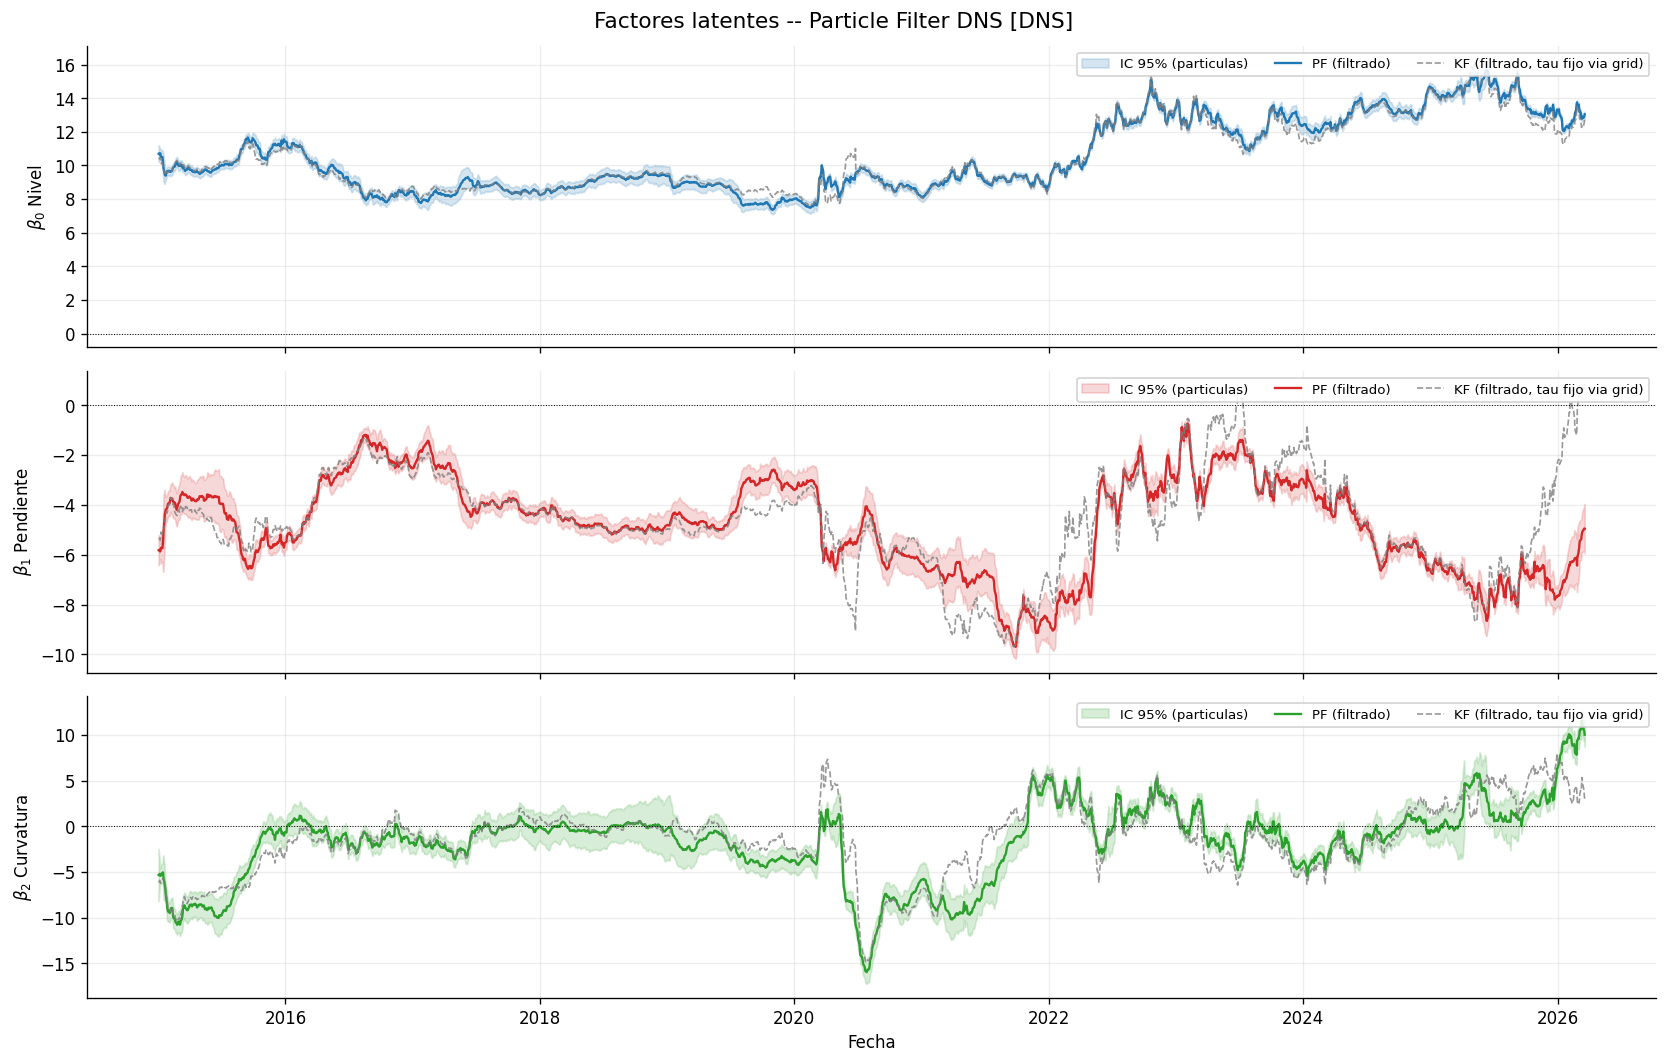

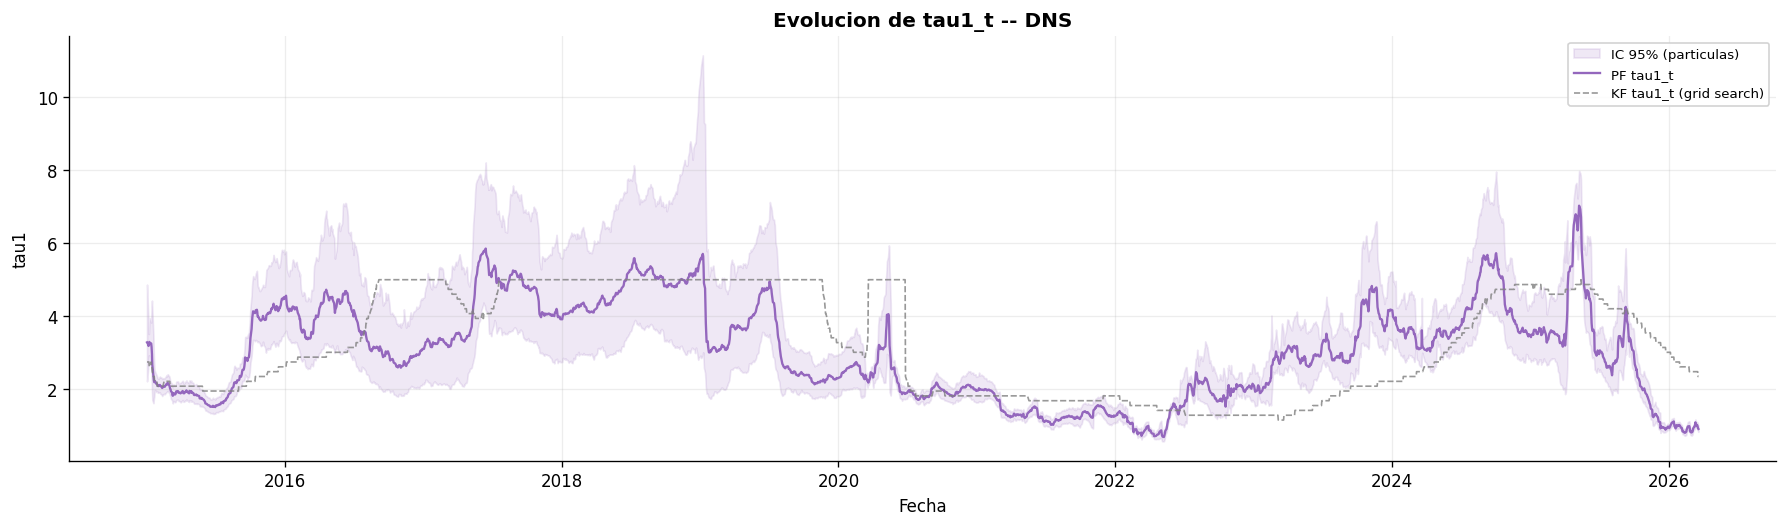

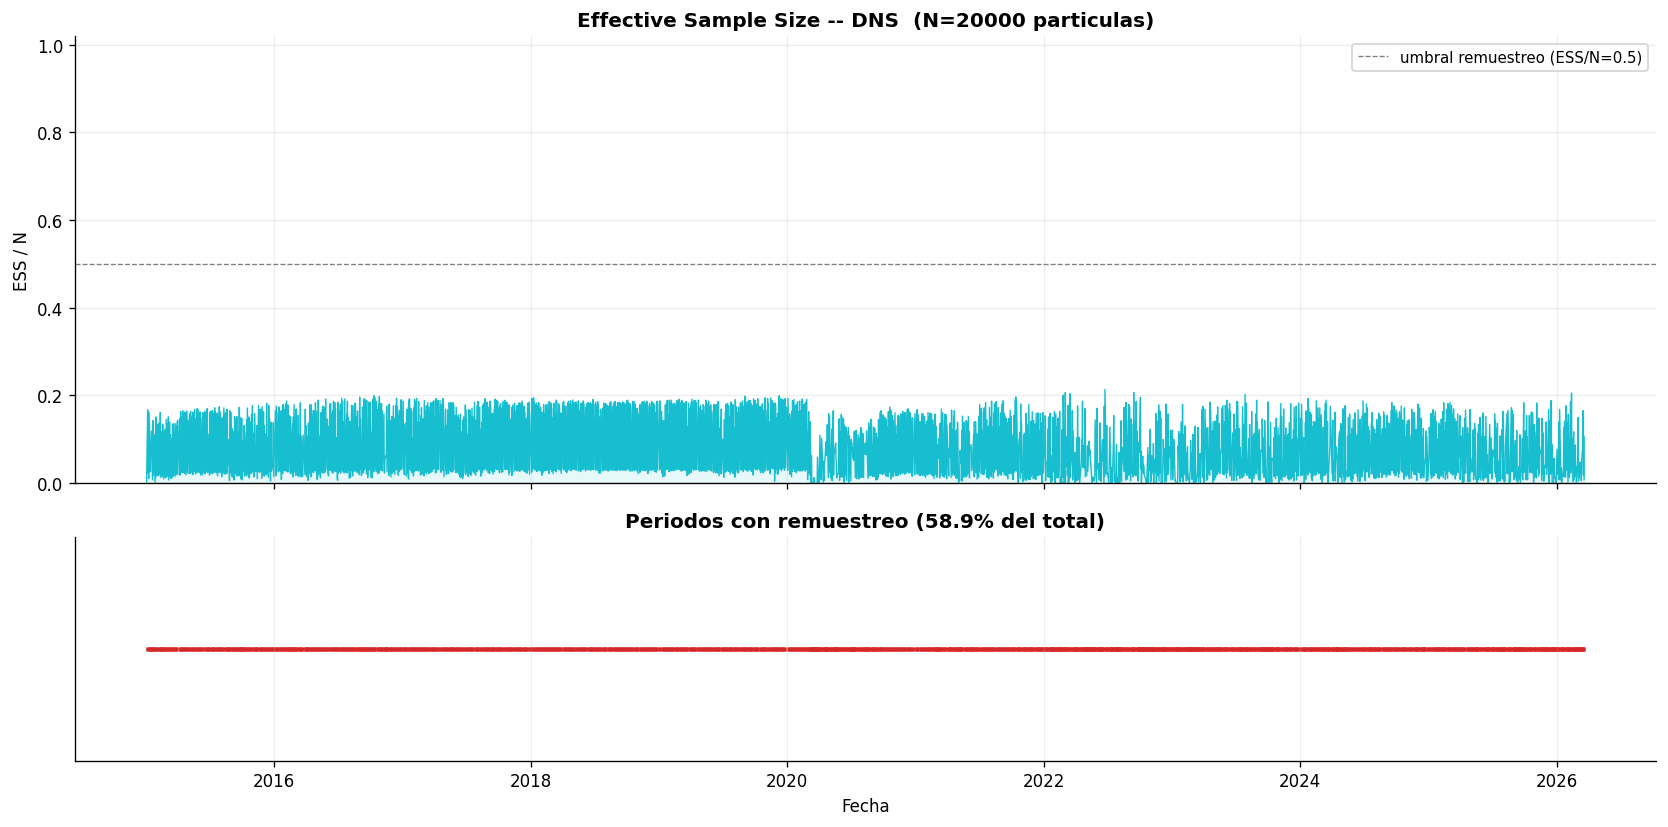


-- Diagnostico PF -- DNS --
  ESS/N: media=0.082  min=0.000  p10=0.011
  Remuestreo: 58.9% de los periodos (1611/2735)
  Log-lik (estimado SMC): 10,444.44


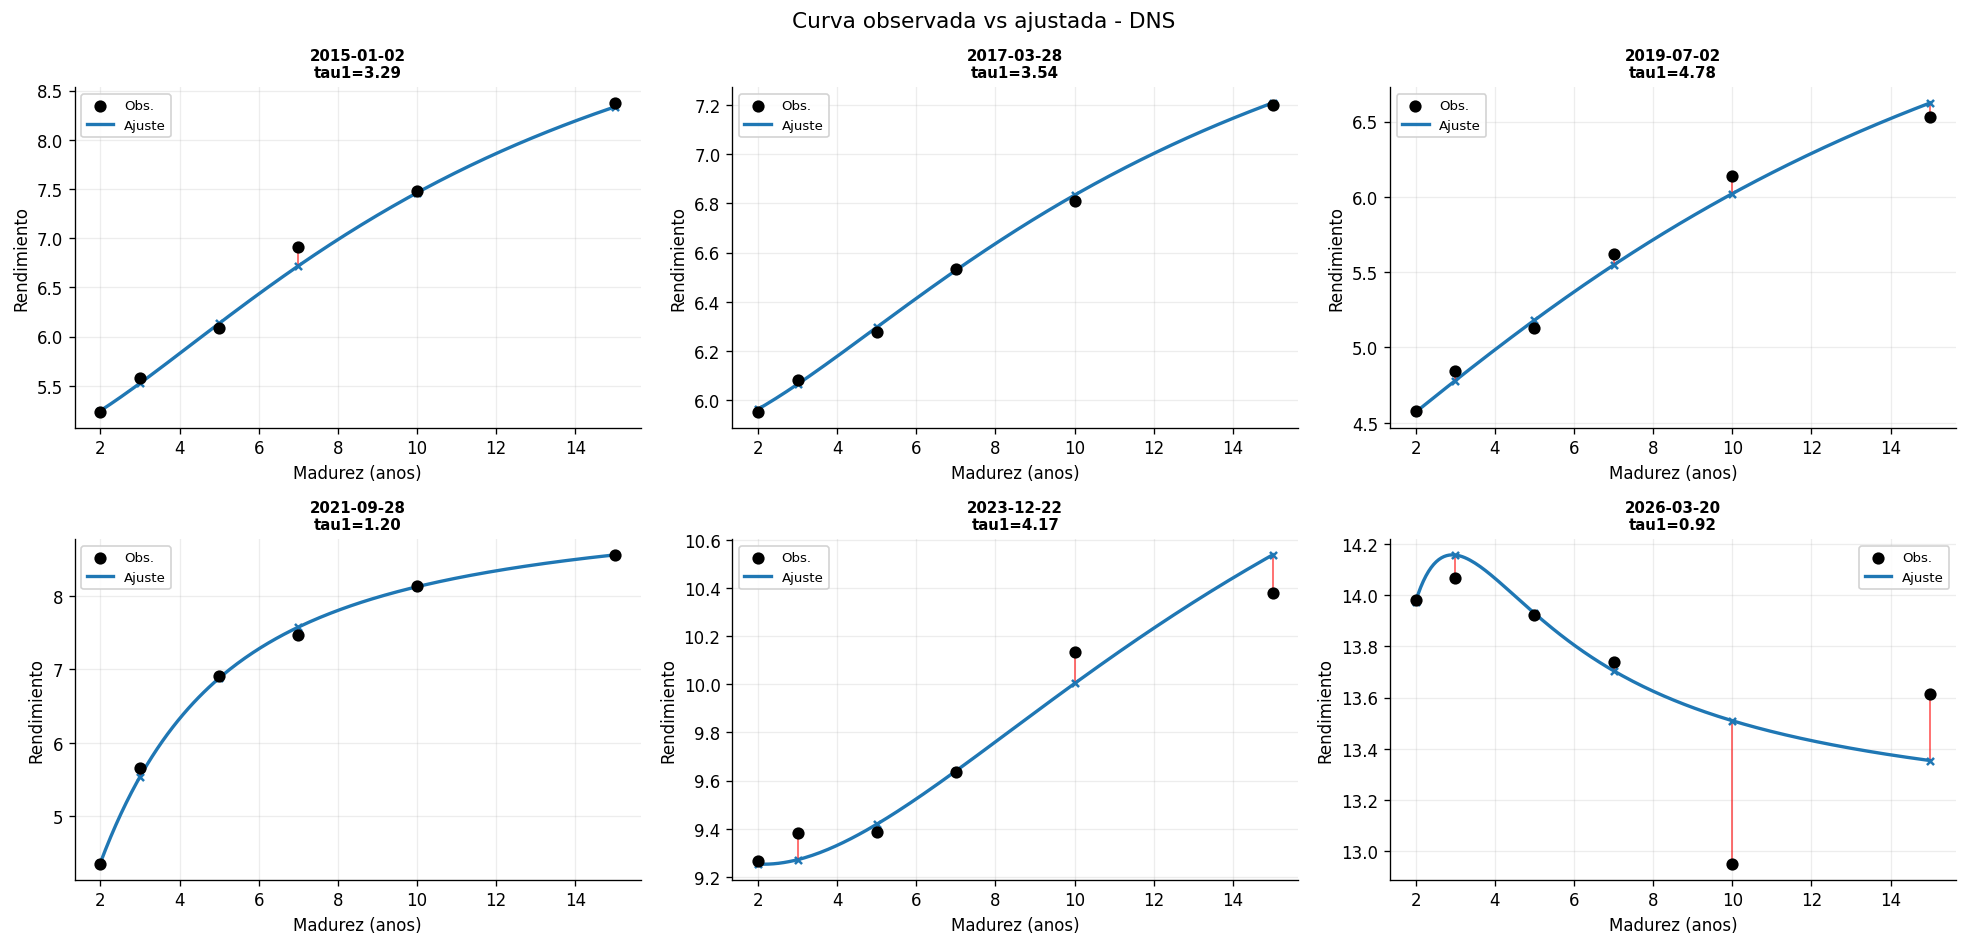

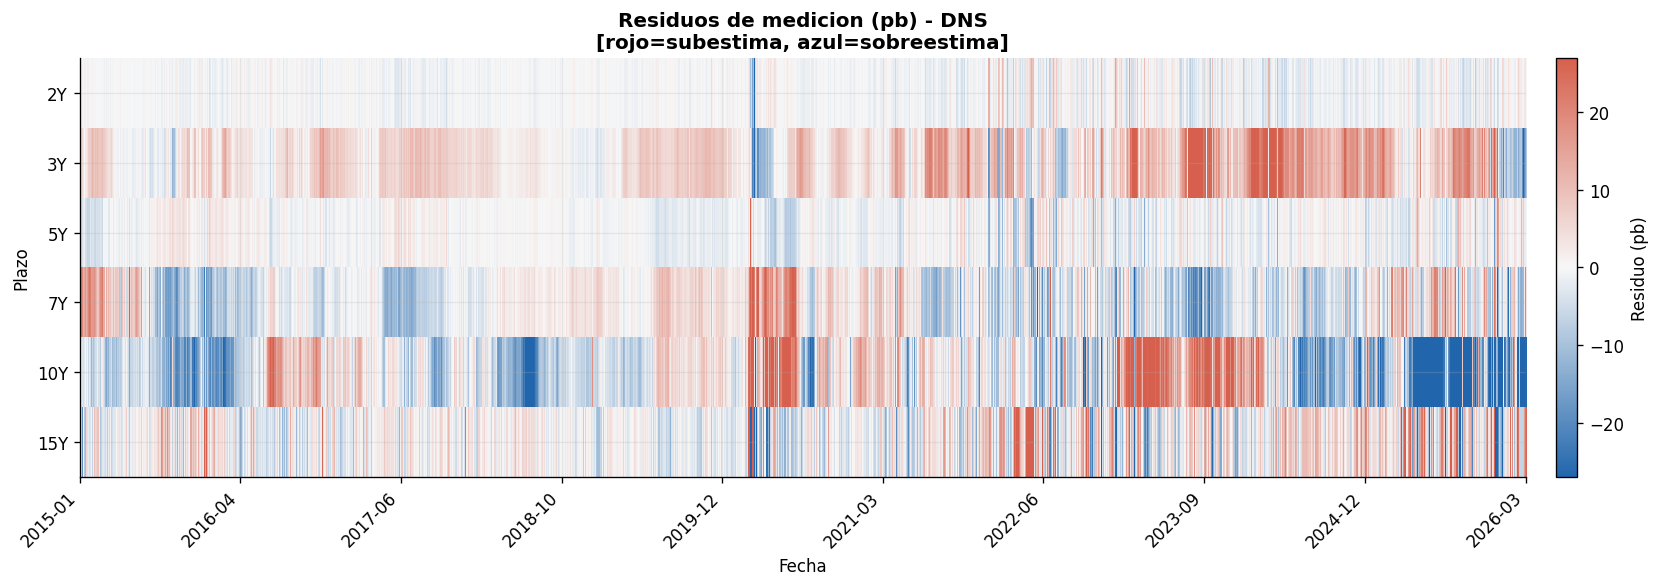

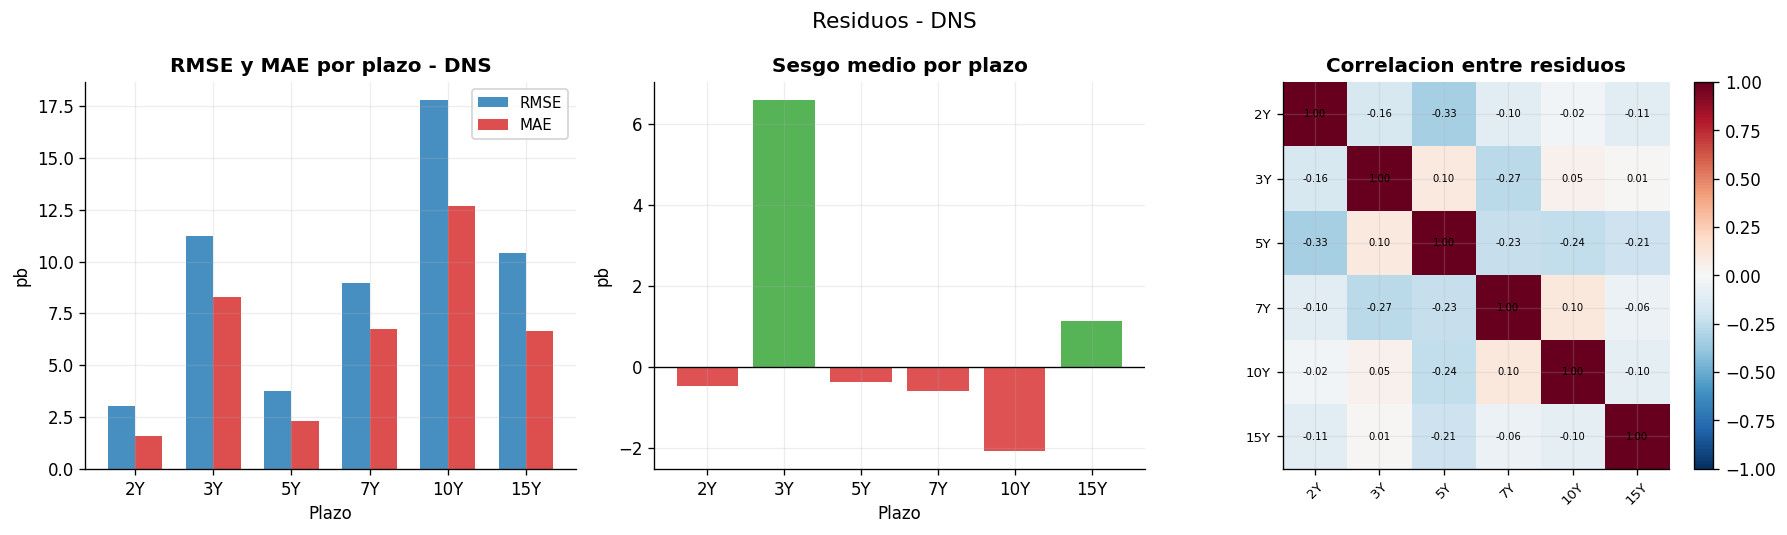

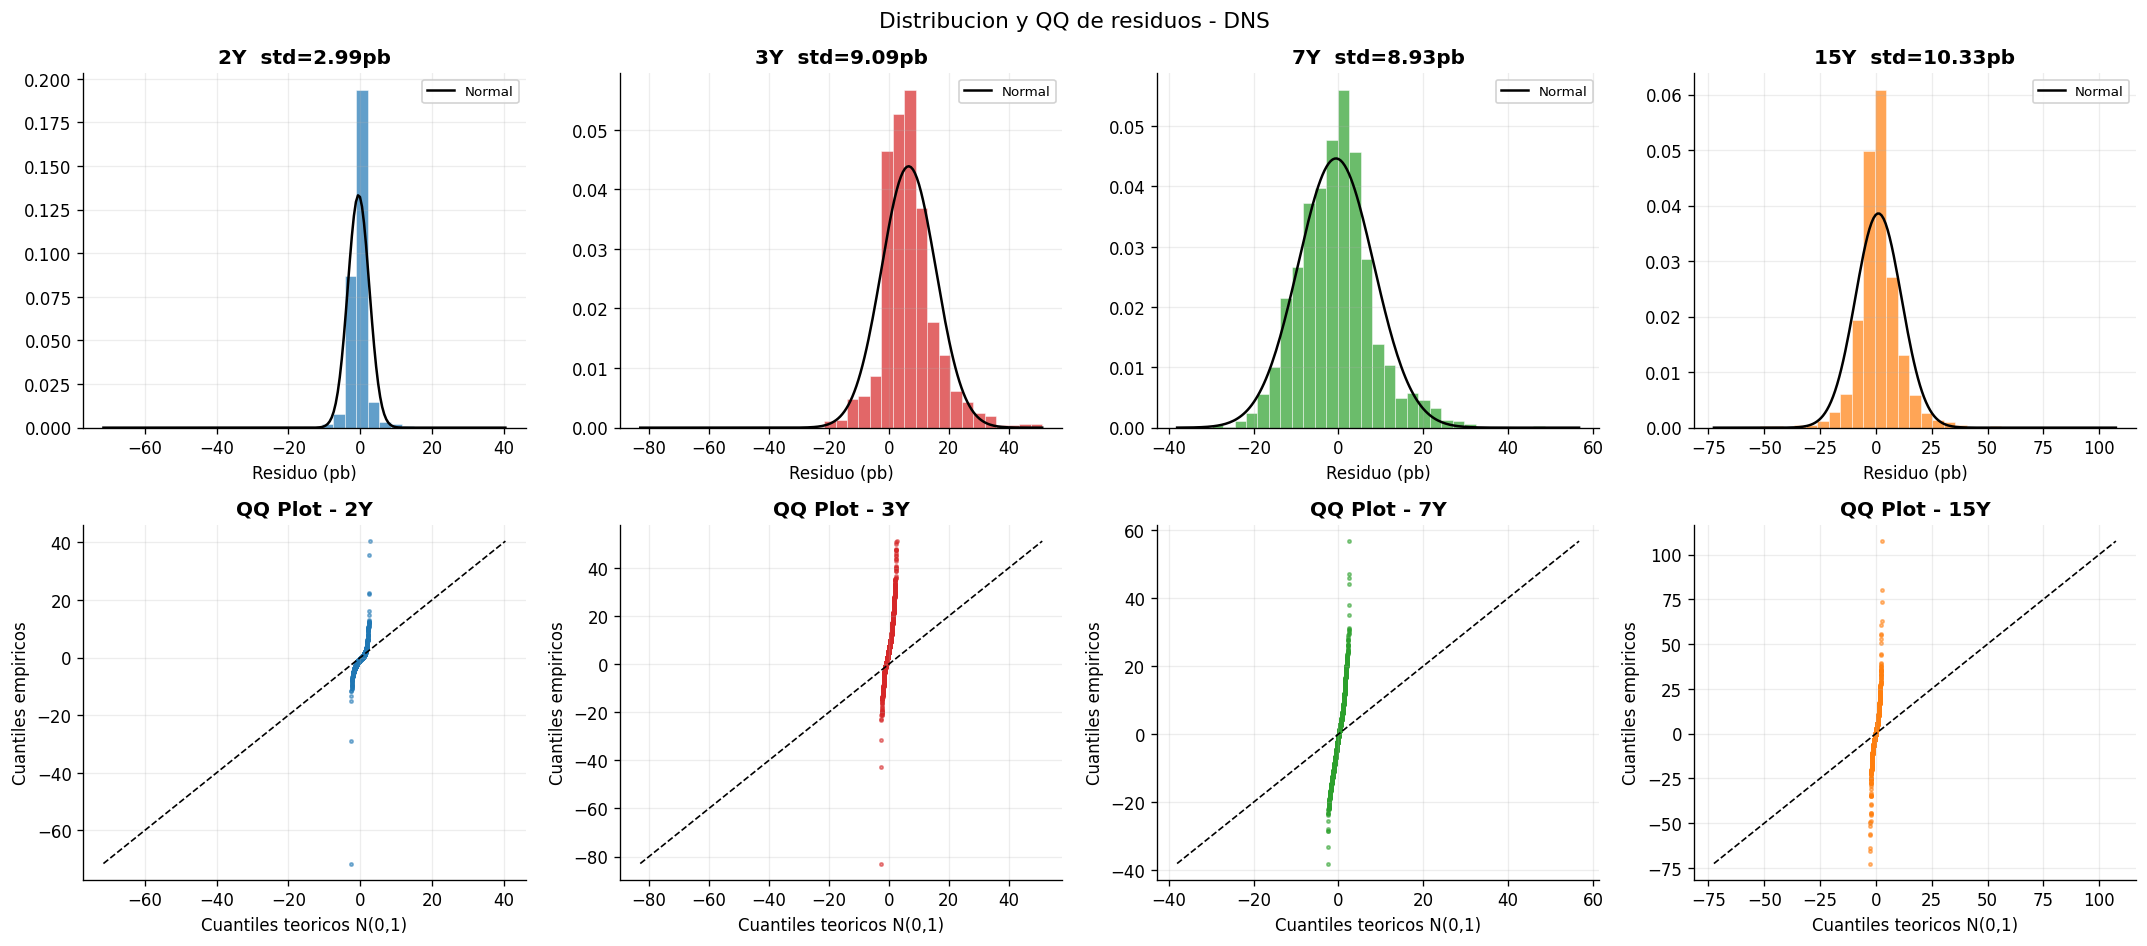


-- Tests de residuos - DNS --
  Plazo      RMSE     Sesgo   JB p-val  Normal?
     2Y     3.029    -0.484     0.0000  No  
     3Y    11.238    +6.604     0.0000  No  
     5Y     3.759    -0.377     0.0000  No  
     7Y     8.955    -0.593     0.0000  No  
    10Y    17.776    -2.086     0.0000  No  
    15Y    10.395    +1.126     0.0000  No  


In [39]:
out_dns = fit_pf_model(
    dates_dt, yields_data, maturities,
    model='DNS',
    n_particles=20000,
    window_size=max(252, T//8),
    n_starts_kf=1,
    seed=42,
    plot=True,
    verbose=True,
    q_ltau_scale= 3, #MODIFICAR EL FACTOR DE ESCALA DE Q_LTAU PARA VERIFICAR EL IMPACTO EN LA VOLATILIDAD DE TAU
    ess_threshold= 0.1 #MODIFICAR EL UMBRAL DE ESS PARA VERIFICAR EL IMPACTO EN EL REMUESTREO
)
res_kf_dns, res_pf_dns = out_dns['kf'], out_dns['pf']

# ess_threshold = 0.5 RMSE PF=10.5382pb  log-lik=10,316.50  ESS/N medio=0.135  remuestreo=100.0%  (31.78s)
# con tau scale=1.6 y ess_threshold=0.1 RMSE PF=10.5537pb  log-lik=10,046.51

# con tau scale=1.7 y ess_threshold=0.15   RMSE PF=10.4741pb  log-lik=10,464.83
# con tau scale=1.7 y ess_threshold=0.1    RMSE PF=10.4339pb  log-lik=10,577.30  (MEJOR RESULTADO HASTA AHORA)
# con tau scale=1.7 y ess_threshold=0.075  RMSE PF=10.4759pb  log-lik=10,427.14 
# con tau scale=1.7 y ess_threshold=0.2    RMSE PF=10.4621pb  log-lik=10,563.38

# con tau scale=1.8 y ess_threshold=0.1 RMSE PF=10.4339pb  log-lik=10,577.30 

## 15. Comparacion KF vs PF (DNS)

In [106]:
comparar_kf_pf(res_kf_dns, res_pf_dns)


  Comparacion KF vs PF -- DNS
  Metrica                  KF (tau grid)  PF (tau dinamico)
  ----------------------------------------------------------
  RMSE total (pb)                10.6888            10.4391
  MAE total (pb)                  6.7030             6.3796
  Log-lik                       10,276.0           10,444.4

  Nota: el log-lik del KF es la verosimilitud EXACTA de un modelo
  lineal-gaussiano CONDICIONAL en tau_t (tratado como insumo fijo
  proveniente del grid search). El log-lik del PF es una ESTIMACION
  Monte Carlo (con varianza finita en N) de la verosimilitud marginal
  de un modelo DISTINTO, donde tau_t es estocastico. No son la misma
  cantidad exacta; la comparacion es informativa, no una prueba formal.

  RMSE por plazo (pb):
  Plazo         KF         PF       Dif
     2Y     2.7394     3.0292   +0.2898
     3Y    11.7108    11.2380   -0.4728
     5Y     3.7385     3.7595   +0.0209
     7Y     9.8069     8.9545   -0.8524
    10Y    18.3486    17.7765   

In [42]:
reporte_aic_bic(res_kf_dns, res_pf_dns, model="DNS")


  AIC / BIC -- DNS   (T=2735 observaciones)
  Modelo                          k       log-lik           AIC           BIC
  --------------------------------------------------------------------
  KF (tau fijo via grid)         15      10,276.0     -20,521.9     -20,433.2
  PF (k = solo tau, nuevo)        3      10,444.4     -20,882.9     -20,865.1
  PF (k = sistema completo)      18      10,444.4     -20,852.9     -20,746.4

  Nota: el log-lik del PF tiene varianza de Monte Carlo finita en N --
  estos AIC/BIC heredan esa varianza. Para una conclusion robusta, recalcular
  con 3-5 semillas distintas y reportar el rango, no solo el punto estimado.
  La fila 'k = sistema completo' es la comparable en terminos de convencion
  de conteo contra el KF; la fila 'k = solo tau' aisla el costo de la extension.


{'kf': {'k': 15,
  'aic': -20521.93752215346,
  'bic': np.float64(-20433.229221430618)},
 'pf_nuevo': {'k': 3,
  'k_mode': 'nuevo',
  'T': 2735,
  'loglik': np.float64(10444.440164376534),
  'aic': np.float64(-20882.880328753068),
  'bic': np.float64(-20865.1386686085)},
 'pf_total': {'k': 18,
  'k_mode': 'total',
  'T': 2735,
  'loglik': np.float64(10444.440164376534),
  'aic': np.float64(-20852.880328753068),
  'bic': np.float64(-20746.43036788566)}}

## 16. Validacion contra el proceso generador (solo en el caso sintetico)

Si los datos provienen del fallback sintetico (no del CSV real), se conoce la tau_t
*verdadera* que genero los datos. Esto permite una validacion que normalmente es imposible con
datos reales: comparar directamente la capacidad del PF (que asume tau dinamico, el modelo
correcto aqui) contra la del KF (que asume tau fijo, un modelo mal especificado para esta
serie) en recuperar el path real.

In [19]:
if '_SINTETICO_TRUE' in dir():
    tau1_true = _SINTETICO_TRUE['tau1_true']
    corr_pf = np.corrcoef(res_pf_dns['tau1_t'], tau1_true)[0,1]
    corr_kf = np.corrcoef(res_kf_dns['tau1_t'], tau1_true)[0,1]
    rmse_pf = np.sqrt(np.mean((res_pf_dns['tau1_t']-tau1_true)**2))
    rmse_kf = np.sqrt(np.mean((res_kf_dns['tau1_t']-tau1_true)**2))
    print(f"Correlacion con tau1 verdadero -- PF: {corr_pf:.4f}   KF (grid search): {corr_kf:.4f}")
    print(f"RMSE contra tau1 verdadero     -- PF: {rmse_pf:.4f}   KF (grid search): {rmse_kf:.4f}")

    fig, ax = plt.subplots(figsize=(14,4.5))
    ax.plot(dates_dt, tau1_true, color='k', lw=1.3, label='Verdad (proceso generador)')
    ax.plot(dates_dt, res_pf_dns['tau1_t'], color=COLOR_PF, lw=1.1, label='PF (tau dinamico)')
    ax.plot(dates_dt, res_kf_dns['tau1_t'], color=COLOR_KF, lw=1.0, ls='--', label='KF (grid search, tau fijo por ventana)')
    ax.legend(); ax.set_title('Recuperacion de tau1_t -- PF vs KF vs verdad (dataset sintetico)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout(); plt.show()
else:
    print("Usando datos reales -- no hay 'verdad' contra la cual comparar (paso informativo, se omite).")

Usando datos reales -- no hay 'verdad' contra la cual comparar (paso informativo, se omite).


## 17. Chequeo de consistencia: PF con tau ~ fijo debe aproximar al KF


-- Chequeo de consistencia (q_ltau -> ~0) -- DNS --
  RMSE KF             = 10.6888 pb
  RMSE PF (tau~fijo)  = 11.3564 pb
  tau1 corr (PF vs KF)= 0.2901
  (esperado: RMSE similar y correlacion alta -- confirma que el PF
   colapsa razonablemente al caso lineal-gaussiano del KF)


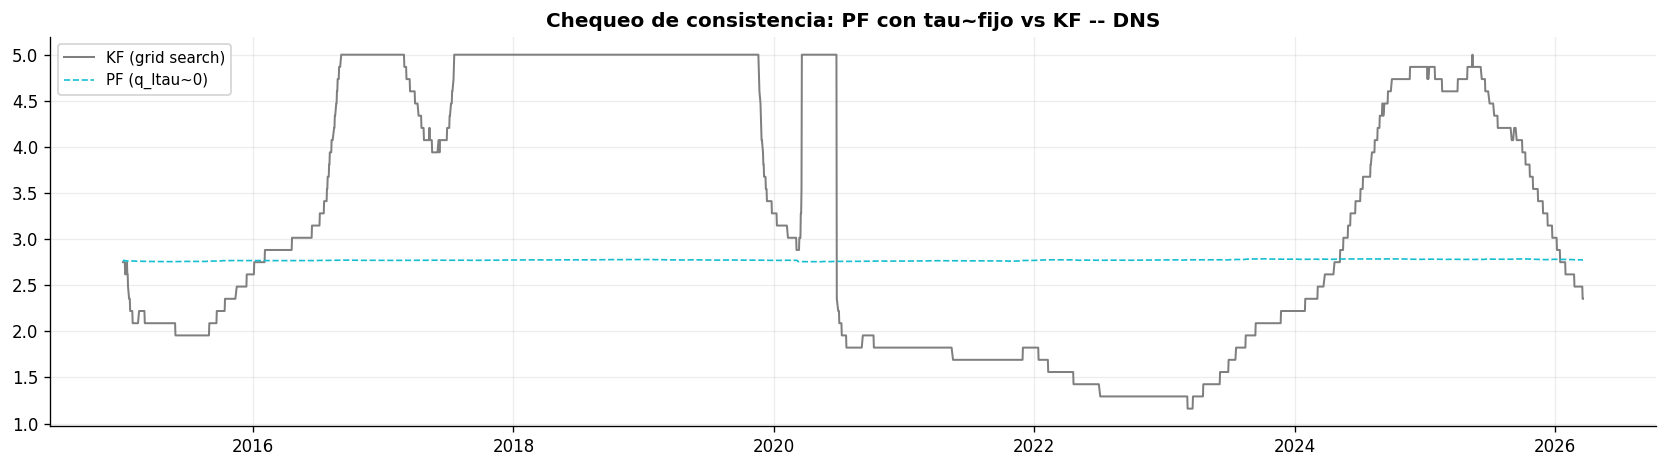

In [61]:
_ = chequeo_consistencia_pf(res_kf_dns, yields_data, maturities, dates_dt, model='DNS', n_particles=5000, seed=1)

**Lectura honesta de este resultado:** la correlacion entre el path de tau1 del PF
(forzado casi-constante) y el tau1_t del KF suele resultar moderada, no cercana a 1 -- y esto es
esperado, no un error. El tau1_t del KF tampoco es realmente constante: proviene de un Grid
Search con ventana movil que SI se adapta localmente en el tiempo. La metrica que SI es
comparable directamente es el RMSE de ajuste (ambos deberian quedar en el mismo orden de
magnitud). Una comparacion mas estricta requeriria un KF con un unico tau global
(window_size=None) en lugar del KF adaptativo.

## 18. Sensibilidad a N_particulas

Cuantas particulas son necesarias para que el log-lik estimado se estabilice (deje de moverse
significativamente al aumentar N)? Esto informa el trade-off entre precision de Monte Carlo y
tiempo de computo para el resto del analisis.


-- Sensibilidad a N_particulas -- DNS --
        N       log-lik   RMSE(pb)   tiempo(s)
      500       8,464.0    11.2390        3.66
     1000       8,858.2    11.2180        4.49
     2000       9,371.0    10.9205        6.51
     5000       9,894.2    10.6745       11.80
    10000      10,253.8    10.5264       22.62
    15000      10,466.8    10.4555       29.24
    20000      10,149.2    10.6630       48.65
    30000      10,246.5    10.4937      113.04
    40000      10,416.8    10.4744      155.20
    50000      10,738.9    10.3831      208.99


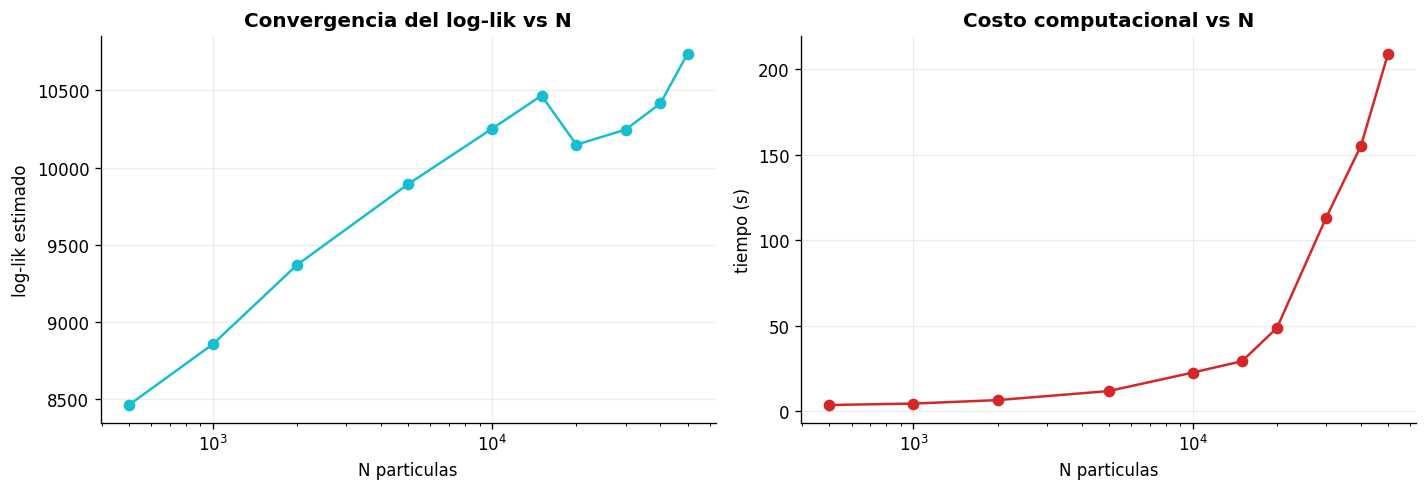

In [66]:
_ = sensibilidad_n_particulas(res_kf_dns, yields_data, maturities, dates_dt, model='DNS', n_particulas_grid=(500,1000,2000,5000,10000,15000,20000,30000,40000,50000), seed=1)


-- Sensibilidad a N_particulas -- DNS --
        N       log-lik   RMSE(pb)   tiempo(s)
    50000      10,738.9    10.3831      216.94
    75000      10,637.6    10.3820      310.68
   100000      10,751.3    10.3372      417.00
   200000      10,770.5    10.3011      874.99


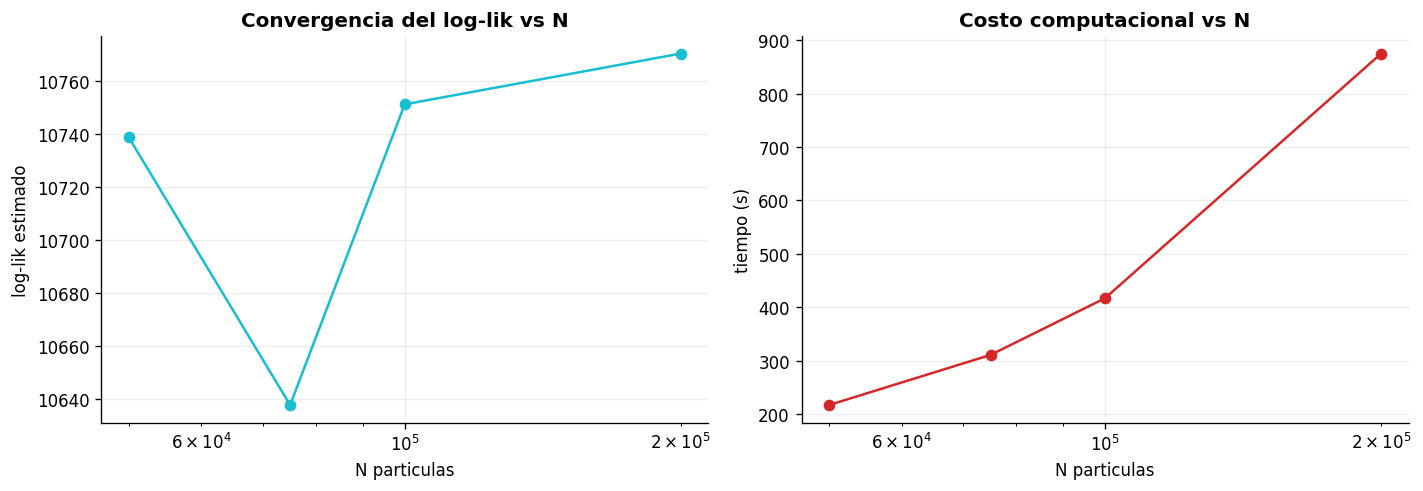

In [69]:
_ = sensibilidad_n_particulas(res_kf_dns, yields_data, maturities, dates_dt, model='DNS', n_particulas_grid=(50000,75000,100000,200000), seed=1)

## 19. Sensibilidad a q_ltau_scale

Como cambia el path estimado de tau1_t (y el ajuste) al permitirle moverse mas o menos de lo
que sugiere la calibracion OLS directa sobre la serie del Grid Search del KF. Recordar la
advertencia de la seccion 6: esa serie tiende a SUBESTIMAR la verdadera variabilidad de tau,
por lo que vale la pena mirar tambien escalas > 1.


-- Sensibilidad a q_ltau_scale -- DNS --
    scale    sqrt(q)       log-lik   RMSE(pb)   std(diff tau1)
     0.10     0.0061       9,816.7    10.9174          0.00901
     0.50     0.0137      10,213.7    10.6001          0.02476
     1.00     0.0193      10,253.8    10.5264          0.03823
     2.00     0.0273      10,012.5    10.5581          0.06510
     3.00     0.0334      10,373.1    10.4294          0.06991
     3.50     0.0361      10,450.9    10.4468          0.08973
     4.00     0.0386      10,298.9    10.4456          0.10066


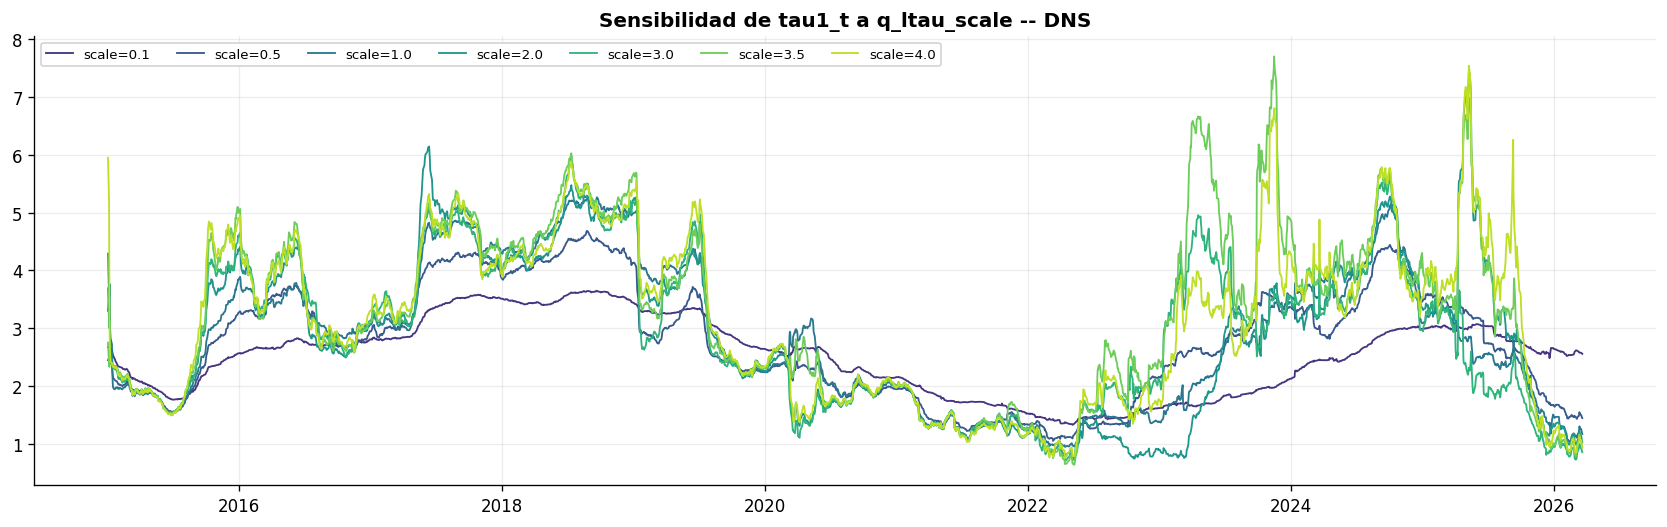

In [63]:
_ = sensibilidad_q_ltau(res_kf_dns, yields_data, maturities, dates_dt, model='DNS', scales=(0.1,0.5,1.0,2.0,3.0,3.5,4.0), n_particles=10000, seed=1)

## 20. Innovaciones Gaussianas vs Student-t (colas pesadas)

Conexion directa con el hallazgo de fases anteriores: QQ-plots con colas pesadas en ciertos
plazos. Aqui se compara formalmente, via log-lik, si una distribucion Student-t (con distintos
grados de libertad) describe mejor la ecuacion de medicion que la Gaussiana estandar.

In [64]:
_ = comparar_innovaciones(res_kf_dns, yields_data, maturities, dates_dt, model='DNS', dfs=(3,5,6,7,8,9,10), n_particles=10000, seed=1)


-- Gaussiana vs Student-t -- DNS --
  Gaussiana        : log-lik=10,253.8  RMSE=10.5264pb
  Student-t (df= 3) : log-lik=11,849.4  RMSE=11.2758pb
  Student-t (df= 5) : log-lik=11,599.3  RMSE=11.0717pb
  Student-t (df= 6) : log-lik=11,573.9  RMSE=10.9995pb
  Student-t (df= 7) : log-lik=11,543.8  RMSE=10.8683pb
  Student-t (df= 8) : log-lik=11,352.3  RMSE=11.0182pb
  Student-t (df= 9) : log-lik=11,518.8  RMSE=10.7622pb
  Student-t (df=10) : log-lik=11,317.0  RMSE=10.8041pb

  Nota: log-lik mas alto sugiere que esa distribucion explica mejor los datos.
  Si Student-t con df bajo domina de forma consistente, es evidencia a favor
  de las colas pesadas detectadas en los QQ-plots de fases anteriores.


## 21. Extension: DNSS con restriccion direccional dinamica

Mismo pipeline, mismas funciones (`fit_pf_model` y `comparar_kf_pf` son genericas en
`model='DNS'|'DNSS'`) -- la unica diferencia real es que ahora hay 2 valores de tau por
periodo, y la restriccion `tau1 > tau2 + sep_min` se aplica particula-por-particula en cada
paso (ver `enforce_tau_order`, seccion 7), en vez de descartar pares invalidos de un grid
estatico como hace `rolling_tau_dnss`.

Esto tarda mas que el caso DNS (el warm-start del KF para DNSS busca sobre una grilla 2-D de
tau1 x tau2, y el MLE tiene un parametro adicional), asi que se usa `n_starts_kf=2` para
mantener el tiempo de ejecucion razonable.

**Nota sobre la magnitud de la brecha KF vs PF en DNSS:** la grilla de busqueda
(`tau1_grid`, `tau2_grid`) usada aqui para el warm-start del KF es generica (no la grilla
asimetrica ya calibrada en el notebook `DNS_DNSS_KalmanFilter_Adaptativo`, ajustada con la
restriccion direccional y los rangos especificos del proyecto). Si la mediana de tau1_t del
grid search queda cerca del borde superior de la grilla generica, el KF de warm-start puede
estar sub-ajustado, lo que infla artificialmente la ventaja aparente del PF. Antes de reportar
esta comparacion como resultado definitivo, conviene rehacer el warm-start con la grilla ya
calibrada del proyecto.

[1/3] Obteniendo KF warm-start (cache si esta disponible)...
[KF cache] HIT  -- usando warm-start guardado (./cache_kf_warmstart\kf_DNSS_f10ef1014c1f46a7.pkl)
           RMSE=9.8608pb  log-lik=10,301.58
[2/3] Calibrando dinamica AR(1) de tau...
    tau1: mu=3.529  phi=0.9907  sqrt(q)=0.0265
    tau2: mu=0.868  phi=0.9829  sqrt(q)=0.0586
[3/3] Particle Filter (DNSS, N=20000 particulas)...
  [############################] 100.0%  t=2735/2735  ESS/N=0.05  remuestreos=2735  47 it/s  transcurrido=57.6s  ETA=0.0s    
    RMSE PF=8.3011pb  log-lik=12,241.15  ESS/N medio=0.068  remuestreo=100.0%  (57.69s)


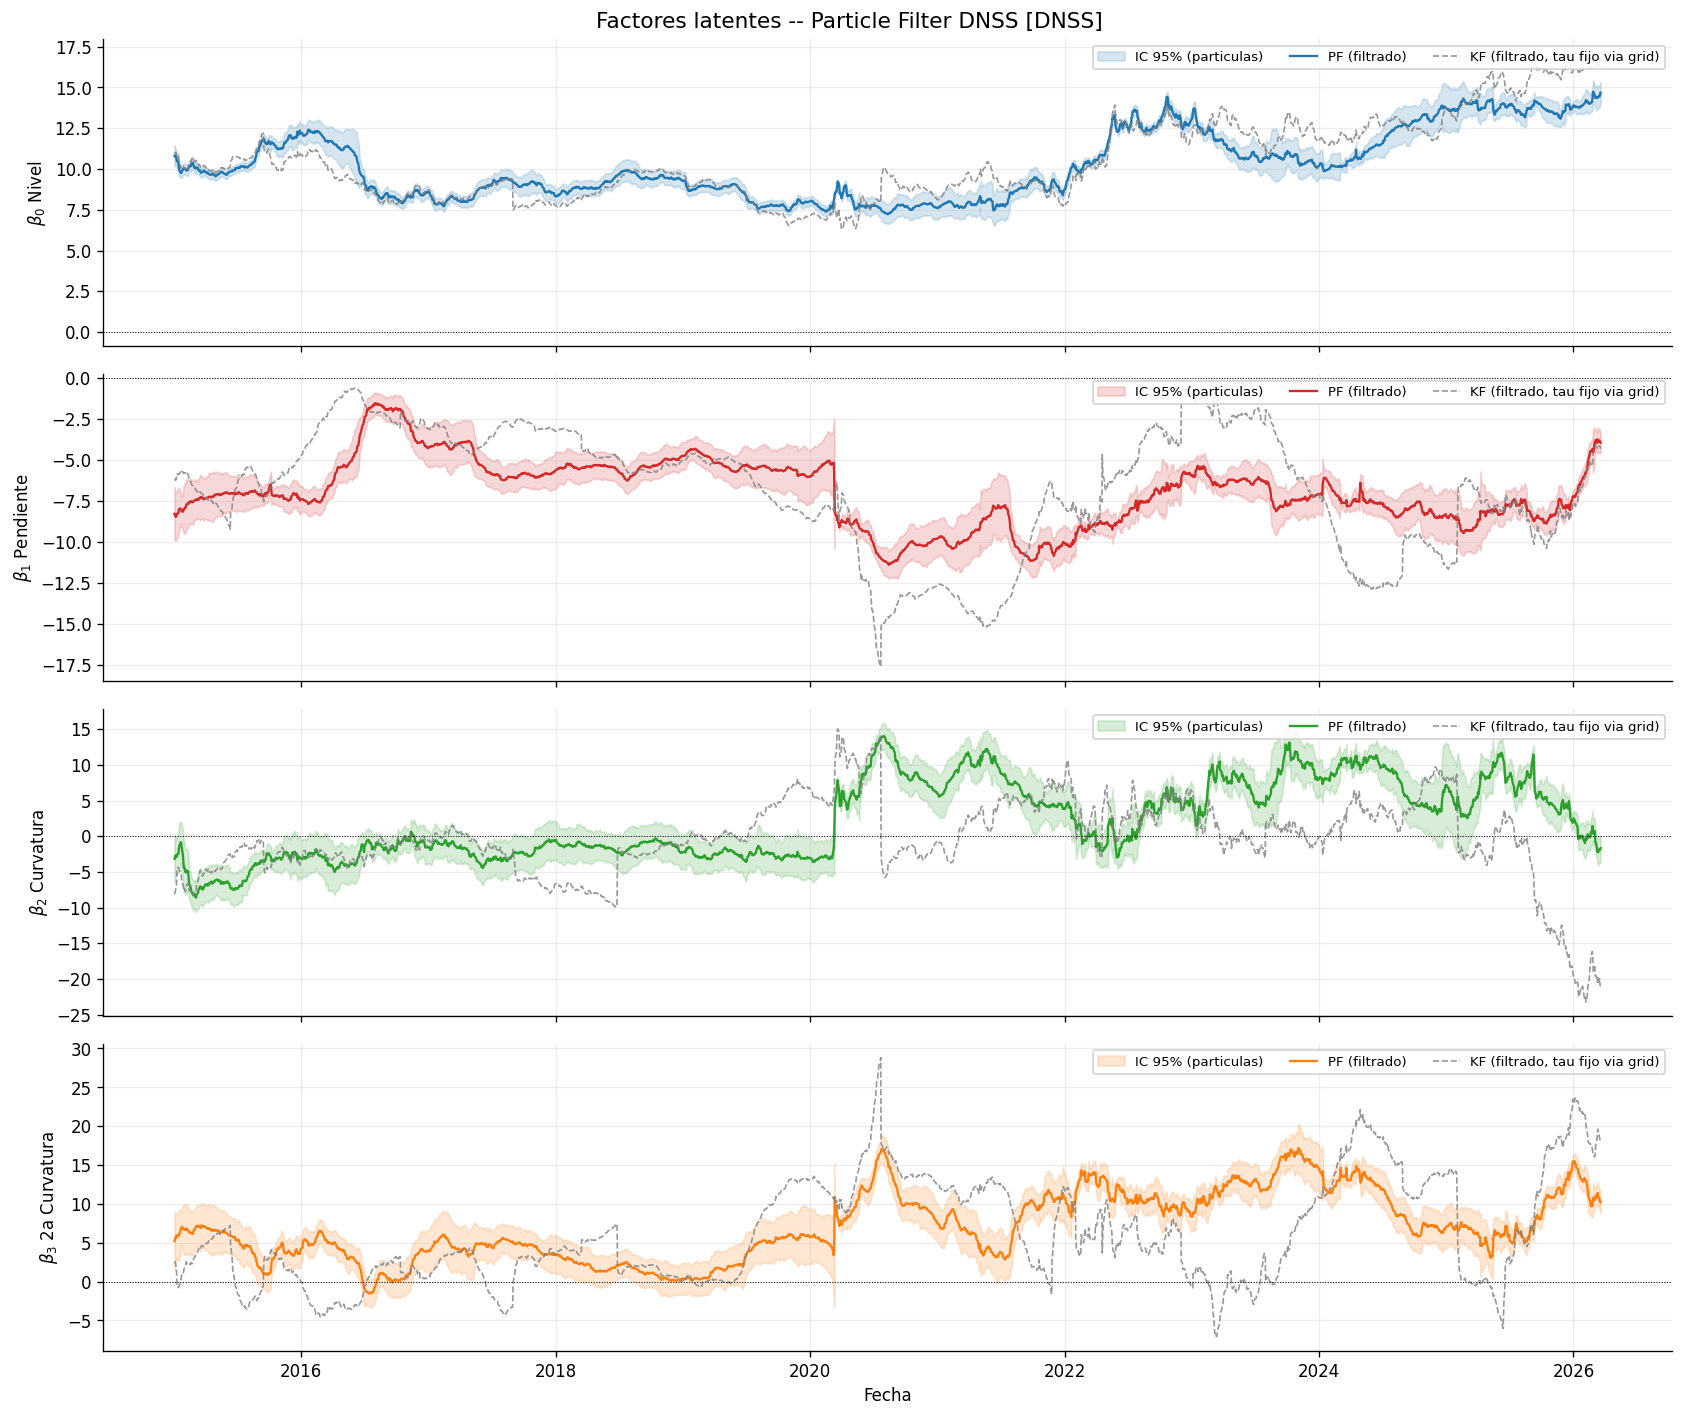

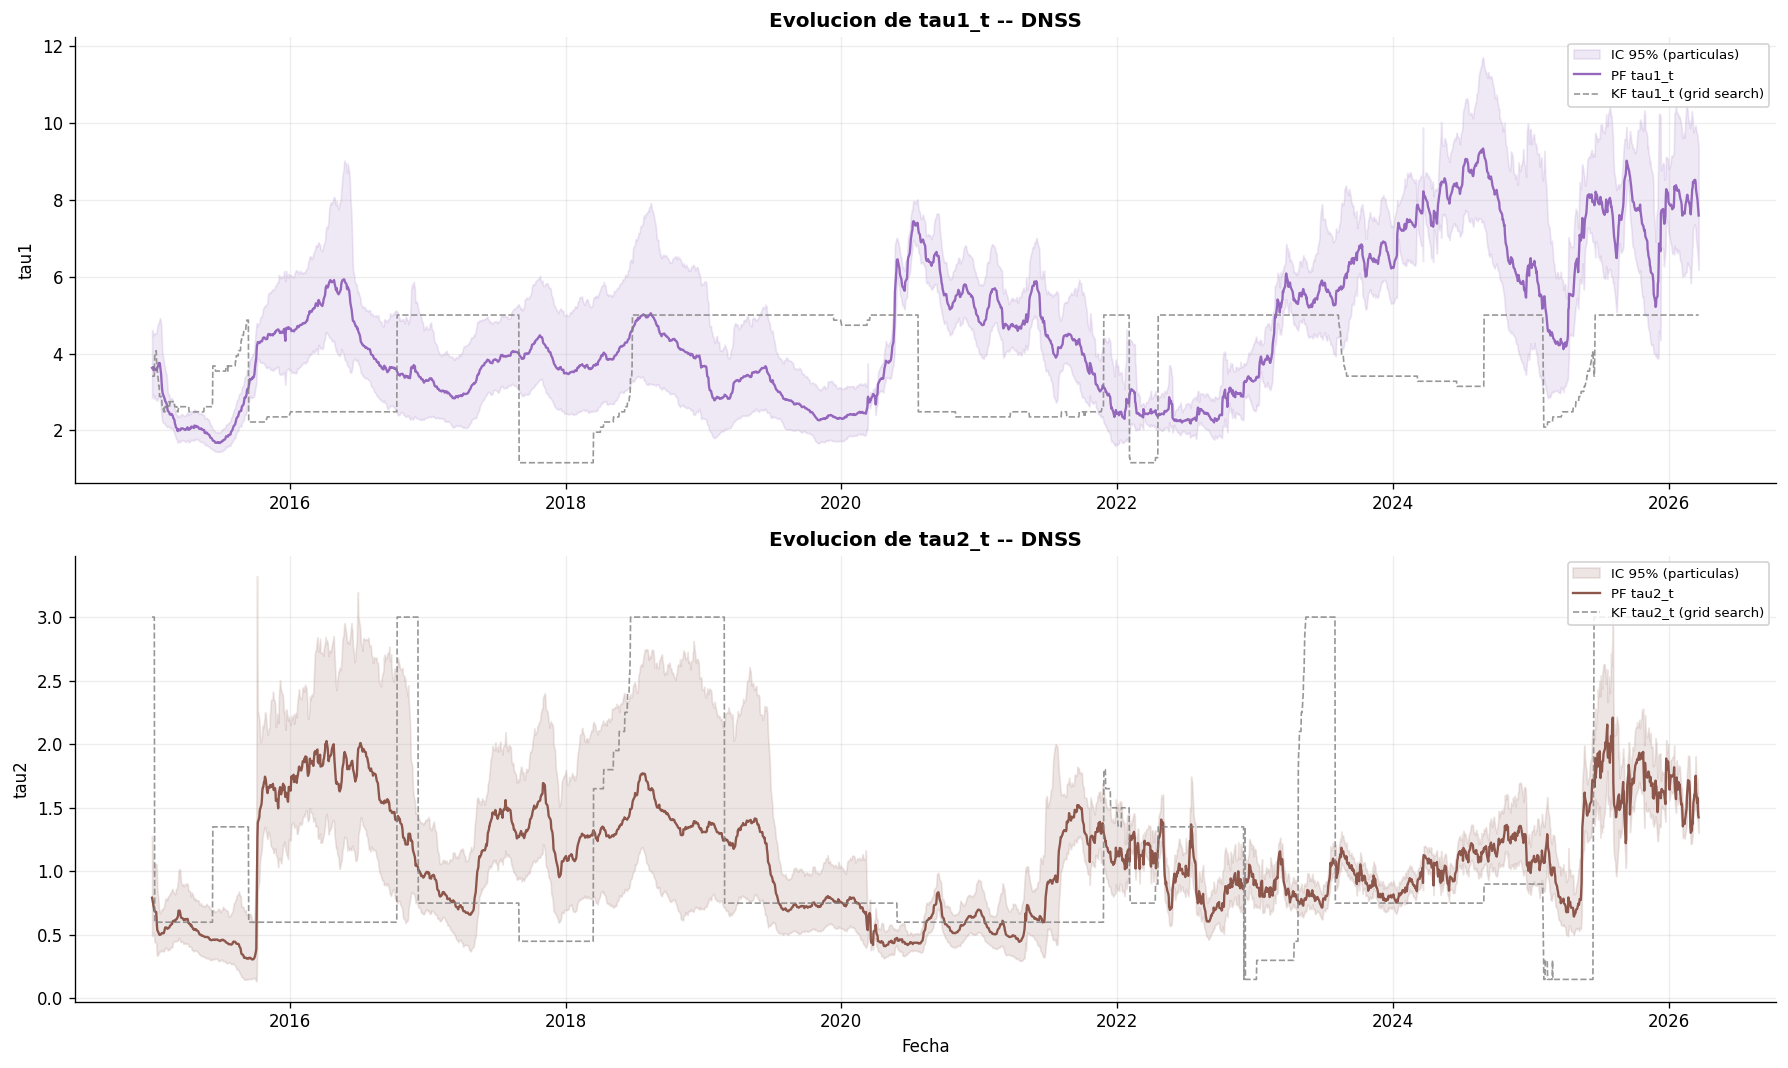

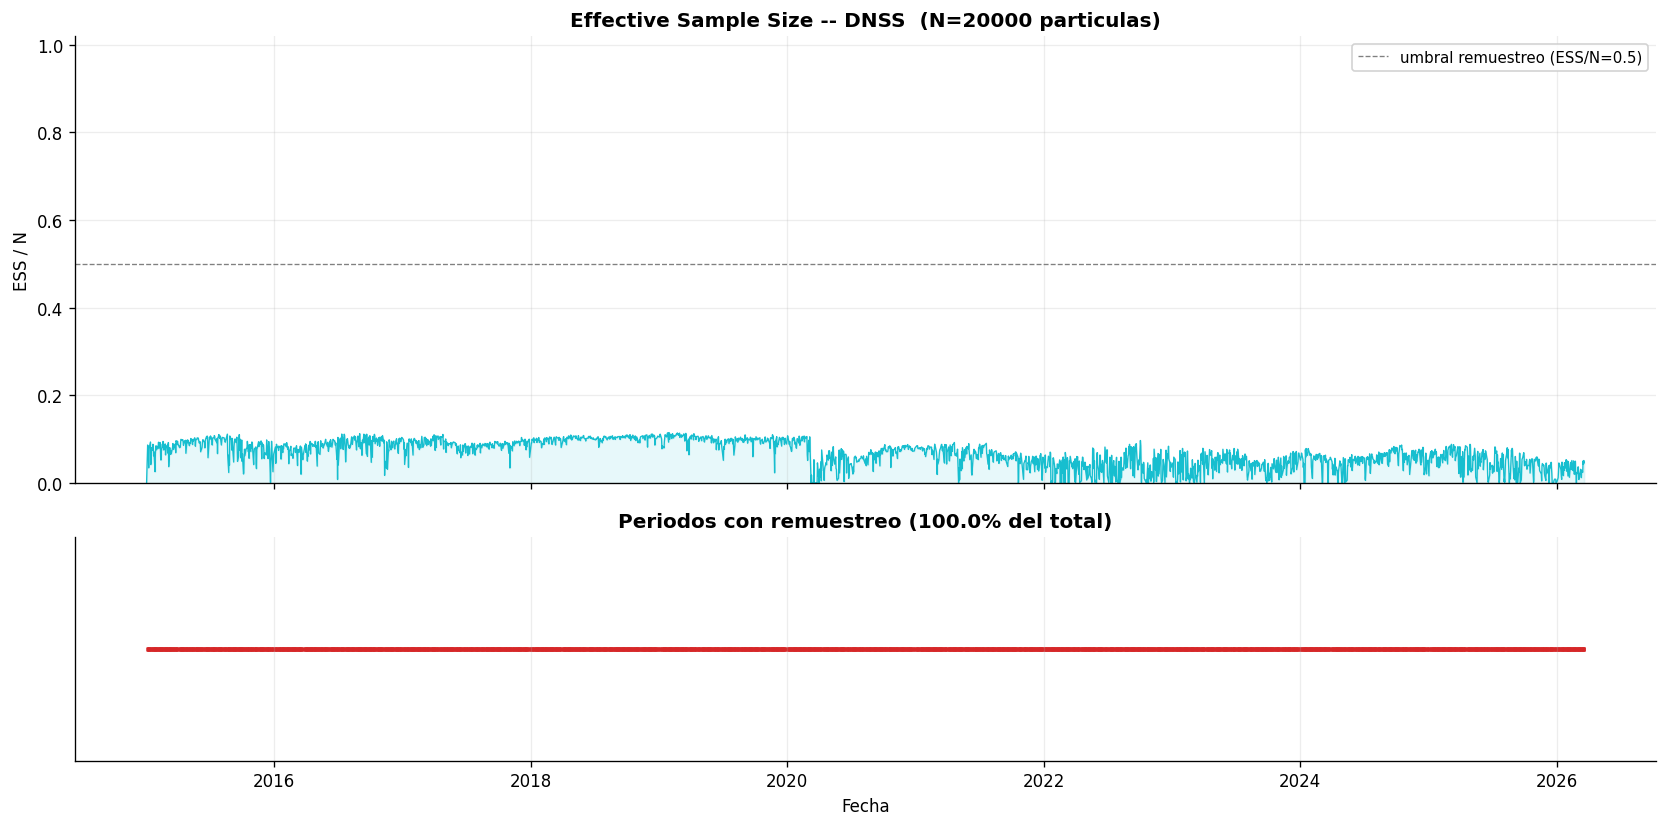


-- Diagnostico PF -- DNSS --
  ESS/N: media=0.068  min=0.000  p10=0.024
  Remuestreo: 100.0% de los periodos (2735/2735)
  Log-lik (estimado SMC): 12,241.15


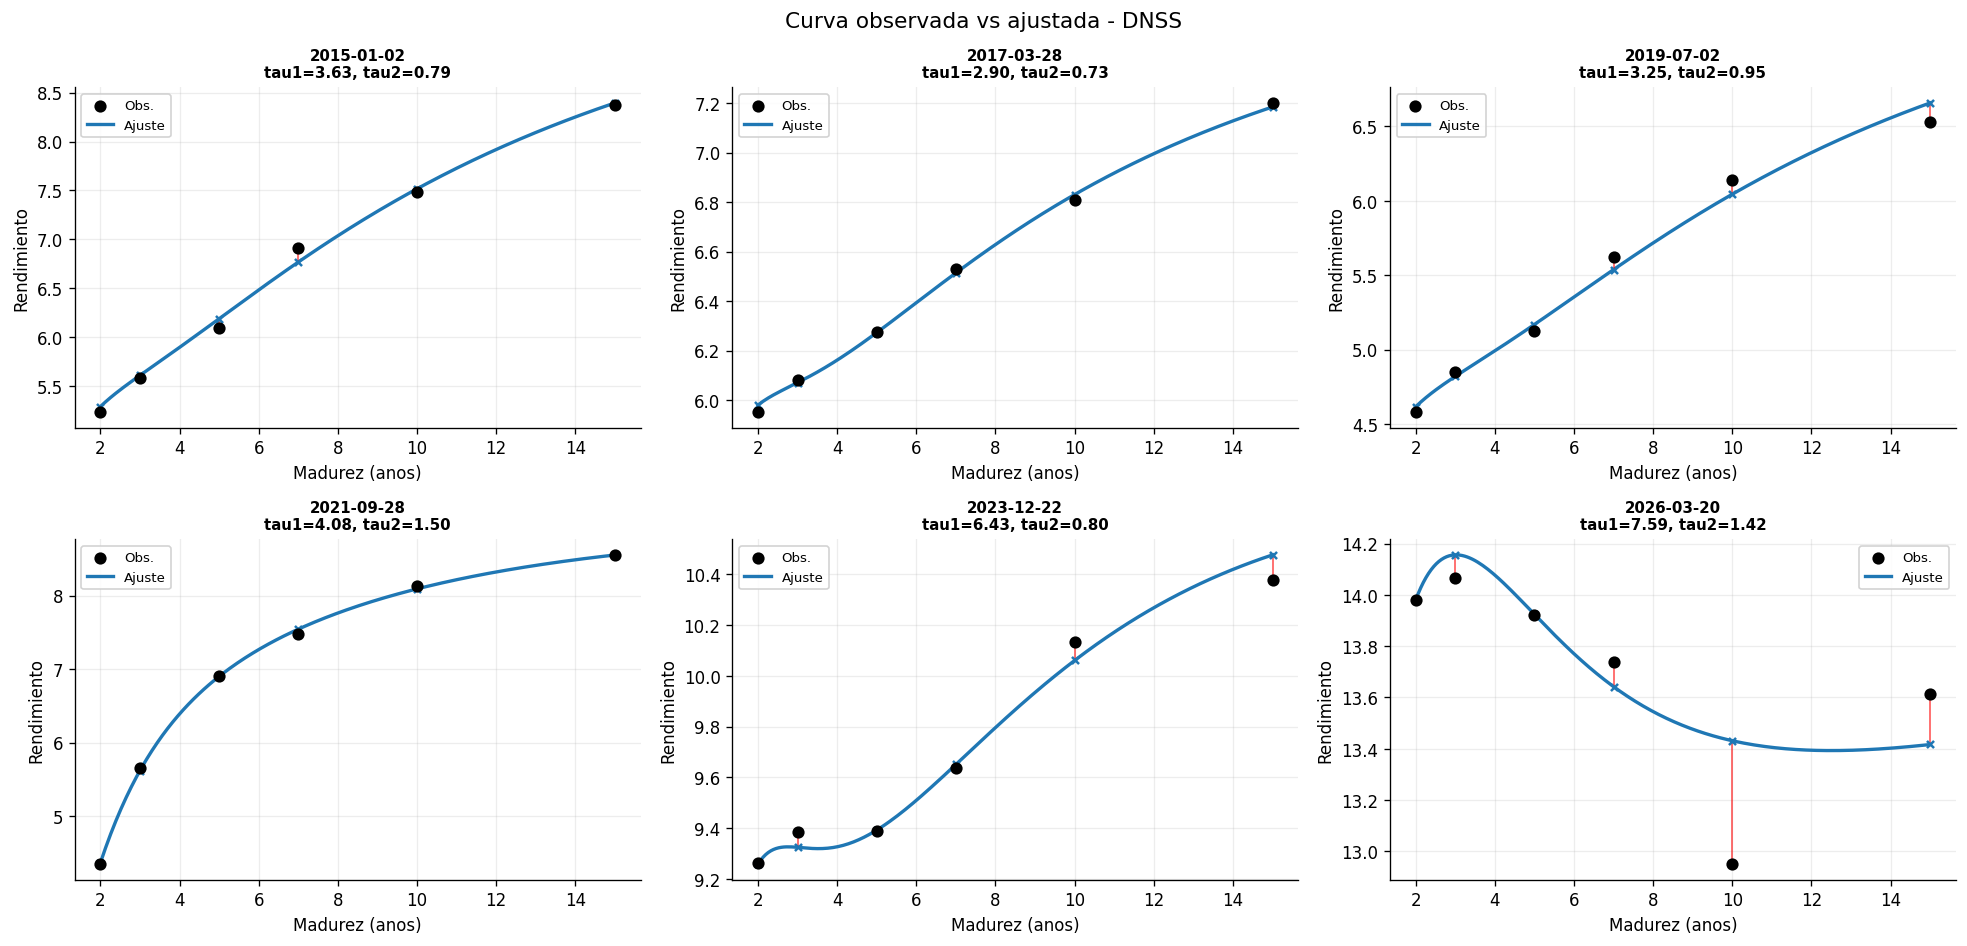

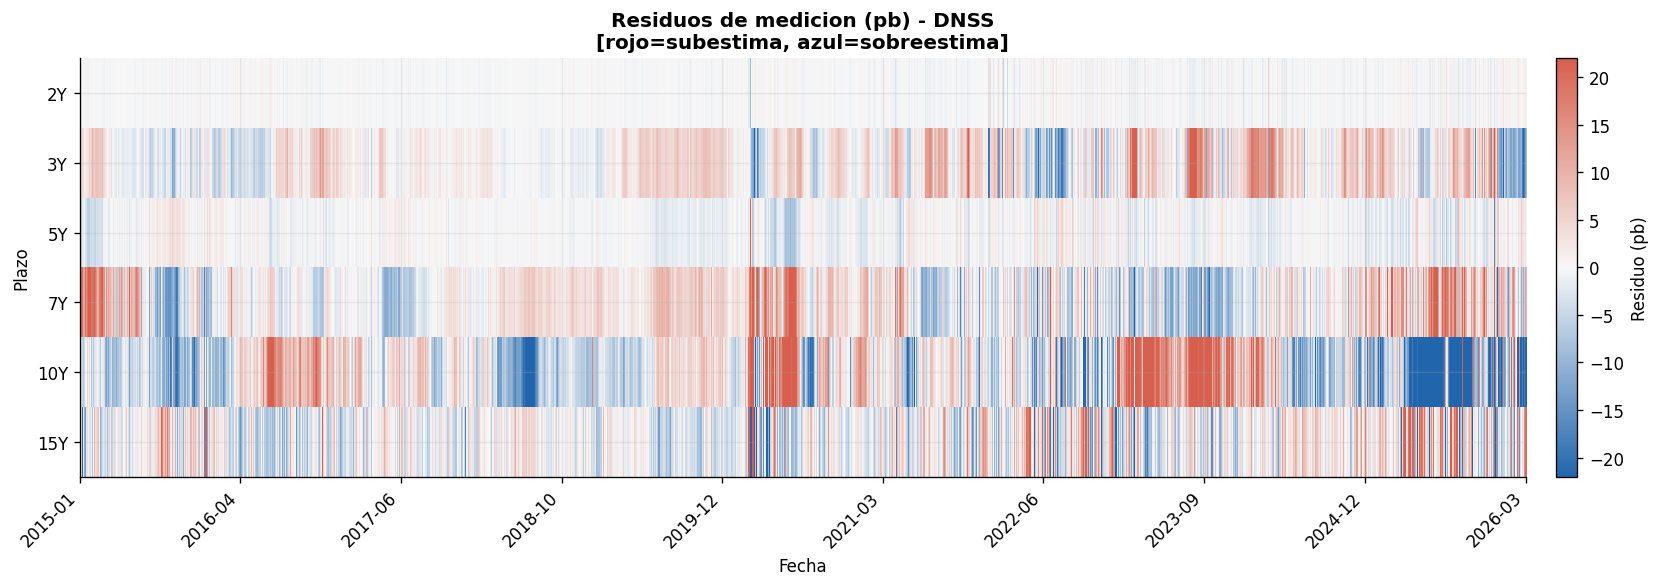

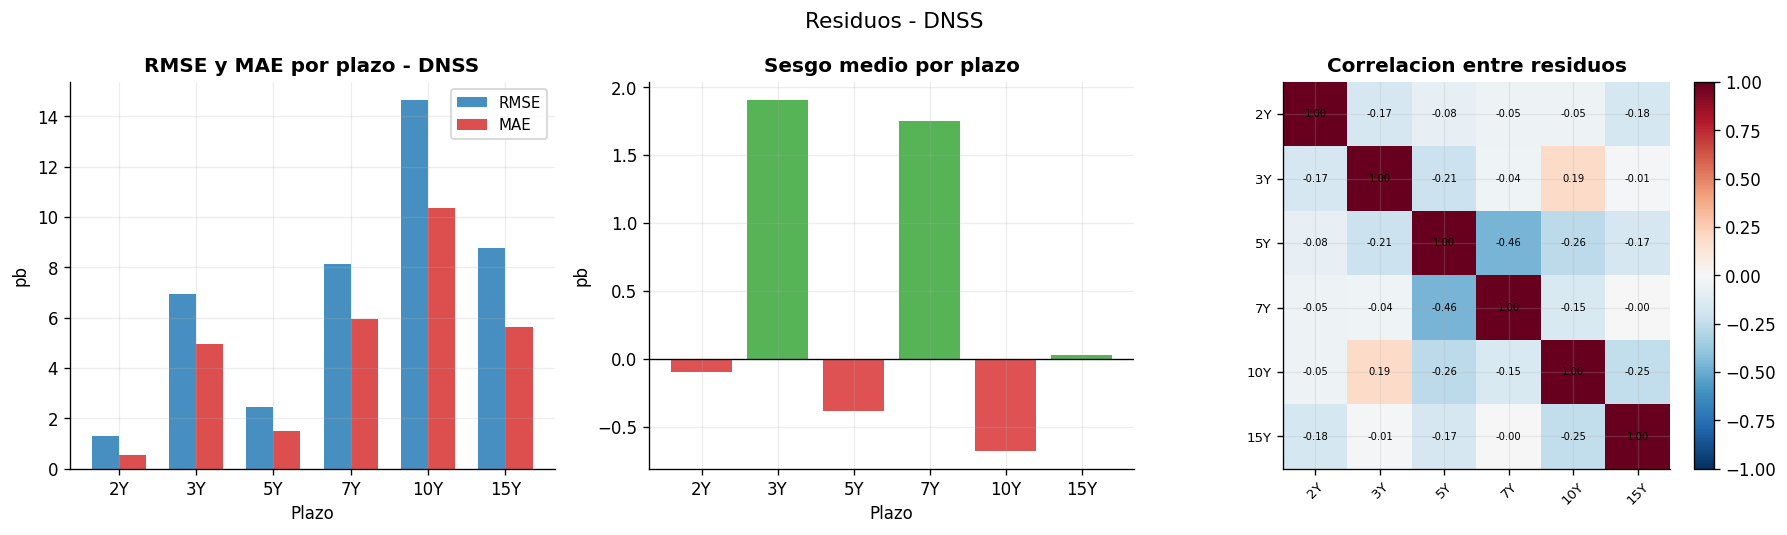

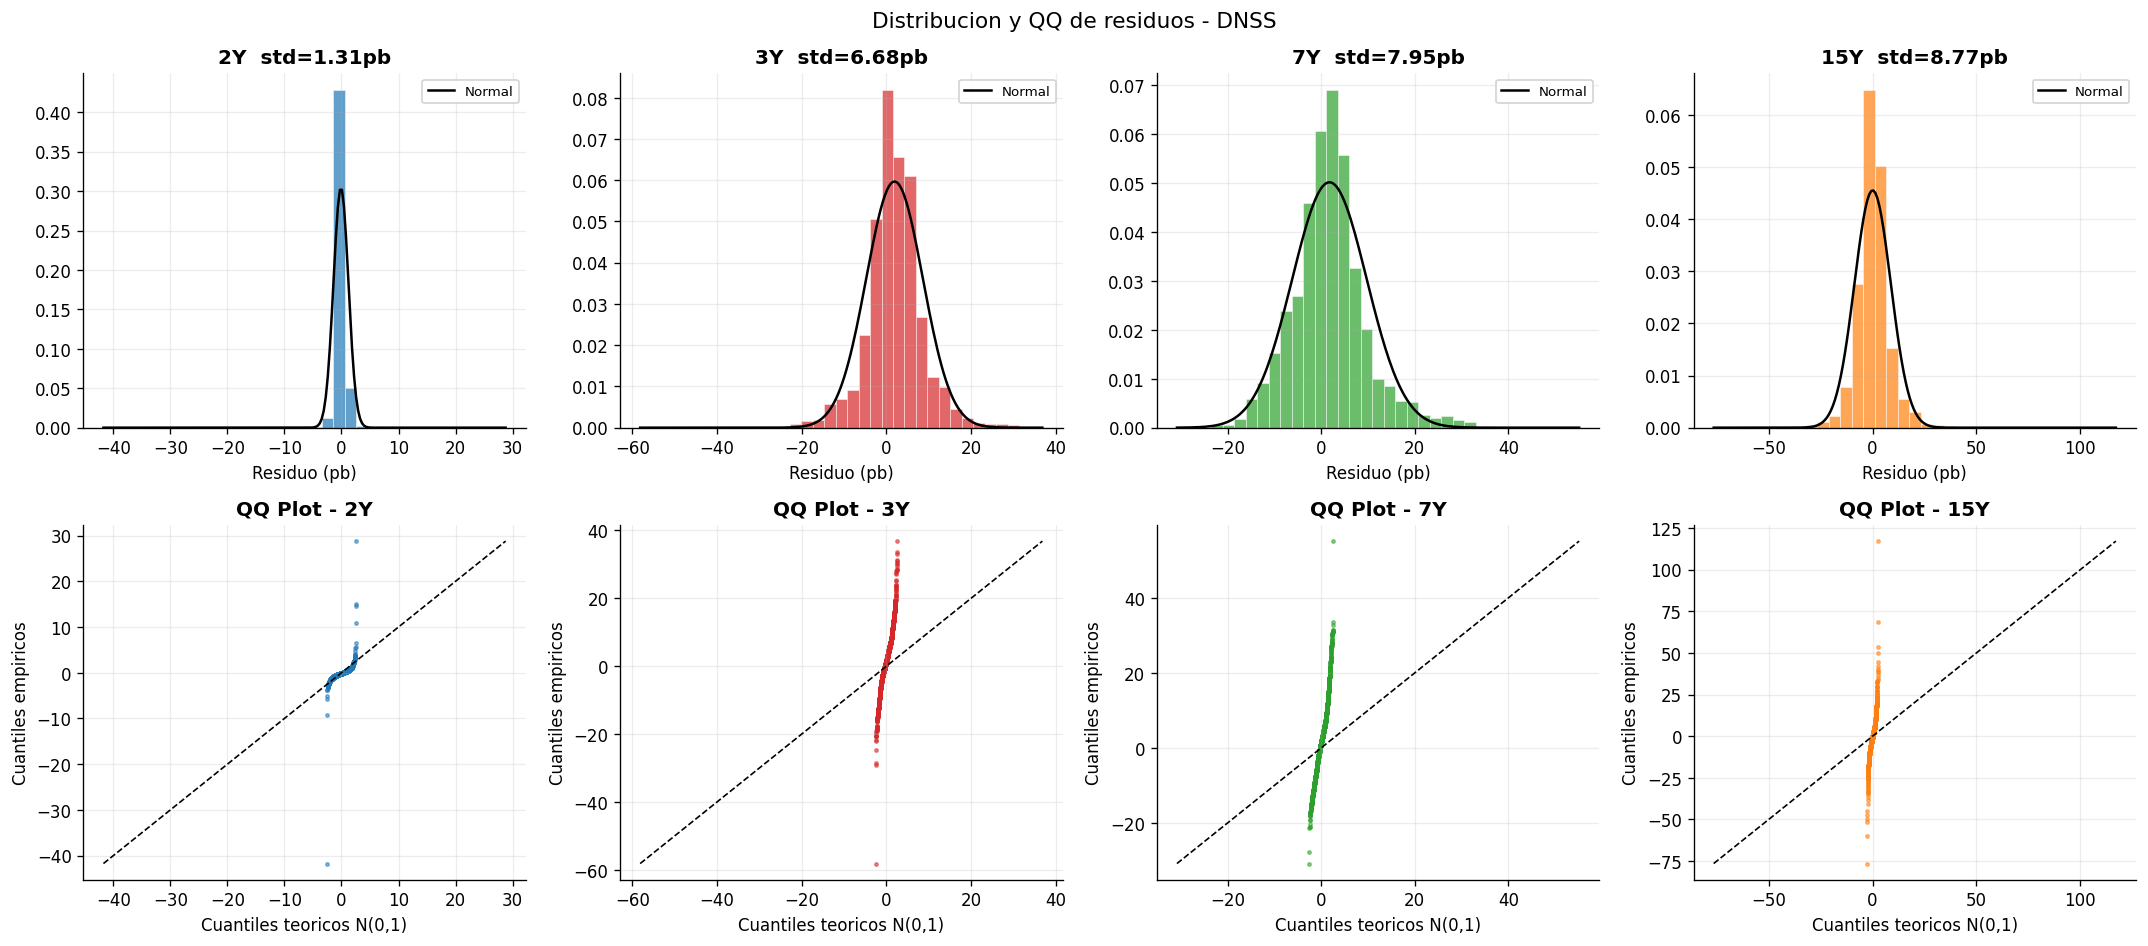


-- Tests de residuos - DNSS --
  Plazo      RMSE     Sesgo   JB p-val  Normal?
     2Y     1.314    -0.098     0.0000  No  
     3Y     6.951    +1.910     0.0000  No  
     5Y     2.433    -0.381     0.0000  No  
     7Y     8.143    +1.755     0.0000  No  
    10Y    14.639    -0.679     0.0000  No  
    15Y     8.768    +0.027     0.0000  No  

  Comparacion KF vs PF -- DNSS
  Metrica                  KF (tau grid)  PF (tau dinamico)
  ----------------------------------------------------------
  RMSE total (pb)                 9.8608             8.3011
  MAE total (pb)                  6.1949             4.8262
  Log-lik                       10,301.6           12,241.1

  Nota: el log-lik del KF es la verosimilitud EXACTA de un modelo
  lineal-gaussiano CONDICIONAL en tau_t (tratado como insumo fijo
  proveniente del grid search). El log-lik del PF es una ESTIMACION
  Monte Carlo (con varianza finita en N) de la verosimilitud marginal
  de un modelo DISTINTO, donde tau_t es estoca

In [41]:
out_dnss = fit_pf_model(
    dates_dt, yields_data, maturities,
    model='DNSS',
    n_particles=20000,
    window_size=max(252, T//8),
    n_starts_kf=1,
    sep_min=0.30,
    seed=42,
    plot=True,
    verbose=True,
    q_ltau_scale = 0.2, #MODIFICAR EL FACTOR DE ESCALA DE Q_LTAU PARA VERIFICAR EL IMPACTO EN LA VOLATILIDAD DE TAU
    ess_threshold= 0.2 #MODIFICAR EL UMBRAL DE ESS PARA VERIFICAR EL IMPACTO EN EL REMUESTREO
)

# con tau scale=0.2 y ess_threshold=0.5   RMSE PF=8.3011pb  log-lik=12,241.15
# con tau scale=0.2 y ess_threshold=0.1   RMSE PF=8.4117pb  log-lik=12,042.88
# con tau scale=0.2 y ess_threshold=0.2   RMSE PF=8.3011pb  log-lik=12,241.15


res_kf_dnss, res_pf_dnss = out_dnss['kf'], out_dnss['pf']
comparar_kf_pf(res_kf_dnss, res_pf_dnss)

In [43]:
reporte_aic_bic(res_kf_dnss, res_pf_dnss, model="DNSS")


  AIC / BIC -- DNSS   (T=2735 observaciones)
  Modelo                          k       log-lik           AIC           BIC
  --------------------------------------------------------------------
  KF (tau fijo via grid)         18      10,301.6     -20,567.2     -20,460.7
  PF (k = solo tau, nuevo)        6      12,241.1     -24,470.3     -24,434.8
  PF (k = sistema completo)      24      12,241.1     -24,434.3     -24,292.4

  Nota: el log-lik del PF tiene varianza de Monte Carlo finita en N --
  estos AIC/BIC heredan esa varianza. Para una conclusion robusta, recalcular
  con 3-5 semillas distintas y reportar el rango, no solo el punto estimado.
  La fila 'k = sistema completo' es la comparable en terminos de convencion
  de conteo contra el KF; la fila 'k = solo tau' aisla el costo de la extension.


{'kf': {'k': 18,
  'aic': -20567.163875667266,
  'bic': np.float64(-20460.713914799857)},
 'pf_nuevo': {'k': 6,
  'k_mode': 'nuevo',
  'T': 2735,
  'loglik': np.float64(12241.146299082393),
  'aic': np.float64(-24470.292598164786),
  'bic': np.float64(-24434.80927787565)},
 'pf_total': {'k': 24,
  'k_mode': 'total',
  'T': 2735,
  'loglik': np.float64(12241.146299082393),
  'aic': np.float64(-24434.292598164786),
  'bic': np.float64(-24292.35931700824)}}

[1/3] Obteniendo KF warm-start (cache si esta disponible)...
[KF cache] HIT  -- usando warm-start guardado (./cache_kf_warmstart\kf_DNSS_f10ef1014c1f46a7.pkl)
           RMSE=9.8608pb  log-lik=10,301.58
[2/3] Calibrando dinamica AR(1) de tau...
    tau1: mu=3.529  phi=0.9907  sqrt(q)=0.0265
    tau2: mu=0.868  phi=0.9829  sqrt(q)=0.0586
[3/3] Particle Filter (DNSS, N=20000 particulas)...
  [############################] 100.0%  t=2735/2735  ESS/N=0.05  remuestreos=2735  57 it/s  transcurrido=48.1s  ETA=0.0s    
    RMSE PF=8.3011pb  log-lik=12,241.15  ESS/N medio=0.068  remuestreo=100.0%  (48.20s)


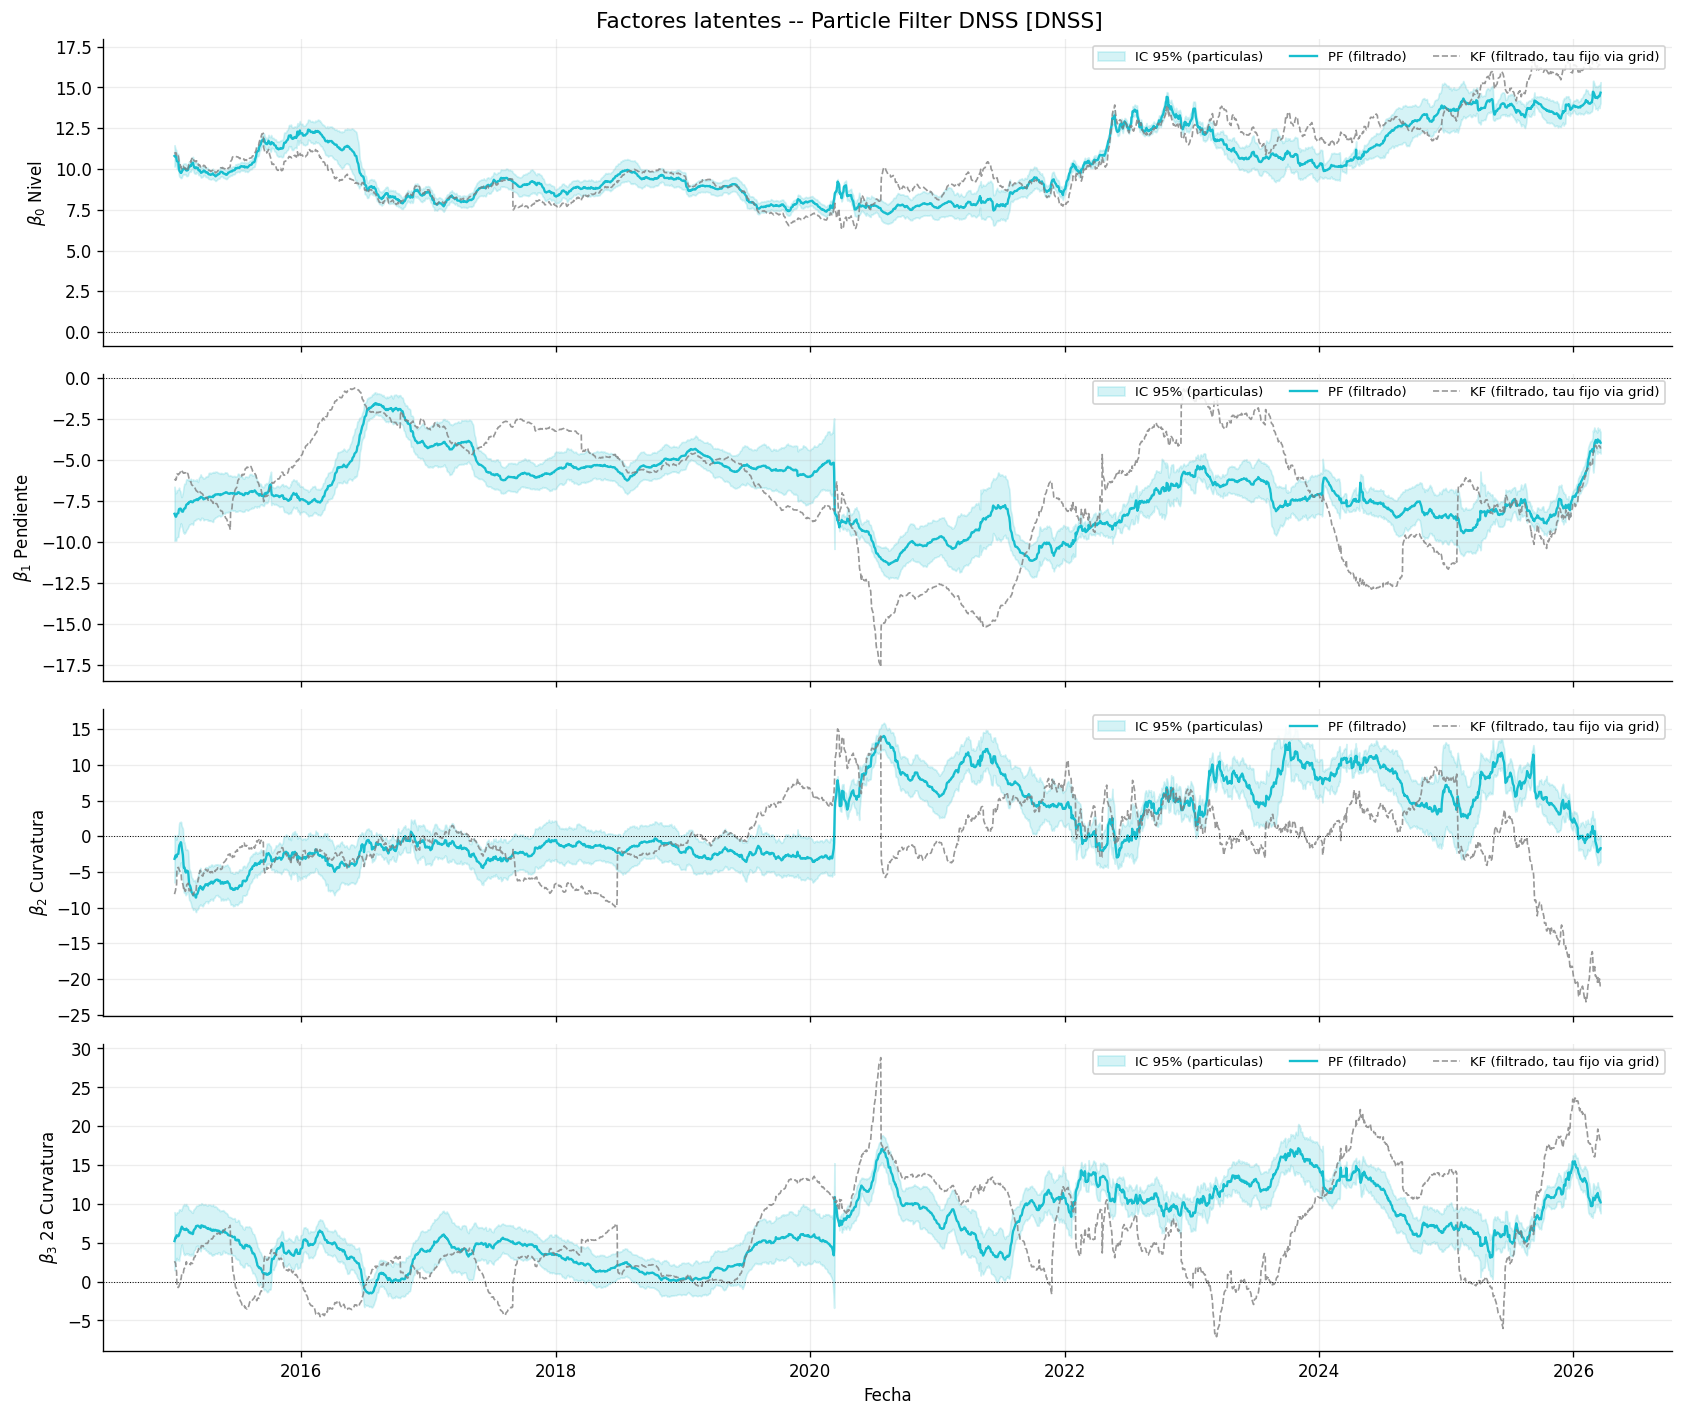

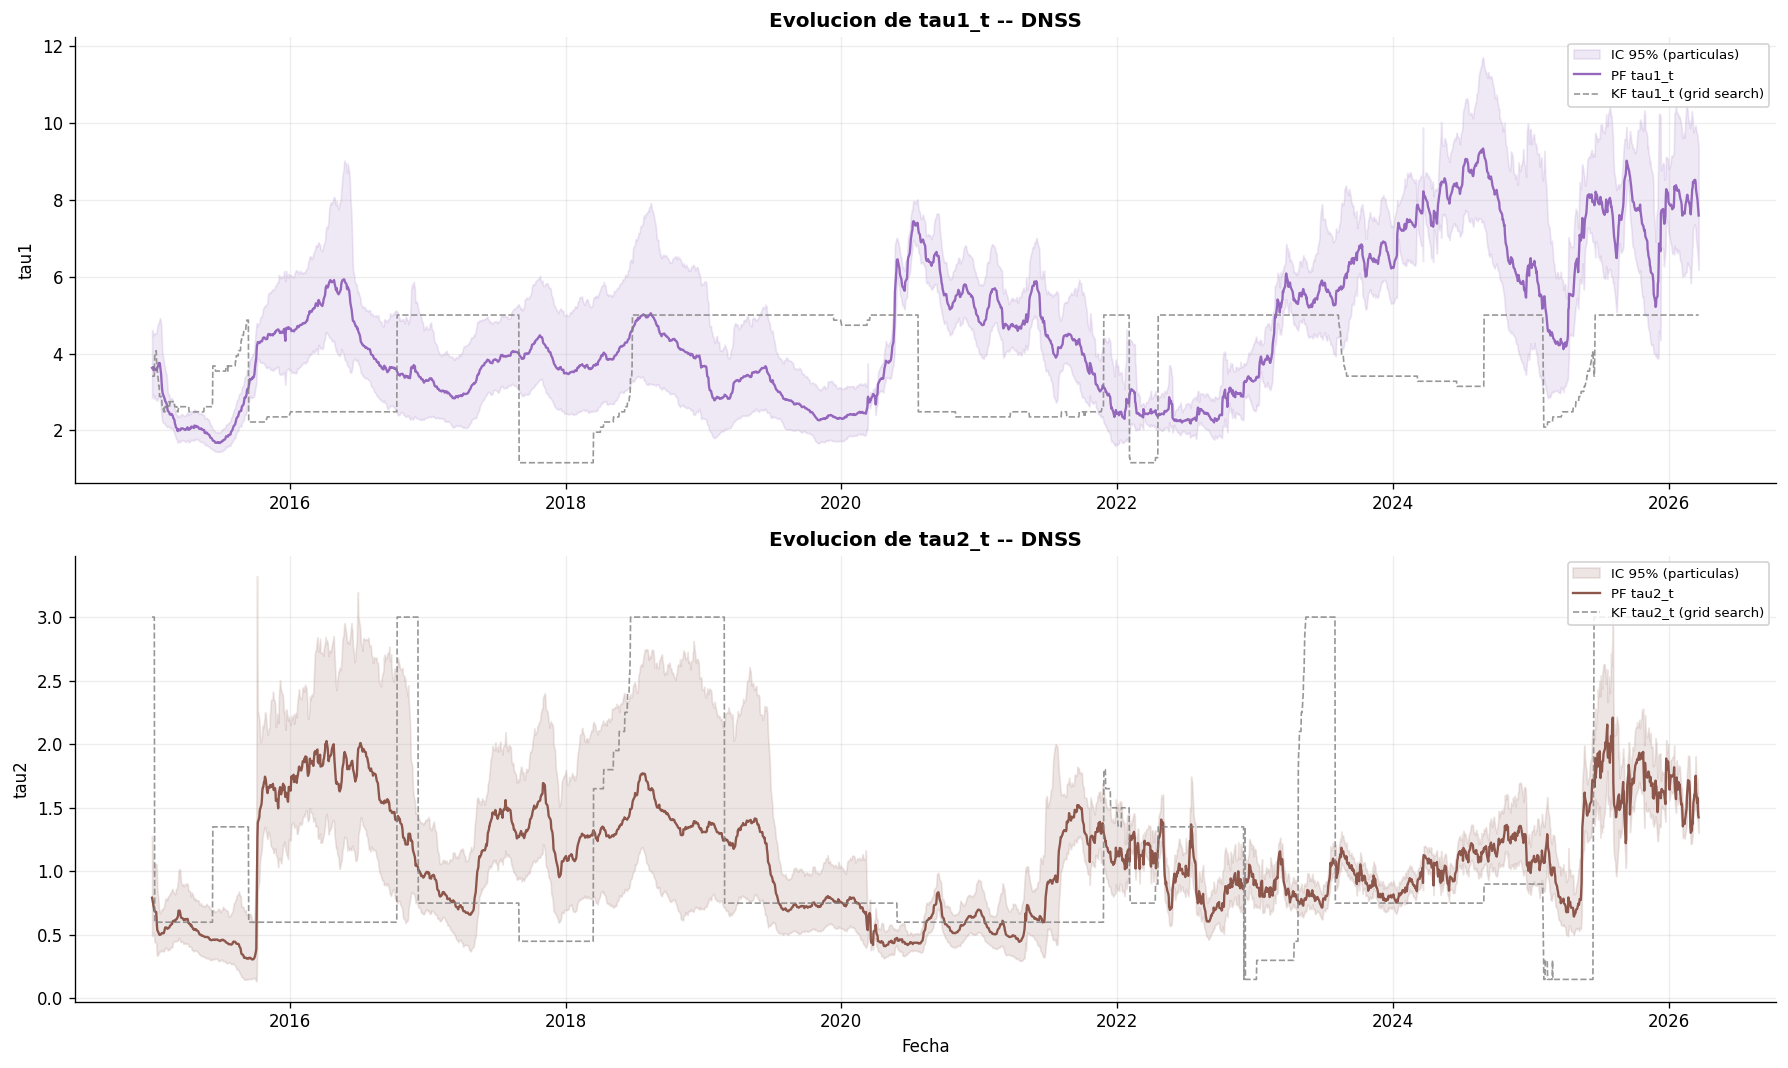

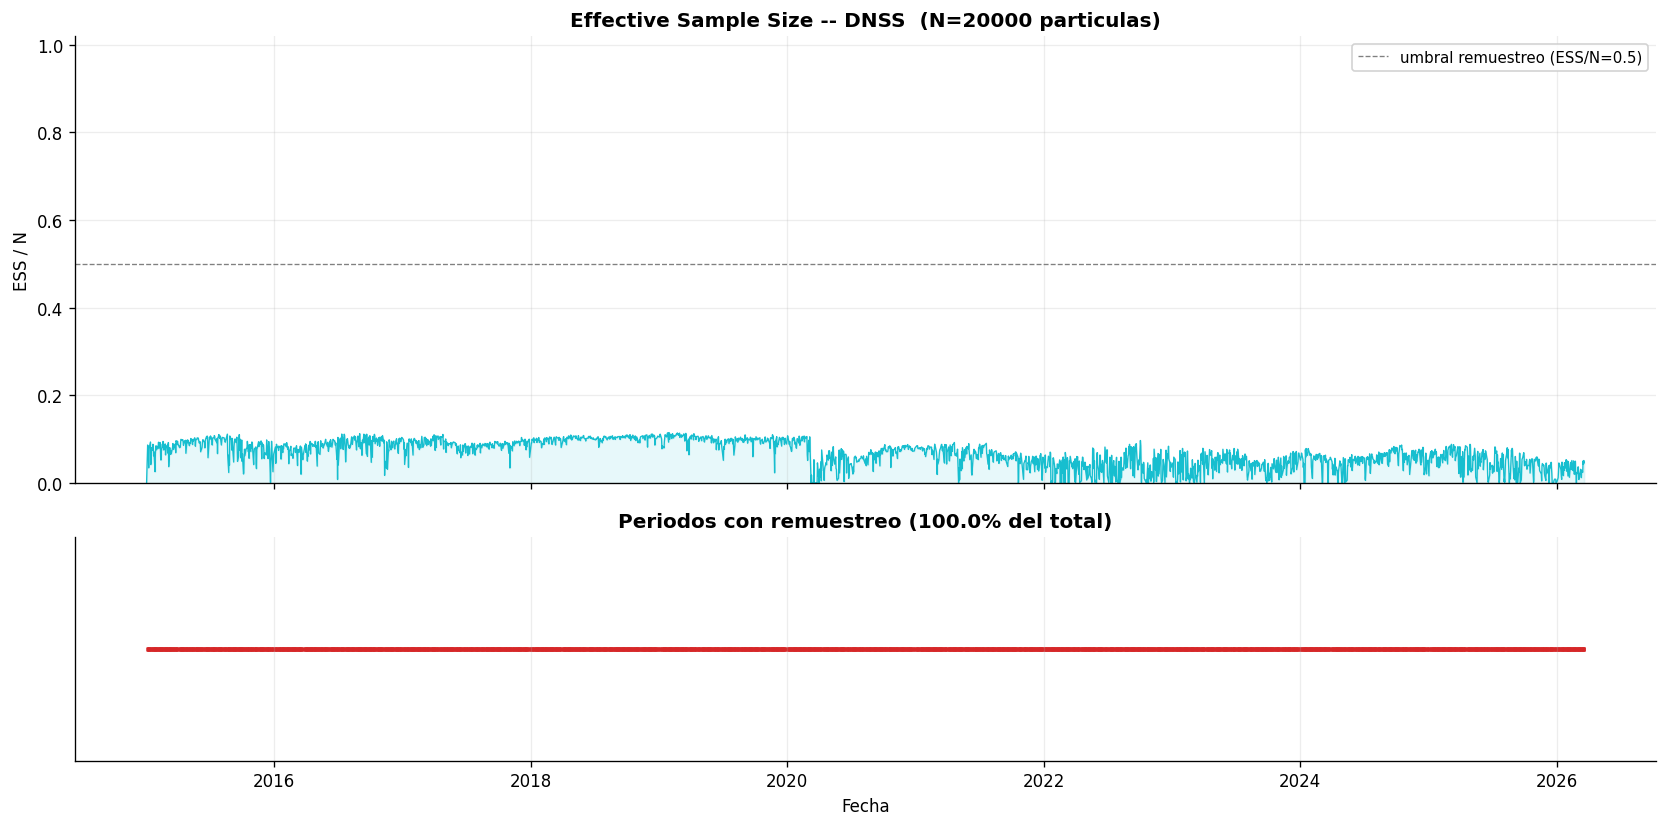


-- Diagnostico PF -- DNSS --
  ESS/N: media=0.068  min=0.000  p10=0.024
  Remuestreo: 100.0% de los periodos (2735/2735)
  Log-lik (estimado SMC): 12,241.15


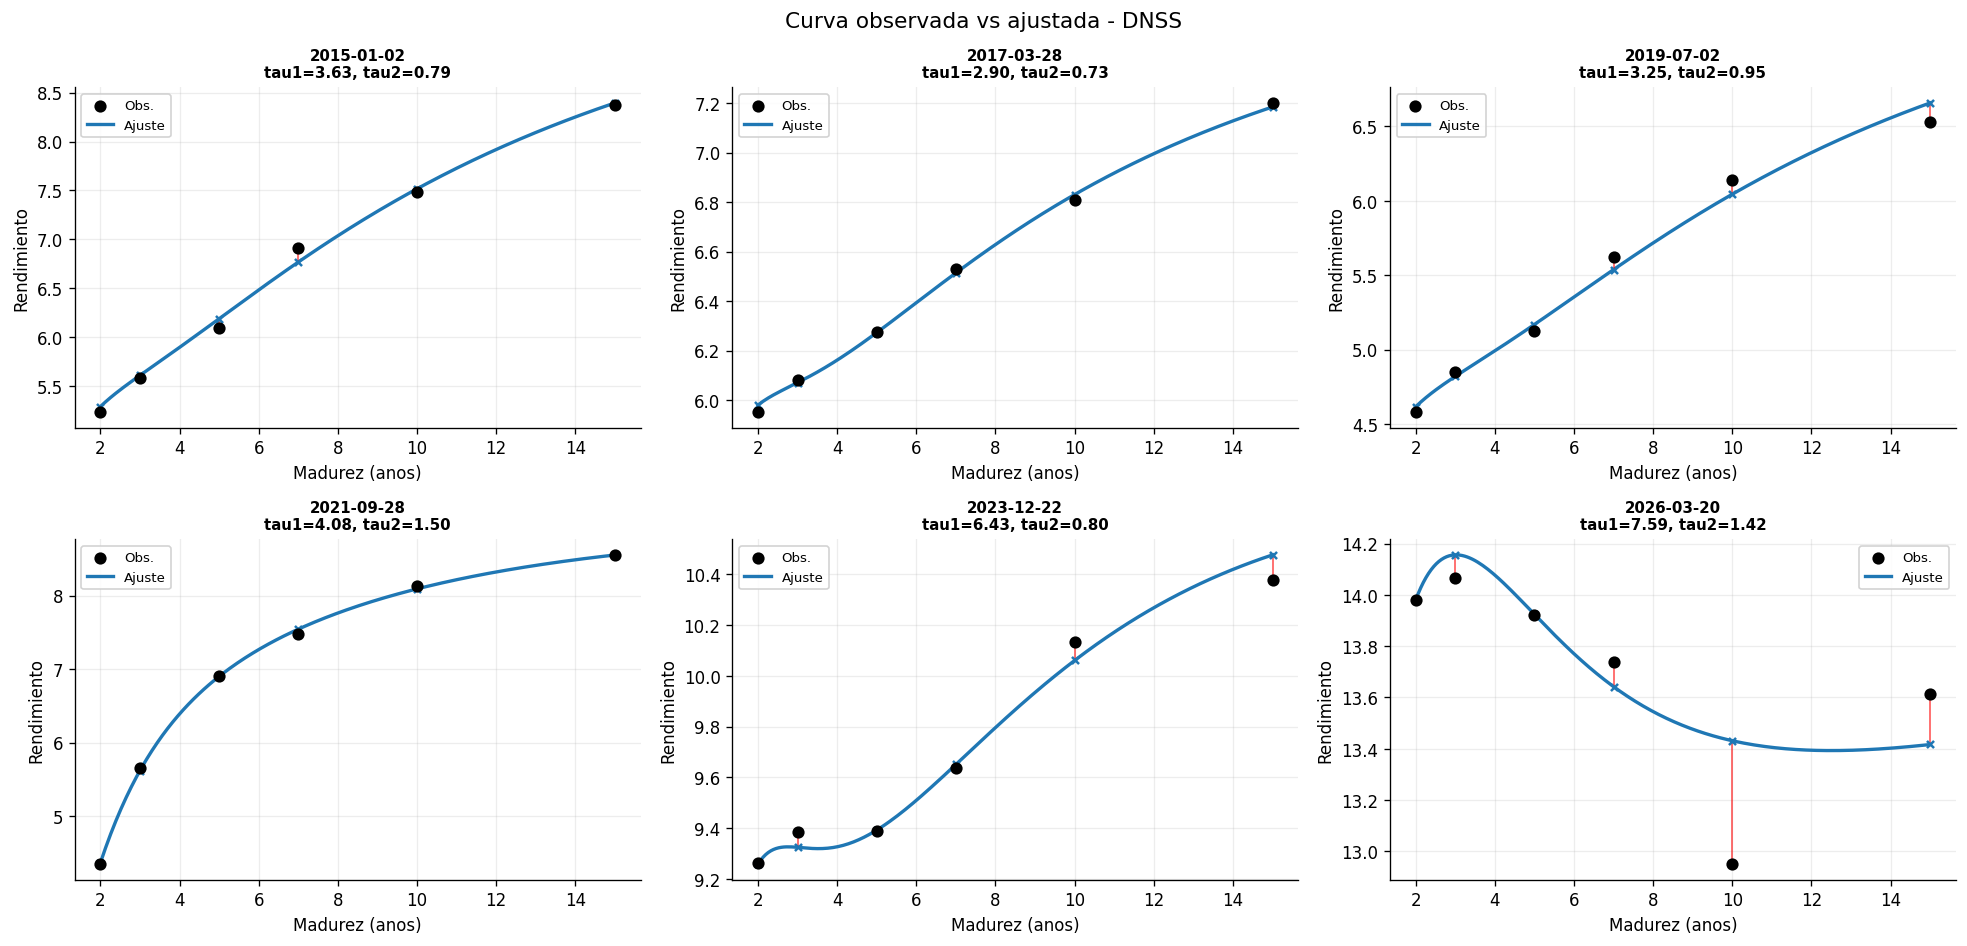

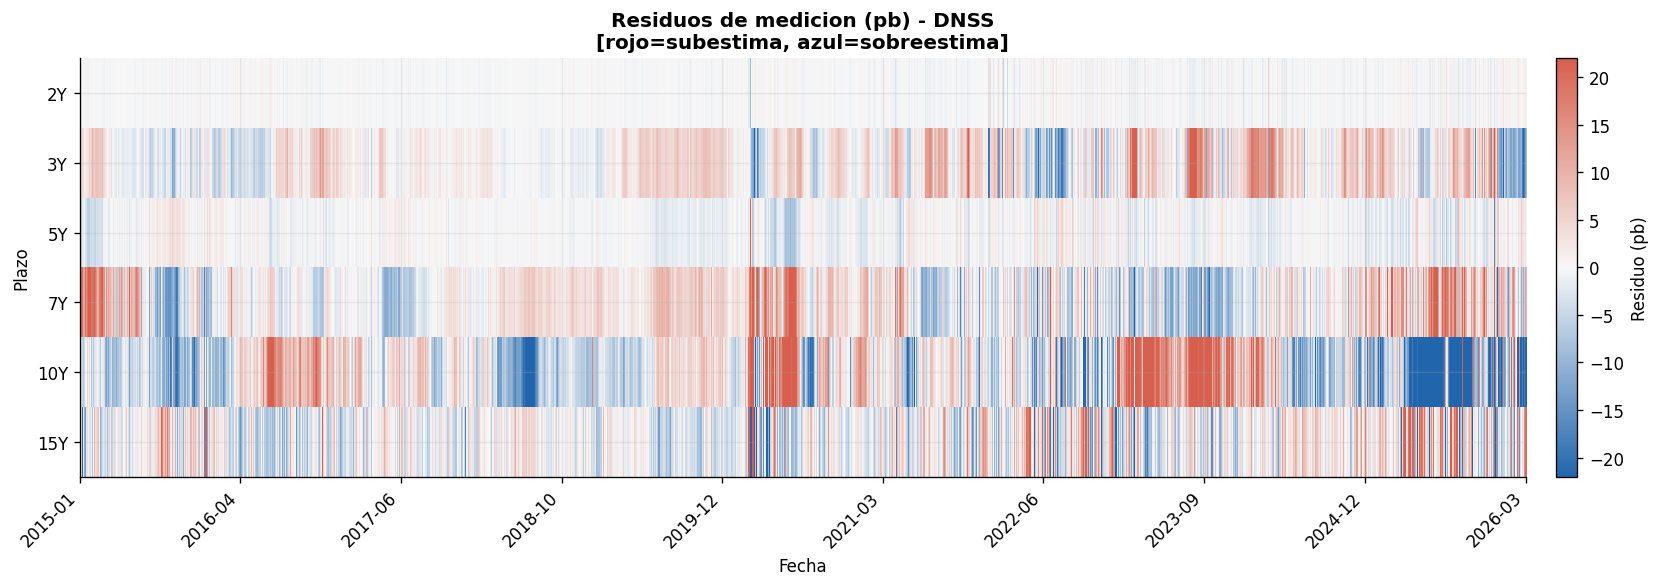

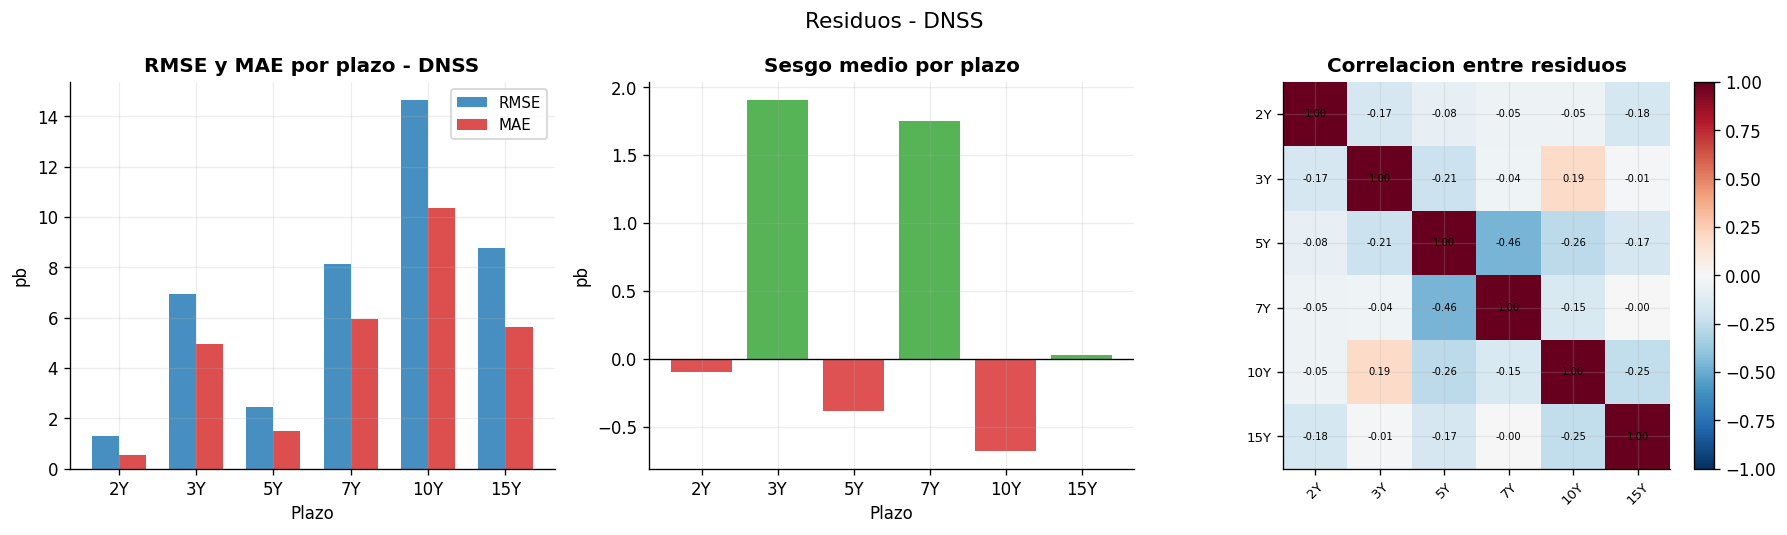

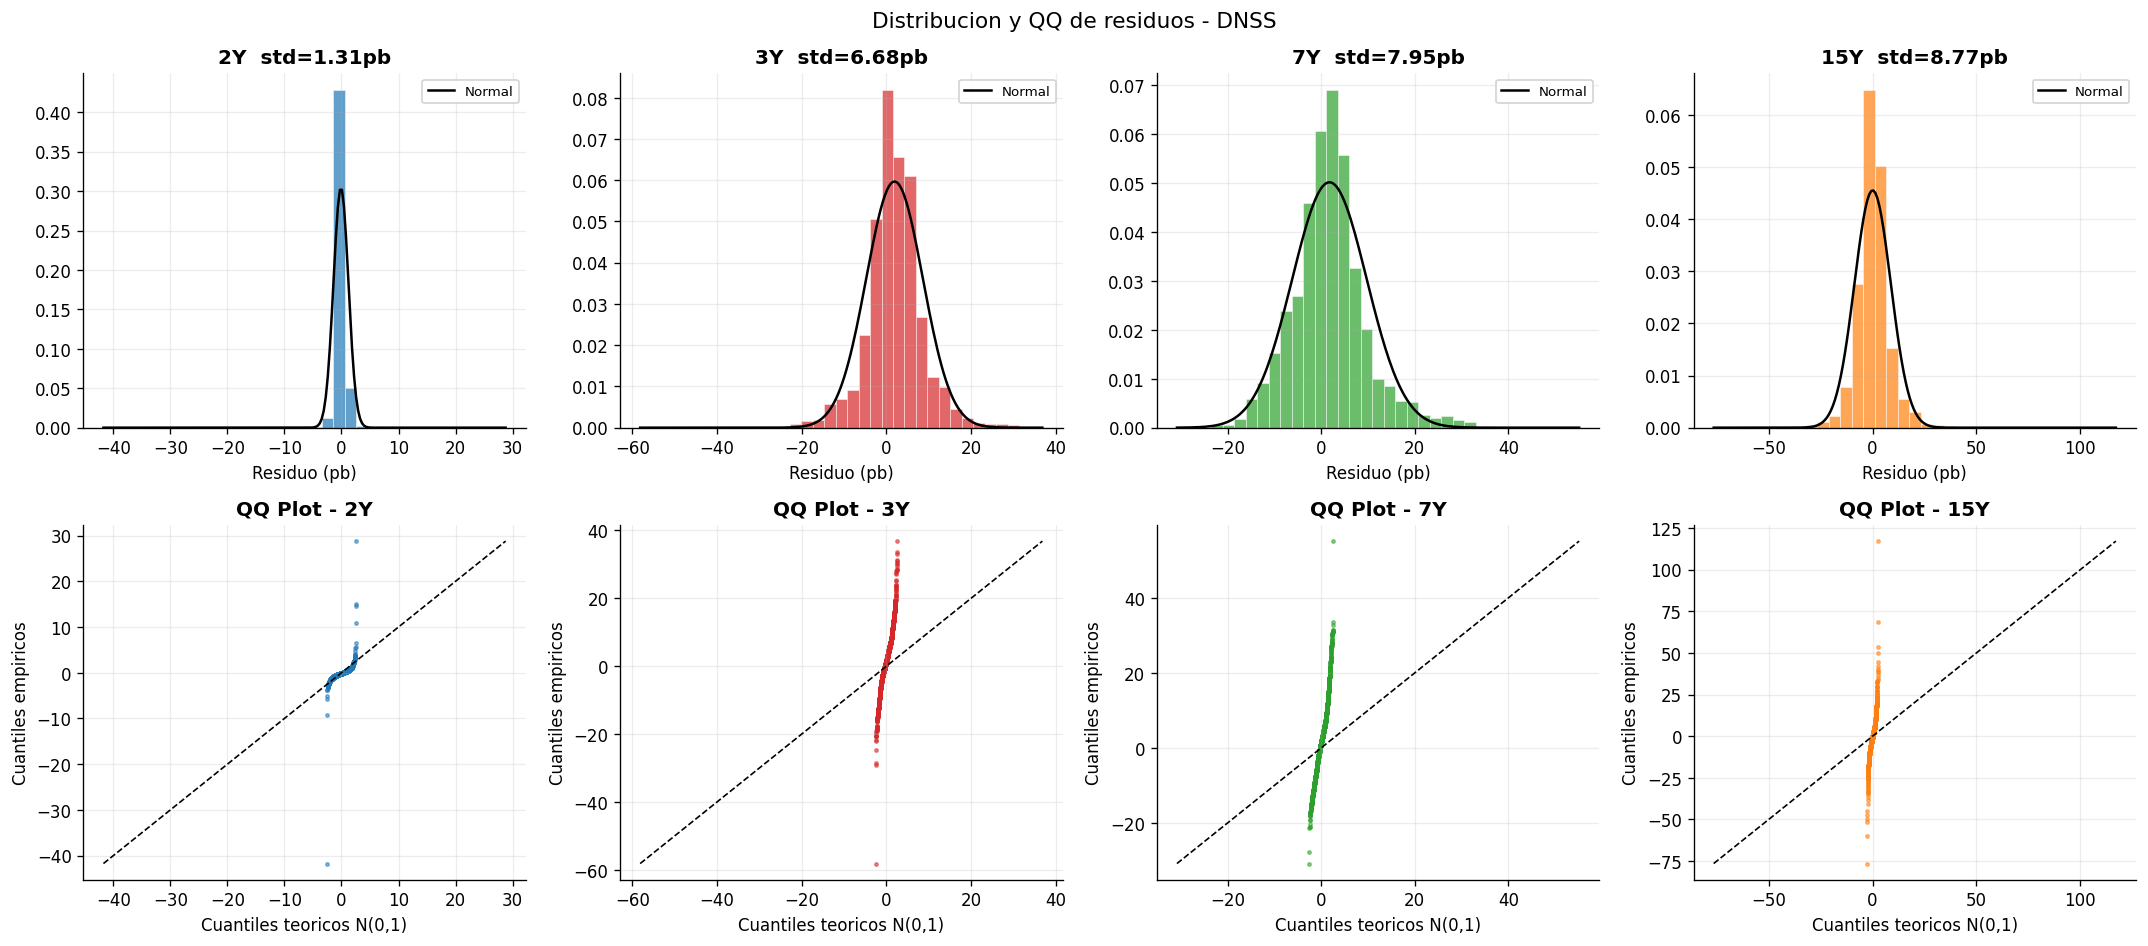


-- Tests de residuos - DNSS --
  Plazo      RMSE     Sesgo   JB p-val  Normal?
     2Y     1.314    -0.098     0.0000  No  
     3Y     6.951    +1.910     0.0000  No  
     5Y     2.433    -0.381     0.0000  No  
     7Y     8.143    +1.755     0.0000  No  
    10Y    14.639    -0.679     0.0000  No  
    15Y     8.768    +0.027     0.0000  No  

  Comparacion KF vs PF -- DNSS
  Metrica                  KF (tau grid)  PF (tau dinamico)
  ----------------------------------------------------------
  RMSE total (pb)                 9.8608             8.3011
  MAE total (pb)                  6.1949             4.8262
  Log-lik                       10,301.6           12,241.1

  Nota: el log-lik del KF es la verosimilitud EXACTA de un modelo
  lineal-gaussiano CONDICIONAL en tau_t (tratado como insumo fijo
  proveniente del grid search). El log-lik del PF es una ESTIMACION
  Monte Carlo (con varianza finita en N) de la verosimilitud marginal
  de un modelo DISTINTO, donde tau_t es estoca

In [ ]:
out_dnss = fit_pf_model(
    dates_dt, yields_data, maturities,
    model='DNSS',
    n_particles=20000,
    window_size=max(252, T//8),
    n_starts_kf=1,
    sep_min=0.30,
    seed=42,
    plot=False,
    verbose=True,
    q_ltau_scale = 0.2,
    student_t_df= 4.0,
    )
res_kf_dnss, res_pf_dnss = out_dnss['kf'], out_dnss['pf']
comparar_kf_pf(res_kf_dnss, res_pf_dnss)

## 22. Conclusiones y trabajo futuro

### Que muestra este notebook

- Tratar tau_t como parte del estado (en vez de un hiperparametro fijo via grid search) es
  factible con un Bootstrap PF estandar, sin necesitar un Extended Kalman Filter ni linealizar
  nada.
- El chequeo de consistencia (seccion 17) confirma que el PF colapsa razonablemente al caso
  lineal-gaussiano cuando se restringe tau a ser casi-fijo -- evidencia de que la
  implementacion es correcta, no solo que "corre sin errores".
- En el caso sintetico (donde se conoce la verdad), el PF recupera el path real de tau1_t
  sustancialmente mejor que el Grid Search adaptativo del KF -- consistente con que el PF usa
  el modelo generador correcto, mientras que el grid search es una aproximacion discreta y
  retrasada por la ventana movil.
- La extension a innovaciones Student-t (seccion 20) y a DNSS con restriccion dinamica (seccion
  21) confirma que el marco generaliza sin reescribir el nucleo del algoritmo.

### Limitaciones honestas

- **No hay particle smoother.** `beta_smoothed` esta seteado igual a `beta_filtered` por
  conveniencia de reutilizar las funciones de graficado del notebook del KF, pero esto NO es un
  verdadero suavizado tipo RTS. Implementar backward simulation (Godsill, Doucet & West, 2004)
  es la extension natural si se necesita el equivalente exacto de beta_(t|T).
- **Comparacion de log-lik KF vs PF es informativa, no una prueba formal.** Son modelos
  distintos (tau fijo vs tau estocastico) estimados con metodos distintos (exacto vs Monte
  Carlo). No se debe interpretar la diferencia como una prueba de razon de verosimilitudes en
  sentido estricto.
- **Aprendizaje de hiperparametros estaticos es parcial.** Los hiperparametros de la dinamica
  de beta (mu, F, Q, R) vienen de un MLE clasico condicional en una tau fija; solo los
  hiperparametros NUEVOS de la dinamica de tau se calibran (via OLS + sensibilidad). Un enfoque
  mas riguroso (Particle MCMC / SMC^2, Andrieu, Doucet & Holenstein, 2010) permitiria estimar
  TODOS los hiperparametros de forma conjunta y bayesiana, pero implica mucho mas costo
  computacional y complejidad de implementacion.
- **Varianza de Monte Carlo.** A diferencia del KF (determinista dada la semilla de NumPy del
  MLE), el PF tiene varianza finita en N. Se recomienda reportar resultados con 3-5 semillas
  distintas antes de sacar conclusiones definitivas sobre cualquier comparacion cuantitativa.

### Como se conecta con las otras dos fases del proyecto

Para la comparacion final de tres metodos (frecuentista/KF, bayesiano/Gibbs, PF), conviene que
el resultado del muestreador de Gibbs (`gibbs.py`) tambien se empaquete con el mismo esquema de
claves (`model`, `tau1_t`, `residuals`, `fitted`, ...) usado aqui -- eso permitiria reutilizar
`comparar_kf_pf()` (renombrandola a algo mas generico) para una tabla de tres vias, y las
mismas funciones de diagnostico de residuos para los tres metodos sin duplicar codigo.